In [1]:
# Final WildChat pipeline
# Goal:
# 1. Draw a random sample of 20,000 English-only first-user messages
# 2. Screen for broad advice-seeking
# 3. Screen for r/Advice compatibility
# 4. Export the final three-column comparison table

%pip install -q datasets anthropic pandas pyarrow

import os
import re
import json
import time
import random
import pandas as pd

from datasets import load_dataset

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

print("Setup complete.")

Note: you may need to restart the kernel to use updated packages.
Setup complete.


In [2]:
%pip install -q datasets pyarrow

from datasets import load_dataset

print("datasets imported successfully.")

Note: you may need to restart the kernel to use updated packages.
datasets imported successfully.


In [2]:
# Load WildChat in streaming mode so we do not download the full dataset at once
from datasets import load_dataset

wildchat_stream = load_dataset(
    "allenai/WildChat-1M",
    split="train",
    streaming=True
)

first_example = next(iter(wildchat_stream))

print("Available columns:")
print(first_example.keys())

print("\nFirst example preview:")
for key, value in first_example.items():
    print(f"\n--- {key} ---")
    print(str(value)[:800])

Available columns:
dict_keys(['conversation_hash', 'model', 'timestamp', 'conversation', 'turn', 'language', 'openai_moderation', 'detoxify_moderation', 'toxic', 'redacted', 'state', 'country', 'hashed_ip', 'header'])

First example preview:

--- conversation_hash ---
c9ec5b440fbdd2a269333dd241f32f64

--- model ---
gpt-4-0314

--- timestamp ---
2023-04-09 00:02:53+00:00

--- conversation ---
[{'content': 'Hey there! Are you familiar with reality shifting? So, I’m refining a foolproof method for reality shifting and want to pick a destination. Want to help me? I’m thinking something pretty personalized. There are a few things that are required of my destination. 1. The quest. I have to have a clear overarching goal in my reality, and don’t make it too crazy. It should be more along the lines of “save the president’s daughter” or “escape this weird wacky sinister place” NOT “get an artifact that literally controls reality”. Seriously, don’t make me fetch an artifact, or fetch anything. I

In [3]:
conversation = first_example["conversation"]

print("Conversation type:", type(conversation))
print("\nFirst conversation:")
print(conversation)

print("\nFirst turn:")
print(conversation[0])

Conversation type: <class 'list'>

First conversation:
[{'content': 'Hey there! Are you familiar with reality shifting? So, I’m refining a foolproof method for reality shifting and want to pick a destination. Want to help me? I’m thinking something pretty personalized. There are a few things that are required of my destination. 1. The quest. I have to have a clear overarching goal in my reality, and don’t make it too crazy. It should be more along the lines of “save the president’s daughter” or “escape this weird wacky sinister place” NOT “get an artifact that literally controls reality”. Seriously, don’t make me fetch an artifact, or fetch anything. Instead, make me DO something. 2. Babes. I need pretty girls. 3. The entry. I need to get to lose consciousness in order to begin my journey in my desired reality, preferably by having it knocked out by one of the aforementioned babes. 4. Action. It needs to be cool. 5. Unconsciousness. Myself and the babes need to pass out in this place, 

In [4]:
## 20k eng-only

from datasets import load_dataset
import pandas as pd

TARGET_N = 20000
SEED = 42

# Reload and shuffle the stream before sampling
wildchat_stream = load_dataset(
    "allenai/WildChat-1M",
    split="train",
    streaming=True
).shuffle(seed=SEED, buffer_size=100_000)

english_records = []
seen_texts = set()
scanned = 0

for example in wildchat_stream:
    scanned += 1

    conversation = example.get("conversation", [])

    if not conversation:
        continue

    first_turn = conversation[0]

    if first_turn.get("role") != "user":
        continue

    if str(first_turn.get("language", "")).strip().lower() != "english":
        continue

    text = str(first_turn.get("content", "")).strip()

    if not text or text.lower() == "nan":
        continue

    # Keep unique first-user messages
    if text in seen_texts:
        continue

    seen_texts.add(text)

    english_records.append({
        "conversation_hash": example.get("conversation_hash"),
        "first_user_message": text,
        "language": first_turn.get("language"),
        "country": first_turn.get("country"),
        "state": first_turn.get("state")
    })

    if len(english_records) % 1000 == 0:
        print(f"Collected {len(english_records)}/{TARGET_N} English messages "
              f"(scanned {scanned} total records)")

    if len(english_records) >= TARGET_N:
        break

wildchat_20k_english = pd.DataFrame(english_records)

output_file = "wildchat_20k_english_only_first_user_messages.csv"
wildchat_20k_english.to_csv(output_file, index=False)

print("\nFinished.")
print("English-only sample size:", len(wildchat_20k_english))
print("Saved:", output_file)

display(wildchat_20k_english.head(10))

Collected 1000/20000 English messages (scanned 1699 total records)
Collected 2000/20000 English messages (scanned 3478 total records)
Collected 3000/20000 English messages (scanned 5249 total records)
Collected 4000/20000 English messages (scanned 7072 total records)
Collected 5000/20000 English messages (scanned 8916 total records)
Collected 6000/20000 English messages (scanned 10775 total records)
Collected 7000/20000 English messages (scanned 12537 total records)
Collected 8000/20000 English messages (scanned 14382 total records)
Collected 9000/20000 English messages (scanned 16248 total records)
Collected 10000/20000 English messages (scanned 18135 total records)
Collected 11000/20000 English messages (scanned 20045 total records)
Collected 12000/20000 English messages (scanned 21969 total records)
Collected 13000/20000 English messages (scanned 23864 total records)
Collected 14000/20000 English messages (scanned 25801 total records)
Collected 15000/20000 English messages (scanned 

,conversation_hash,first_user_message,language,country,state
0,9aaf9061a67f7c522ef89a9b21197e43,I am using Sony a7r iv camera. I want to take ...,English,Thailand,Bangkok
1,1b4d6e5000b6ee2d258985d0feb02474,As a prompt generator for a generative AI call...,English,Malaysia,Kuala Lumpur
2,16b1f3a00d9b75cb356a9ad359636c4f,Hello. I need your help.,English,The Netherlands,None
3,d8e0303558f442adc85df93be71ea1f4,I want you to create details for a fictional v...,English,Russia,Moscow
4,9639e8f7835101c6513f53720ca52139,create a script for reel about closing sales.,English,Türkiye,Istanbul
5,4bccebefc4648bd8dd5fb7e4d45f9385,Write a 4000 word article on Amazon jobs,English,Egypt,Cairo Governorate
6,04b68df51cdd8e2d3a1a78e23b36cbc7,You have two arrays. One shows the names of th...,English,Uzbekistan,Tashkent
7,50ea99100565dd1b7479ca98256d78b6,"翻译中文▪Ran 2 3/8"" 4,6# 9Cr-1Mo N. VAM special cl...",English,United States,California
8,628166c360d8de8b1807483be7e49391,As a prompt generator for a generative AI call...,English,China,Sichuan
9,2caa1a398ee5f2ec679b2d58c68c9499,As a prompt generator for a generative AI call...,English,Hong Kong,None


In [5]:
# Check the final 20k English-only sample

wildchat_20k_english = pd.read_csv(
    "wildchat_20k_english_only_first_user_messages.csv"
)

wildchat_20k_english["text"] = (
    wildchat_20k_english["first_user_message"]
    .astype(str)
    .str.strip()
)

print("Total rows:", len(wildchat_20k_english))
print("Language counts:")
print(wildchat_20k_english["language"].value_counts())

print("\nDuplicate texts:", wildchat_20k_english["text"].duplicated().sum())
print("Blank texts:", (wildchat_20k_english["text"] == "").sum())

display(
    wildchat_20k_english[
        ["conversation_hash", "language", "text"]
    ].sample(n=10, random_state=42)
)

Total rows: 20000
Language counts:
language
English    20000
Name: count, dtype: int64

Duplicate texts: 0
Blank texts: 0


,conversation_hash,language,text
10650,e38523482e3f98450251eba0f09cbfe2,English,please Write an introductory email to a law fi...
2041,3d2e0f8d6c847b025896f4bacd44b1b2,English,Police social media post wishing everyone a ha...
8668,532ce45db7d9c864ddb72b5f203e7c13,English,write me a formal invitation letter to my frie...
1114,3d63002bd95b122f3d039d04eccb33fe,English,improve professionly：Previous studies have pro...
13902,b045e26c67290ff3f08cc3a4f09c242c,English,привет помоги с рефакторингом \n public class ...
11963,d02e3404cc001a45ab25939fb1d98aba,English,How can I stop myself from relying on tools li...
11072,4778e2c3e3e343a09eecf4571a6c854f,English,Freedom Planet and Naruto: Freedom Planet Girl...
3002,2fdbfeae6852f60e362e8ec2da105bf7,English,As a prompt generator for a generative AI call...
19771,53ada65a2b857abfda0a0cbd5e9eb3a7,English,As a prompt generator for a generative AI call...
8115,02154f345a444b28c0af4e39593dd094,English,(In the clubroom…)\n\nMonika: “Wait a minute…w...


In [9]:
# --- Old 2k rubric, adapted for the new 20k English-only notebook ---

import time
import pandas as pd

wildchat_20k_old_rubric_tool = {
    "name": "classify_four_column_candidate_v3",
    "description": "Classify English-only WildChat and Reddit advice/decision candidates for four-column extraction.",
    "input_schema": {
        "type": "object",
        "properties": {
            "personal_practical_advice": {
                "type": "string",
                "enum": ["yes", "no", "borderline"]
            },
            "binary_personal_decision": {
                "type": "string",
                "enum": ["yes", "no", "borderline"]
            },
            "option_1": {"type": "string"},
            "option_2": {"type": "string"},
            "radvice_rule_compliant": {
                "type": "string",
                "enum": ["yes", "no", "not_applicable", "borderline"]
            },
            "radvice_rule_violation_type": {
                "type": "string",
                "enum": [
                    "none",
                    "not_asking_for_advice",
                    "rant_or_venting",
                    "legal_advice",
                    "medical_or_therapy_advice",
                    "tech_support",
                    "homework_or_schoolwork",
                    "validation_or_reassurance",
                    "hypothetical_or_general_question",
                    "suicide_or_self_harm",
                    "privacy_or_personal_information",
                    "harassment_or_hate",
                    "other"
                ]
            },
            "domain": {
                "type": "string",
                "enum": [
                    "career_work",
                    "relationship_social",
                    "family",
                    "health_wellbeing",
                    "daily_life_practical",
                    "education_application",
                    "finance_business",
                    "legal_bureaucratic",
                    "technical_digital",
                    "creative",
                    "other"
                ]
            },
            "brief_reason": {"type": "string"}
        },
        "required": [
            "personal_practical_advice",
            "binary_personal_decision",
            "option_1",
            "option_2",
            "radvice_rule_compliant",
            "radvice_rule_violation_type",
            "domain",
            "brief_reason"
        ]
    }
}


def classify_wildchat_20k_old_rubric(text, max_retries=3):
    """
    Uses the same broad-advice rubric as the earlier 2k pilot.
    The binary fields are retained for consistency but will not be analysed.
    """
    text = str(text)[:6000]

    prompt = f"""
You are classifying an English-language user message for a research project comparing advice-seeking in WildChat and Reddit r/Advice.

Source: wildchat

We need four classifications.

A. personal_practical_advice

Choose "yes" if the user asks for advice or guidance about a personal, practical, everyday, social, educational, career, health, finance, family, legal/bureaucratic, or life problem.

This includes:
- recommendation
- planning
- coping
- communication strategy
- choosing what to do
- evaluating options
- practical guidance

Choose "no" if the message is mainly:
- technical troubleshooting, software/hardware configuration, coding/debugging
- creative writing, worldbuilding, story/game design
- pure factual lookup
- translation, summarisation, rewriting
- abstract analysis not about the user's own life or practical decision
- roleplay or jailbreak prompt

B. binary_personal_decision

Choose "yes" only if the user is trying to decide between two and only two concrete options in a personal/practical life context.

Examples:
- Should I stay in my job or quit?
- Should I choose university A or university B?
- Should I tell my friend or keep quiet?
- Should I move home or stay where I am?

Choose "no" if:
- it is general advice without exactly two options
- it is technical troubleshooting
- it is creative writing
- it is pure factual information
- it has more than two options
- no concrete choice is present

Choose "borderline" if it is a personal/practical decision but the two options are implied rather than explicitly stated.

If binary_personal_decision is yes or borderline:
- option_1 = short sentence describing first option
- option_2 = short sentence describing second option

If not binary:
- option_1 = "N/A"
- option_2 = "N/A"

C. radvice_rule_compliant

This only applies if source is reddit. If source is wildchat, return "not_applicable".

D. domain

Choose the best topic domain.

Text:
{text}
"""

    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model=MODEL_NAME,
                max_tokens=800,
                temperature=0,
                tools=[wildchat_20k_old_rubric_tool],
                tool_choice={
                    "type": "tool",
                    "name": "classify_four_column_candidate_v3"
                },
                messages=[{"role": "user", "content": prompt}]
            )

            for block in response.content:
                if block.type == "tool_use":
                    return block.input

        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(2)

    return {
        "personal_practical_advice": "borderline",
        "binary_personal_decision": "borderline",
        "option_1": "N/A",
        "option_2": "N/A",
        "radvice_rule_compliant": "not_applicable",
        "radvice_rule_violation_type": "other",
        "domain": "other",
        "brief_reason": "Failed after retries."
    }


print("20k classifier using the old 2k rubric is ready.")

20k classifier using the old 2k rubric is ready.


In [11]:
%pip install -q anthropic

import os
import anthropic
from getpass import getpass

if "ANTHROPIC_API_KEY" not in os.environ:
    os.environ["ANTHROPIC_API_KEY"] = getpass("Paste your Anthropic API key here: ")

client = anthropic.Anthropic()
MODEL_NAME = "claude-haiku-4-5-20251001"

print("Claude client ready.")

Note: you may need to restart the kernel to use updated packages.


Paste your Anthropic API key here:  ········


Claude client ready.


In [12]:
test_records = []

test_sample = wildchat_20k_english.sample(n=20, random_state=42)

for _, row in test_sample.iterrows():
    result = classify_wildchat_20k_old_rubric(row["text"])

    record = {
        "conversation_hash": row["conversation_hash"],
        "text": row["text"]
    }
    record.update(result)
    test_records.append(record)

wildchat_20k_test = pd.DataFrame(test_records)

display(
    wildchat_20k_test[
        [
            "text",
            "personal_practical_advice",
            "binary_personal_decision",
            "domain",
            "brief_reason"
        ]
    ]
)

print(wildchat_20k_test["personal_practical_advice"].value_counts())

,text,personal_practical_advice,binary_personal_decision,domain,brief_reason
0,please Write an introductory email to a law fi...,yes,no,legal_bureaucratic,User is asking for help drafting a professiona...
1,Police social media post wishing everyone a ha...,no,no,other,This is a police social media post wishing peo...
2,write me a formal invitation letter to my frie...,no,no,creative,User is asking for help writing/composing a fo...
3,improve professionly：Previous studies have pro...,no,no,other,This is a scientific research summary about IL...
4,привет помоги с рефакторингом \n public class ...,no,no,technical_digital,User is asking for code refactoring help on a ...
5,How can I stop myself from relying on tools li...,yes,no,career_work,User is asking for practical guidance on how t...
6,Freedom Planet and Naruto: Freedom Planet Girl...,no,no,creative,This is a creative writing/fanfiction prompt d...
7,As a prompt generator for a generative AI call...,no,no,creative,This is a creative writing/prompt engineering ...
8,As a prompt generator for a generative AI call...,no,no,creative,This is a creative writing/prompt engineering ...
9,(In the clubroom…)\n\nMonika: “Wait a minute…w...,no,no,creative,This is a creative writing piece depicting a f...


personal_practical_advice
no     17
yes     3
Name: count, dtype: int64


In [13]:
import re

def contains_obvious_non_english_script(text):
    text = str(text)

    # Chinese, Japanese, Korean, Cyrillic, Arabic, Thai, Hebrew
    return bool(re.search(
        r"[\u4e00-\u9fff\u3040-\u30ff\uac00-\ud7af"
        r"\u0400-\u04ff\u0600-\u06ff\u0e00-\u0e7f\u0590-\u05ff]",
        text
    ))

non_english_script_count = wildchat_20k_english["text"].apply(
    contains_obvious_non_english_script
).sum()

print("Rows containing obvious non-English scripts:", non_english_script_count)
print(
    "Rows without those scripts:",
    len(wildchat_20k_english) - non_english_script_count
)

Rows containing obvious non-English scripts: 3547
Rows without those scripts: 16453


In [14]:
mixed_script_rows = wildchat_20k_english[
    wildchat_20k_english["text"].apply(contains_obvious_non_english_script)
].copy()

display(
    mixed_script_rows[
        ["text", "language"]
    ].sample(
        n=20,
        random_state=123
    )
)

,text,language
7828,As a prompt generator for a generative AI call...,English
4927,As a prompt generator for a generative AI call...,English
10597,As a prompt generator for a generative AI call...,English
16121,As a prompt generator for a generative AI call...,English
3292,As a prompt generator for a generative AI call...,English
4677,As a prompt generator for a generative AI call...,English
11064,pycharm报错missing optional dependency 'ffsspec....,English
13254,в чем проблема?\nошибка: Uncaught (in promise)...,English
4417,как установить tensorboard и tesorflow с нуля,English
15563,As a prompt generator for a generative AI call...,English


In [15]:
# Run the old 2k rubric on the final 20k English-labelled WildChat sample

PROGRESS_FILE = "wildchat_20k_old_rubric_progress.csv"
FINAL_FILE = "wildchat_20k_old_rubric_classified.csv"

# Resume automatically if the notebook stops midway
if os.path.exists(PROGRESS_FILE):
    progress_df = pd.read_csv(PROGRESS_FILE)

    completed_hashes = set(
        progress_df["conversation_hash"]
        .astype(str)
        .tolist()
    )

    classified_records = progress_df.to_dict("records")

    print("Resuming previous run.")
    print("Already completed:", len(classified_records))

else:
    completed_hashes = set()
    classified_records = []

    print("Starting new 20k classification run.")

for _, row in wildchat_20k_english.iterrows():
    conversation_hash = str(row["conversation_hash"])

    if conversation_hash in completed_hashes:
        continue

    result = classify_wildchat_20k_old_rubric(
        text=row["text"]
    )

    record = row.to_dict()
    record.update(result)

    classified_records.append(record)

    if len(classified_records) % 50 == 0:
        temp_df = pd.DataFrame(classified_records)
        temp_df.to_csv(PROGRESS_FILE, index=False)

        print(f"Processed {len(classified_records)}/{len(wildchat_20k_english)}")
        print(temp_df["personal_practical_advice"].value_counts())
        print("-" * 40)

    time.sleep(0.1)

wildchat_20k_classified = pd.DataFrame(classified_records)

wildchat_20k_classified.to_csv(
    FINAL_FILE,
    index=False
)

print("\nFinished.")
print("Saved:", FINAL_FILE)

print("\nFinal broad-advice counts:")
print(
    wildchat_20k_classified[
        "personal_practical_advice"
    ].value_counts()
)

Starting new 20k classification run.
Processed 50/20000
personal_practical_advice
no     49
yes     1
Name: count, dtype: int64
----------------------------------------
Processed 100/20000
personal_practical_advice
no     99
yes     1
Name: count, dtype: int64
----------------------------------------
Processed 150/20000
personal_practical_advice
no     149
yes      1
Name: count, dtype: int64
----------------------------------------
Processed 200/20000
personal_practical_advice
no     196
yes      4
Name: count, dtype: int64
----------------------------------------
Processed 250/20000
personal_practical_advice
no     245
yes      5
Name: count, dtype: int64
----------------------------------------
Processed 300/20000
personal_practical_advice
no     291
yes      9
Name: count, dtype: int64
----------------------------------------
Processed 350/20000
personal_practical_advice
no     339
yes     11
Name: count, dtype: int64
----------------------------------------
Processed 400/20000
per

In [16]:
# Keep only clear broad-advice cases for the r/Advice compatibility screen

wildchat_20k_broad_advice = wildchat_20k_classified[
    wildchat_20k_classified["personal_practical_advice"] == "yes"
].copy().reset_index(drop=True)

wildchat_20k_broad_advice["candidate_id"] = range(len(wildchat_20k_broad_advice))

print("Clear broad-advice cases:", len(wildchat_20k_broad_advice))

display(
    wildchat_20k_broad_advice[
        [
            "candidate_id",
            "text",
            "domain",
            "brief_reason"
        ]
    ].head(10)
)

Clear broad-advice cases: 809


,candidate_id,text,domain,brief_reason
0,0,recently when i'm trying to download a vpn or ...,technical_digital,User is asking for troubleshooting help with a...
1,1,how much do you think it would cost to turn a ...,finance_business,User is asking for practical guidance on cost ...
2,2,Could you help to write a yearly review as a a...,career_work,User is asking for help writing a yearly revie...
3,3,How’s this laptop for coding and other product...,technical_digital,User is asking for advice/recommendation about...
4,4,Do you think it is worth to take the risk to i...,finance_business,User is asking for investment advice about whe...
5,5,write a good airbnb review,daily_life_practical,User is asking for guidance on how to write a ...
6,6,convince doctor that tirzepatide is better for...,health_wellbeing,User is seeking practical advice on how to app...
7,7,please help me to write a thank you reply to m...,career_work,User is asking for help writing a professional...
8,8,How to get thousand online orders in one day w...,finance_business,User is asking for practical guidance on how t...
9,9,这个Reference list是否有错误，如果有帮我修改：\n\n Hitesh Bhas...,education_application,User is asking for help reviewing and correcti...


In [17]:
# --- Second-stage r/Advice compatibility screen ---
# Uses the same eligibility logic as the earlier 2k pilot.

import time

radvice_20k_tool = {
    "name": "screen_wildchat_for_radvice_compatibility",
    "description": (
        "Assess whether an advice-seeking WildChat prompt would be compatible "
        "with r/Advice-style rules."
    ),
    "input_schema": {
        "type": "object",
        "properties": {
            "radvice_compatible": {
                "type": "string",
                "enum": ["yes", "no", "borderline"]
            },
            "violation_type": {
                "type": "string",
                "enum": [
                    "none",
                    "not_asking_for_advice",
                    "rant_or_venting",
                    "legal_advice",
                    "medical_or_therapy_advice",
                    "tech_support",
                    "homework_or_schoolwork",
                    "validation_or_reassurance",
                    "hypothetical_or_general_question",
                    "suicide_or_self_harm",
                    "privacy_or_personal_information",
                    "harassment_or_hate",
                    "content_generation_or_writing_task",
                    "other"
                ]
            },
            "brief_reason": {
                "type": "string"
            }
        },
        "required": [
            "radvice_compatible",
            "violation_type",
            "brief_reason"
        ]
    }
}


def classify_wildchat_20k_radvice_compatibility(text, max_retries=3):
    text = str(text)[:6000]

    prompt = f"""
You are screening a WildChat message for a research comparison with Reddit r/Advice.

The message has already been classified as personal or practical advice-seeking.
Your task is to decide whether this message would be compatible with r/Advice-style rules if it were posted there.

Mark "yes" if it:
- asks for advice about a real personal, social, work, family, relationship, practical, or life situation
- is asking for guidance rather than simply requesting content generation
- is not mainly technical support, homework, medical diagnosis/treatment, legal advice, or a pure factual question
- is not just ranting, venting, or seeking reassurance/validation
- is not a purely hypothetical or general discussion question
- is not about suicide or self-harm

Mark "no" if it is mainly:
- technical support, coding, software/hardware troubleshooting, product specifications
- legal advice
- medical, mental-health, diagnosis, or therapy advice
- homework, assignment completion, or academic task help
- writing, rewriting, drafting, translation, content creation, or prompt generation
- factual lookup
- a rant without a genuine advice request
- reassurance or validation seeking without a practical advice question
- a hypothetical/general question
- suicide or self-harm content

Use "borderline" only where the message contains a real advice request but sits close to one of these exclusion categories.

Text:
{text}
"""

    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model=MODEL_NAME,
                max_tokens=350,
                temperature=0,
                tools=[radvice_20k_tool],
                tool_choice={
                    "type": "tool",
                    "name": "screen_wildchat_for_radvice_compatibility"
                },
                messages=[{"role": "user", "content": prompt}]
            )

            for block in response.content:
                if block.type == "tool_use":
                    return block.input

        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(2)

    return {
        "radvice_compatible": "borderline",
        "violation_type": "other",
        "brief_reason": "Failed after retries."
    }


print("20k r/Advice compatibility classifier ready.")

20k r/Advice compatibility classifier ready.


In [18]:
import time
import pandas as pd

radvice_20k_tool = {
    "name": "screen_wildchat_for_radvice_compatibility",
    "description": "Assess whether an advice-seeking WildChat prompt would be compatible with r/Advice-style rules.",
    "input_schema": {
        "type": "object",
        "properties": {
            "radvice_compatible": {
                "type": "string",
                "enum": ["yes", "no", "borderline"]
            },
            "violation_type": {
                "type": "string",
                "enum": [
                    "none",
                    "not_asking_for_advice",
                    "rant_or_venting",
                    "legal_advice",
                    "medical_or_therapy_advice",
                    "tech_support",
                    "homework_or_schoolwork",
                    "validation_or_reassurance",
                    "hypothetical_or_general_question",
                    "suicide_or_self_harm",
                    "privacy_or_personal_information",
                    "harassment_or_hate",
                    "content_generation_or_writing_task",
                    "other"
                ]
            },
            "brief_reason": {"type": "string"}
        },
        "required": [
            "radvice_compatible",
            "violation_type",
            "brief_reason"
        ]
    }
}


def classify_wildchat_20k_radvice(text, max_retries=3):
    text = str(text)[:6000]

    prompt = f"""
You are screening a WildChat message for a research comparison with Reddit r/Advice.

The message has already been classified as personal or practical advice-seeking.
Your task is to decide whether this message would be compatible with r/Advice-style rules if it were posted there.

Mark "yes" if it:
- asks for advice about a real personal, social, work, family, relationship, practical, or life situation
- is asking for guidance rather than simply requesting content generation
- is not mainly technical support, homework, medical diagnosis/treatment, legal advice, or a pure factual question
- is not just ranting, venting, or seeking reassurance/validation
- is not a purely hypothetical or general discussion question
- is not about suicide or self-harm

Mark "no" if it is mainly:
- technical support, coding, software/hardware troubleshooting, product specifications
- legal advice
- medical, mental-health, diagnosis, or therapy advice
- homework, assignment completion, or academic task help
- writing, rewriting, drafting, translation, content creation, or prompt generation
- a factual lookup
- a rant without a genuine advice request
- reassurance or validation seeking without a practical advice question
- a hypothetical/general question
- suicide or self-harm content

Use "borderline" only where the message contains a real advice request but sits close to one of these exclusion categories.

Text:
{text}
"""

    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model=MODEL_NAME,
                max_tokens=350,
                temperature=0,
                tools=[radvice_20k_tool],
                tool_choice={
                    "type": "tool",
                    "name": "screen_wildchat_for_radvice_compatibility"
                },
                messages=[{"role": "user", "content": prompt}]
            )

            for block in response.content:
                if block.type == "tool_use":
                    return block.input

        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(2)

    return {
        "radvice_compatible": "borderline",
        "violation_type": "other",
        "brief_reason": "Failed after retries."
    }


# Test on 10 of the 809 broad-advice cases
test_records = []

test_sample = wildchat_20k_broad_advice.sample(
    n=10,
    random_state=42
)

for _, row in test_sample.iterrows():
    result = classify_wildchat_20k_radvice(row["text"])

    record = {
        "candidate_id": row["candidate_id"],
        "text": row["text"],
        "domain": row["domain"]
    }
    record.update(result)
    test_records.append(record)

wildchat_20k_radvice_test = pd.DataFrame(test_records)

display(
    wildchat_20k_radvice_test[
        [
            "text",
            "domain",
            "radvice_compatible",
            "violation_type",
            "brief_reason"
        ]
    ]
)

print(wildchat_20k_radvice_test["radvice_compatible"].value_counts())

,text,domain,radvice_compatible,violation_type,brief_reason
0,"OK so, how can I actually presue my female clo...",relationship_social,yes,none,This is a genuine request for advice on a real...
1,You\ntook a picture of a student in your schoo...,daily_life_practical,no,hypothetical_or_general_question,This is a hypothetical ethical scenario posed ...
2,rewrite note to be pithier and professional: H...,daily_life_practical,no,content_generation_or_writing_task,This is a request to rewrite/edit a profession...
3,plan to open new etsy shop. can you please hel...,finance_business,no,content_generation_or_writing_task,The user is asking for help generating/creatin...
4,I own a local tv station but I dont have a big...,career_work,yes,none,This is a legitimate practical business/work a...
5,I have a training on AlManhal resource and I n...,career_work,no,tech_support,This is a request for help with a technical/wo...
6,prographe for cv,career_work,no,content_generation_or_writing_task,This appears to be a request for content gener...
7,Cover letter for junior data analytics job in ...,career_work,no,content_generation_or_writing_task,This is a request for content generation/writi...
8,"HI, There. I have 4.6 million dollars to inve...",finance_business,no,legal_advice,This is a financial/investment advice request ...
9,Email message about double courses if I should...,education_application,yes,none,This is a genuine practical/academic decision-...


radvice_compatible
no     7
yes    3
Name: count, dtype: int64


In [19]:
import os
import time
import pandas as pd

PROGRESS_FILE = "wildchat_20k_radvice_progress.csv"
FINAL_FILE = "wildchat_20k_radvice_classified.csv"

if os.path.exists(PROGRESS_FILE):
    progress_df = pd.read_csv(PROGRESS_FILE)

    completed_ids = set(
        progress_df["candidate_id"].astype(int).tolist()
    )

    radvice_records = progress_df.to_dict("records")

    print("Resuming previous run.")
    print("Already completed:", len(radvice_records))

else:
    completed_ids = set()
    radvice_records = []

    print("Starting r/Advice compatibility screen.")

for _, row in wildchat_20k_broad_advice.iterrows():
    candidate_id = int(row["candidate_id"])

    if candidate_id in completed_ids:
        continue

    result = classify_wildchat_20k_radvice(row["text"])

    record = row.to_dict()
    record.update(result)
    radvice_records.append(record)

    if len(radvice_records) % 25 == 0:
        temp_df = pd.DataFrame(radvice_records)
        temp_df.to_csv(PROGRESS_FILE, index=False)

        print(f"Processed {len(radvice_records)}/{len(wildchat_20k_broad_advice)}")
        print(temp_df["radvice_compatible"].value_counts())
        print("-" * 40)

    time.sleep(0.1)

wildchat_20k_radvice_classified = pd.DataFrame(radvice_records)
wildchat_20k_radvice_classified = wildchat_20k_radvice_classified.sort_values(
    "candidate_id"
)

wildchat_20k_radvice_classified.to_csv(FINAL_FILE, index=False)

print("\nFinished.")
print("Saved:", FINAL_FILE)

print("\nFinal r/Advice compatibility counts:")
print(
    wildchat_20k_radvice_classified["radvice_compatible"].value_counts()
)

Starting r/Advice compatibility screen.
Processed 25/809
radvice_compatible
no            22
borderline     2
yes            1
Name: count, dtype: int64
----------------------------------------
Processed 50/809
radvice_compatible
no            42
borderline     5
yes            3
Name: count, dtype: int64
----------------------------------------
Processed 75/809
radvice_compatible
no            61
borderline     7
yes            7
Name: count, dtype: int64
----------------------------------------
Processed 100/809
radvice_compatible
no            78
borderline    11
yes           11
Name: count, dtype: int64
----------------------------------------
Processed 125/809
radvice_compatible
no            92
borderline    17
yes           16
Name: count, dtype: int64
----------------------------------------
Processed 150/809
radvice_compatible
no            110
borderline     21
yes            19
Name: count, dtype: int64
----------------------------------------
Processed 175/809
radvice_comp

In [20]:
# Keep r/Advice-compatible cases for Column 2:
# clear yes + borderline yes, kept with labels

wildchat_20k_radvice_subset = wildchat_20k_radvice_classified[
    wildchat_20k_radvice_classified["radvice_compatible"].isin(
        ["yes", "borderline"]
    )
].copy().reset_index(drop=True)

print("Clear r/Advice-compatible cases:",
      (wildchat_20k_radvice_subset["radvice_compatible"] == "yes").sum())

print("Borderline r/Advice-compatible cases:",
      (wildchat_20k_radvice_subset["radvice_compatible"] == "borderline").sum())

print("Total Column 2 candidate cases:",
      len(wildchat_20k_radvice_subset))

display(
    wildchat_20k_radvice_subset[
        [
            "text",
            "domain",
            "radvice_compatible",
            "violation_type",
            "brief_reason"
        ]
    ].sample(
        n=30,
        random_state=42
    )
)

Clear r/Advice-compatible cases: 87
Borderline r/Advice-compatible cases: 96
Total Column 2 candidate cases: 183


,text,domain,radvice_compatible,violation_type,brief_reason
19,How can i have the information of the best sto...,finance_business,borderline,other,This is asking for practical advice on how to ...
42,how to regain a guys attention who used to tex...,relationship_social,yes,none,This is a genuine request for practical relati...
155,How to prepare for an Amazon interview,career_work,borderline,tech_support,This is a general career/interview preparation...
111,What course should I take when I'm be an Arpai...,education_application,yes,none,This is a genuine practical advice request abo...
147,Is a 1996 ducati 900ss a good investment,finance_business,borderline,hypothetical_or_general_question,This is primarily a factual/general question a...
15,How to escape misogyny as a woman living in th...,relationship_social,yes,none,This is a genuine request for practical advice...
24,how to maintain my copper hair colour,daily_life_practical,yes,none,This is a straightforward practical advice req...
68,How should you check the surgeon is expert in...,health_wellbeing,yes,none,This is a legitimate practical advice question...
117,"صحح ""I am having trouble withdrawing money fro...",finance_business,borderline,tech_support,This appears to be a technical/financial servi...
98,how to get a job,career_work,borderline,hypothetical_or_general_question,"The query ""how to get a job"" is extremely vagu..."


In [21]:
import os
import pandas as pd

csv_files = [f for f in os.listdir(".") if f.endswith(".csv")]

print("CSV files available:")
for f in csv_files:
    print("-", f)

CSV files available:
- wildchat_table4_reproduction_1000.csv
- wildchat_additional_coded_progress.csv
- wildchat_20k_broad_advice_progress.csv
- comparison_100_each_direct_answer_crosstab.csv
- wildchat_20k_old_rubric_progress.csv
- wildchat_extra_coded_to_clean100.csv
- Ytrain.csv
- Xtrain.csv
- comparison_100_each_advice_type_crosstab.csv
- comparison_1000_emotion_crosstab.csv
- wildchat_four_column_classified.csv
- wildchat_relationship_candidates_claude_coded_progress.csv
- reddit_english_only_classification_progress.csv
- wildchat_combined3_cleaned_current.csv
- wildchat_candidates_20k.csv
- wildchat_combined3_refill_progress.csv
- wildchat_candidate_classification_30.csv
- wildchat_advice_unique_clean100_progress.csv
- reddit_relationship_candidates_keyword.csv
- wildchat_broad_clean_candidates.csv
- wildchat_extra_coded_to_clean100_progress.csv
- wildchat_refill_unique_coded.csv
- wildchat_advice_100.csv
- wildchat_combined3_refill_coded.csv
- reddit_english_only_classified.csv


In [22]:
reddit_english = pd.read_csv("reddit_english_only_classified.csv")

print("Rows:", len(reddit_english))
print("\nColumns:")
print(reddit_english.columns.tolist())

display(reddit_english.head(5))

Rows: 1000

Columns:
['row_index', 'subreddit', 'title', 'body', 'reddit_text', 'word_count', 'source', 'is_advice_seeking', 'advice_type', 'domain', 'advice_function', 'decision_structure', 'emotional_intensity', 'social_embeddedness', 'personal_stakes', 'asks_for_direct_answer', 'brief_reason', 'text', 'sample_row_id', 'personal_practical_advice', 'binary_personal_decision', 'option_1', 'option_2', 'radvice_rule_compliant', 'radvice_rule_violation_type']


,row_index,subreddit,title,body,reddit_text,word_count,source,is_advice_seeking,advice_type,domain,...,asks_for_direct_answer,brief_reason,text,sample_row_id,personal_practical_advice,binary_personal_decision,option_1,option_2,radvice_rule_compliant,radvice_rule_violation_type
0,521,Advice,How do I stop compulsively lying?,Sometimes I catch myself lying out of habit. I...,How do I stop compulsively lying?\n\nSometimes...,30,Reddit,True,general_advice,health_wellbeing,...,False,User is asking for practical advice on how to ...,How do I stop compulsively lying?\n\nSometimes...,0,yes,no,NaN,NaN,yes,none
1,737,Advice,Why do I imitate others without realizing it?,I have always been the kind of person that wit...,Why do I imitate others without realizing it?\...,66,Reddit,False,not_advice,health_wellbeing,...,False,User is asking about their tendency to imitate...,Why do I imitate others without realizing it?\...,1,yes,no,NaN,NaN,borderline,validation_or_reassurance
2,740,Advice,Feel like I'm not good enough for anyone.,"Hey reddit, first time being OP on anything, k...",Feel like I'm not good enough for anyone.\n\nH...,594,Reddit,True,general_advice,health_wellbeing,...,False,User is asking for practical advice on rebuild...,Feel like I'm not good enough for anyone.\n\nH...,2,yes,no,NaN,NaN,yes,none
3,660,Advice,"I worked my ass off to overcome poverty, now I...",I had a boring life when I was a poor college ...,"I worked my ass off to overcome poverty, now I...",295,Reddit,False,not_advice,finance_business,...,False,The user describes their situation of being ri...,"I worked my ass off to overcome poverty, now I...",3,yes,no,NaN,NaN,borderline,rant_or_venting
4,411,Advice,I need advice on what to do this weekend. Pret...,"Hey Reddit,\nI have a problem. This weekend I ...",I need advice on what to do this weekend. Pret...,63,Reddit,True,general_advice,daily_life_practical,...,False,User is asking for practical advice on activit...,I need advice on what to do this weekend. Pret...,4,yes,no,NaN,NaN,yes,none


In [23]:
reddit_advice_cases = reddit_english[
    reddit_english["personal_practical_advice"]
    .astype(str)
    .str.strip()
    .str.lower()
    == "yes"
].copy()

print("Reddit advice cases for Column 3:", len(reddit_advice_cases))

Reddit advice cases for Column 3: 976


In [24]:
# Build the three comparison columns

# Column 1: all WildChat broad advice cases
col1_yes = wildchat_20k_classified[
    wildchat_20k_classified["personal_practical_advice"] == "yes"
]["text"].reset_index(drop=True)

col1_borderline = wildchat_20k_classified[
    wildchat_20k_classified["personal_practical_advice"] == "borderline"
]["text"].reset_index(drop=True)

col1 = pd.concat(
    [
        pd.Series(["[Clear broad advice cases]"]),
        col1_yes,
        pd.Series(["[Borderline broad advice cases]"]),
        col1_borderline
    ],
    ignore_index=True
)

# Column 2: r/Advice-compatible WildChat cases
col2_yes = wildchat_20k_radvice_classified[
    wildchat_20k_radvice_classified["radvice_compatible"] == "yes"
]["text"].reset_index(drop=True)

col2_borderline = wildchat_20k_radvice_classified[
    wildchat_20k_radvice_classified["radvice_compatible"] == "borderline"
]["text"].reset_index(drop=True)

col2 = pd.concat(
    [
        pd.Series(["[Clear r/Advice-compatible cases]"]),
        col2_yes,
        pd.Series(["[Borderline r/Advice-compatible cases]"]),
        col2_borderline
    ],
    ignore_index=True
)

# Column 3: Reddit broad advice cases
col3 = reddit_advice_cases["text"].reset_index(drop=True)

max_len = max(len(col1), len(col2), len(col3))

three_column_table = pd.DataFrame({
    "WildChat_advice_seeking": col1.reindex(range(max_len)),
    "WildChat_advice_seeking_rAdvice_compatible": col2.reindex(range(max_len)),
    "Reddit_advice_seeking": col3.reindex(range(max_len))
})

print("Column 1: 809 yes + 1 borderline =", len(col1_yes) + len(col1_borderline))
print("Column 2: 87 yes + 96 borderline =", len(col2_yes) + len(col2_borderline))
print("Column 3: Reddit advice =", len(col3))

display(three_column_table.head(110))

Column 1: 809 yes + 1 borderline = 810
Column 2: 87 yes + 96 borderline = 183
Column 3: Reddit advice = 976


,WildChat_advice_seeking,WildChat_advice_seeking_rAdvice_compatible,Reddit_advice_seeking
0,[Clear broad advice cases],[Clear r/Advice-compatible cases],How do I stop compulsively lying?\n\nSometimes...
1,recently when i'm trying to download a vpn or ...,How to gain more followers on a anime conventi...,Why do I imitate others without realizing it?\...
2,how much do you think it would cost to turn a ...,What can I do if I quit my job without giving ...,Feel like I'm not good enough for anyone.\n\nH...
3,Could you help to write a yearly review as a a...,÷'m a General surgery specialist applying for ...,"I worked my ass off to overcome poverty, now I..."
4,How’s this laptop for coding and other product...,how can i make a perfect marketing campaign wi...,I need advice on what to do this weekend. Pret...
...,...,...,...
105,write an email to the manager with proposal of...,What is the best education that has the best R...,I feel like I can help people- how do I help m...
106,how to pick up girls,I wake up unwantedly during the night 2-3 time...,My future husband just threw away my future.\n...
107,Cover letter for the position of development a...,give me ideaas on how to make mony fast,Denied entry into the Navy...don't know what t...
108,Can you make this into professional writing? \...,"hi! I want to teach Turkish, my mother tongue,...","Just had unprotected sex for the first time, a..."


In [25]:
three_column_table.to_csv(
    "three_column_advice_comparison_20k.csv",
    index=False
)

print("Saved: three_column_advice_comparison_20k.csv")

Saved: three_column_advice_comparison_20k.csv


In [29]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import math

output_file = "three_column_advice_comparison_20k_readable.xlsx"

# Create a new Excel workbook
wb = Workbook()
ws = wb.active
ws.title = "Advice Comparison"

# Write headers
headers = list(three_column_table.columns)
ws.append(headers)

# Write the original one-case-per-row table
for row in three_column_table.fillna("").values.tolist():
    ws.append(row)

# Colours and borders
header_fill = PatternFill("solid", fgColor="1F4E78")
section_fill = PatternFill("solid", fgColor="D9EAF7")
thin_border = Border(
    left=Side(style="thin", color="D9D9D9"),
    right=Side(style="thin", color="D9D9D9"),
    top=Side(style="thin", color="D9D9D9"),
    bottom=Side(style="thin", color="D9D9D9")
)

# Header formatting
for cell in ws[1]:
    cell.fill = header_fill
    cell.font = Font(bold=True, color="FFFFFF")
    cell.alignment = Alignment(
        horizontal="center",
        vertical="center",
        wrap_text=True
    )
    cell.border = thin_border

ws.row_dimensions[1].height = 30

# Make all three columns comfortably wide
for col in range(1, 4):
    ws.column_dimensions[get_column_letter(col)].width = 48

# Estimate a sensible row height based on the longest text in that row
def estimate_row_height(values, chars_per_line=55):
    longest = max((len(str(value)) for value in values), default=0)
    estimated_lines = max(1, math.ceil(longest / chars_per_line))

    # Makes each case visibly readable without creating absurdly tall rows
    return min(max(30, estimated_lines * 15), 240)

# Body formatting: one case per row, text wraps inside each cell
for row_num in range(2, ws.max_row + 1):
    row_values = [
        ws.cell(row=row_num, column=col).value
        for col in range(1, 4)
    ]

    is_section_row = any(
        str(value).startswith("[Clear") or str(value).startswith("[Borderline")
        for value in row_values
        if value is not None
    )

    for col in range(1, 4):
        cell = ws.cell(row=row_num, column=col)

        cell.alignment = Alignment(
            vertical="top",
            horizontal="left",
            wrap_text=True
        )
        cell.border = thin_border

        if is_section_row:
            cell.fill = section_fill
            cell.font = Font(bold=True)

    ws.row_dimensions[row_num].height = (
        24 if is_section_row else estimate_row_height(row_values)
    )

# Keep headers visible while scrolling
ws.freeze_panes = "A2"

wb.save(output_file)

print("Saved:", output_file)

Saved: three_column_advice_comparison_20k_readable.xlsx


In [30]:
## Create the score

import re
import pandas as pd

# Explicit third-party social roles.
# We exclude he/she/they because pronouns are too ambiguous without context.
third_party_pattern = re.compile(
    r"\b(?:"
    r"my (?:friend|friends|best friend|boyfriend|girlfriend|partner|husband|wife|"
    r"ex|ex-boyfriend|ex-girlfriend|roommate|flatmate|housemate|"
    r"boss|manager|coworker|colleague|classmate|teacher|professor|supervisor|"
    r"parent|parents|mother|father|mom|dad|sister|brother|son|daughter|"
    r"aunt|uncle|cousin|neighbour|neighbor|landlord|tenant)|"
    r"my family|"
    r"boyfriend|girlfriend|partner|husband|wife|roommate|flatmate|housemate|"
    r"coworker|co-worker|colleague|classmate|boss|manager|supervisor|"
    r"professor|teacher|friend|friends|mother|father|mom|dad|parents|"
    r"sister|brother|son|daughter|ex-boyfriend|ex-girlfriend"
    r")\b",
    flags=re.IGNORECASE
)

def social_embeddedness_metrics(text):
    text = str(text)
    mentions = third_party_pattern.findall(text)
    word_count = len(re.findall(r"\b[\w'-]+\b", text))

    return pd.Series({
        "third_party_mentions": len(mentions),
        "has_third_party": int(len(mentions) > 0),
        "word_count_social": word_count,
        "mentions_per_100_words": (
            len(mentions) / word_count * 100 if word_count > 0 else 0
        )
    })

print("Social embeddedness scoring function ready.")

Social embeddedness scoring function ready.


In [31]:
## Apply it to WildChat and Reddit

# Main analysis: only the 87 clear r/Advice-compatible WildChat cases
wildchat_social = wildchat_20k_radvice_classified[
    wildchat_20k_radvice_classified["radvice_compatible"] == "yes"
][["text", "domain"]].copy()

wildchat_social["platform"] = "WildChat"

# Reddit comparison set: your existing 976 advice-seeking posts
reddit_social = reddit_advice_cases[
    ["text", "domain"]
].copy()

reddit_social["platform"] = "Reddit"

# Score each post
wildchat_social = pd.concat(
    [
        wildchat_social.reset_index(drop=True),
        wildchat_social["text"].apply(social_embeddedness_metrics)
    ],
    axis=1
)

reddit_social = pd.concat(
    [
        reddit_social.reset_index(drop=True),
        reddit_social["text"].apply(social_embeddedness_metrics)
    ],
    axis=1
)

social_combined = pd.concat(
    [wildchat_social, reddit_social],
    ignore_index=True
)

print("WildChat cases:", len(wildchat_social))
print("Reddit cases:", len(reddit_social))

WildChat cases: 164
Reddit cases: 999


In [32]:
print("=== WildChat source currently used ===")
print(wildchat_20k_radvice_classified["radvice_compatible"].value_counts(dropna=False))
print("Rows:", len(wildchat_20k_radvice_classified))

print("\n=== Reddit source currently used ===")
print(reddit_advice_cases["personal_practical_advice"].value_counts(dropna=False))
print("Rows:", len(reddit_advice_cases))

print("\n=== Check files directly ===")

wildchat_check = pd.read_csv("wildchat_20k_radvice_classified.csv")
reddit_check = pd.read_csv("reddit_english_only_classified.csv")

print("\nWildChat file:")
print(wildchat_check["radvice_compatible"].value_counts(dropna=False))

print("\nReddit file:")
print(reddit_check["personal_practical_advice"].astype(str).str.strip().str.lower().value_counts(dropna=False))

=== WildChat source currently used ===
radvice_compatible
no            626
borderline     96
yes            87
Name: count, dtype: int64
Rows: 809

=== Reddit source currently used ===
personal_practical_advice
yes    976
Name: count, dtype: int64
Rows: 976

=== Check files directly ===

WildChat file:
radvice_compatible
no            626
borderline     96
yes            87
Name: count, dtype: int64

Reddit file:
personal_practical_advice
yes           976
no             21
borderline      3
Name: count, dtype: int64


In [33]:
# Rebuild the analysis datasets:
# WildChat = yes + borderline r/Advice-compatible cases
# Reddit = advice-seeking posts

wildchat_source = pd.read_csv("wildchat_20k_radvice_classified.csv")
reddit_source = pd.read_csv("reddit_english_only_classified.csv")

wildchat_social = wildchat_source[
    wildchat_source["radvice_compatible"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["yes", "borderline"])
][["text", "domain", "radvice_compatible"]].copy().reset_index(drop=True)

wildchat_social["platform"] = "WildChat"

reddit_social = reddit_source[
    reddit_source["personal_practical_advice"]
    .astype(str)
    .str.strip()
    .str.lower()
    == "yes"
][["text", "domain"]].copy().reset_index(drop=True)

reddit_social["platform"] = "Reddit"

# Calculate social-embeddedness metrics after resetting indexes
wildchat_metrics = wildchat_social["text"].apply(
    social_embeddedness_metrics
).reset_index(drop=True)

reddit_metrics = reddit_social["text"].apply(
    social_embeddedness_metrics
).reset_index(drop=True)

wildchat_social = pd.concat(
    [wildchat_social, wildchat_metrics],
    axis=1
)

reddit_social = pd.concat(
    [reddit_social, reddit_metrics],
    axis=1
)

social_combined = pd.concat(
    [wildchat_social, reddit_social],
    ignore_index=True
)

print("WildChat cases:", len(wildchat_social))
print("Reddit cases:", len(reddit_social))

WildChat cases: 183
Reddit cases: 976


In [34]:
social_summary = (
    social_combined
    .groupby("platform")
    .agg(
        posts=("text", "count"),
        posts_with_third_party=("has_third_party", "sum"),
        share_with_third_party=("has_third_party", "mean"),
        mean_mentions_per_post=("third_party_mentions", "mean"),
        median_mentions_per_post=("third_party_mentions", "median"),
        mean_mentions_per_100_words=("mentions_per_100_words", "mean")
    )
    .reset_index()
)

social_summary["share_with_third_party_pct"] = (
    social_summary["share_with_third_party"] * 100
).round(1)

social_summary["mean_mentions_per_post"] = (
    social_summary["mean_mentions_per_post"].round(2)
)

social_summary["mean_mentions_per_100_words"] = (
    social_summary["mean_mentions_per_100_words"].round(2)
)

social_summary = social_summary[
    [
        "platform",
        "posts",
        "posts_with_third_party",
        "share_with_third_party_pct",
        "mean_mentions_per_post",
        "median_mentions_per_post",
        "mean_mentions_per_100_words"
    ]
]

display(social_summary)

,platform,posts,posts_with_third_party,share_with_third_party_pct,mean_mentions_per_post,median_mentions_per_post,mean_mentions_per_100_words
0,Reddit,976,660.0,67.6,2.76,2.0,1.18
1,WildChat,183,25.0,13.7,0.17,0.0,0.89


In [35]:
display(
    social_combined[
        [
            "platform",
            "text",
            "third_party_mentions",
            "has_third_party",
            "mentions_per_100_words"
        ]
    ]
    .sort_values(
        ["platform", "third_party_mentions"],
        ascending=[True, False]
    )
    .head(30)
)

,platform,text,third_party_mentions,has_third_party,mentions_per_100_words
982,Reddit,My mom wants me to choose between my parents a...,40.0,1.0,4.956629
266,Reddit,I need advice on how to deal with a family iss...,26.0,1.0,3.795620
603,Reddit,Family or not? Does blood matter all that much...,25.0,1.0,5.000000
754,Reddit,My boyfriend's best friends are making cruel f...,24.0,1.0,5.714286
624,Reddit,I have been mentally abused by my mother for a...,23.0,1.0,3.691814
632,Reddit,Masturbating Roommate/Friend/Boyfriend\n\nHi r...,20.0,1.0,5.730659
418,Reddit,How to break it to mom that I'm moving in with...,19.0,1.0,4.668305
735,Reddit,Sister is trying to deport dad. How do i stop ...,19.0,1.0,5.637982
507,Reddit,Serious family problems potentially dangerous....,18.0,1.0,7.929515
681,Reddit,What do you do if you are blackmailed??\n\nMy ...,18.0,1.0,7.659574


In [36]:
from scipy.stats import fisher_exact
import pandas as pd

contingency = pd.crosstab(
    social_combined["platform"],
    social_combined["has_third_party"]
)

# Ensure columns are ordered as no mention / at least one mention
contingency = contingency.reindex(columns=[0, 1], fill_value=0)

print(contingency)

odds_ratio, p_value = fisher_exact(contingency)

print("\nOdds ratio:", round(odds_ratio, 2))
print("Fisher's exact p-value:", p_value)

has_third_party    0    1
platform                 
Reddit           316  660
WildChat         158   25

Odds ratio: 0.08
Fisher's exact p-value: 1.3259526409714394e-43


In [37]:
from scipy.stats import mannwhitneyu

reddit_rate = social_combined.loc[
    social_combined["platform"] == "Reddit",
    "mentions_per_100_words"
]

wildchat_rate = social_combined.loc[
    social_combined["platform"] == "WildChat",
    "mentions_per_100_words"
]

u_stat, p_value = mannwhitneyu(
    reddit_rate,
    wildchat_rate,
    alternative="two-sided"
)

print("Mann–Whitney U:", u_stat)
print("p-value:", p_value)

print("\nMedian mentions per 100 words:")
print("Reddit:", round(reddit_rate.median(), 2))
print("WildChat:", round(wildchat_rate.median(), 2))

Mann–Whitney U: 130563.5
p-value: 8.010274890275703e-25

Median mentions per 100 words:
Reddit: 0.8
WildChat: 0.0


In [38]:
%pip install -q bertopic sentence-transformers umap-learn hdbscan scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [39]:
import pandas as pd

reddit_source = pd.read_csv("reddit_english_only_classified.csv")
wildchat_source = pd.read_csv("wildchat_20k_radvice_classified.csv")

reddit_topic_docs = reddit_source[
    reddit_source["personal_practical_advice"]
    .astype(str)
    .str.strip()
    .str.lower()
    == "yes"
]["text"].dropna().astype(str).str.strip()

wildchat_topic_docs = wildchat_source[
    wildchat_source["radvice_compatible"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["yes", "borderline"])
]["text"].dropna().astype(str).str.strip()

reddit_topic_docs = reddit_topic_docs[
    reddit_topic_docs != ""
].reset_index(drop=True)

wildchat_topic_docs = wildchat_topic_docs[
    wildchat_topic_docs != ""
].reset_index(drop=True)

print("Reddit documents:", len(reddit_topic_docs))
print("WildChat documents:", len(wildchat_topic_docs))

Reddit documents: 976
WildChat documents: 183


In [40]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# Reproducibility
RANDOM_SEED = 42

# Semantic embeddings
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

# Reduce embedding dimensions before clustering
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_SEED
)

# Avoid tiny, uninterpretable clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=25,
    min_samples=5,
    metric="euclidean",
    prediction_data=True
)

# Remove common English function words from topic keywords
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3
)

reddit_topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    calculate_probabilities=True,
    verbose=True
)

reddit_topics, reddit_probs = reddit_topic_model.fit_transform(
    reddit_topic_docs.tolist()
)

print("BERTopic fitted on Reddit.")
print("Number of documents:", len(reddit_topics))
print("Number of non-outlier topics:", len(set(reddit_topics)) - (1 if -1 in reddit_topics else 0))
print("Outlier documents:", sum(topic == -1 for topic in reddit_topics))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-06-29 14:19:35,411 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/31 [00:00<?, ?it/s]

2026-06-29 14:19:48,278 - BERTopic - Embedding - Completed ✓
2026-06-29 14:19:48,278 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-29 14:19:56,467 - BERTopic - Dimensionality - Completed ✓
2026-06-29 14:19:56,468 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-29 14:19:56,499 - BERTopic - Cluster - Completed ✓
2026-06-29 14:19:56,502 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-29 14:19:56,675 - BERTopic - Representation - Completed ✓


BERTopic fitted on Reddit.
Number of documents: 976
Number of non-outlier topics: 3
Outlier documents: 27


In [41]:
reddit_topic_info = reddit_topic_model.get_topic_info()

display(
    reddit_topic_info[
        ["Topic", "Count", "Name", "Representation"]
    ]
)

,Topic,Count,Name,Representation
0,-1,27,-1_don_home_know_just,"[don, home, know, just, group, advice, need, t..."
1,0,376,0_just_job_don_like,"[just, job, don, like, ve, school, know, colle..."
2,1,297,1_like_just_girl_know,"[like, just, girl, know, really, want, don, fr..."
3,2,276,2_just_don_know_help,"[just, don, know, help, house, mom, family, li..."


In [42]:
## the previous classification is too large, now we narrow it to smaller pieces

from bertopic import BERTopic
from hdbscan import HDBSCAN

# Use a smaller cluster size so Reddit topics are split into more detailed groups
hdbscan_model_finer = HDBSCAN(
    min_cluster_size=12,
    min_samples=3,
    metric="euclidean",
    prediction_data=True
)

# Create a new BERTopic model.
# This keeps the previous coarse model untouched.
reddit_topic_model_finer = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model_finer,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    calculate_probabilities=True,
    verbose=True
)

# Fit the finer topic model on Reddit advice posts only
reddit_topics_finer, reddit_probs_finer = reddit_topic_model_finer.fit_transform(
    reddit_topic_docs.tolist()
)

print("BERTopic finer model fitted on Reddit.")
print("Number of documents:", len(reddit_topics_finer))
print(
    "Number of non-outlier topics:",
    len(set(reddit_topics_finer)) - (1 if -1 in reddit_topics_finer else 0)
)
print(
    "Outlier documents:",
    sum(topic == -1 for topic in reddit_topics_finer)
)

# Create and display the topic table
reddit_topic_info_finer = reddit_topic_model_finer.get_topic_info()

display(
    reddit_topic_info_finer[
        ["Topic", "Count", "Name", "Representation"]
    ]
)

2026-06-29 14:25:09,054 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/31 [00:00<?, ?it/s]

2026-06-29 14:25:18,644 - BERTopic - Embedding - Completed ✓
2026-06-29 14:25:18,644 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-29 14:25:20,648 - BERTopic - Dimensionality - Completed ✓
2026-06-29 14:25:20,650 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-29 14:25:20,702 - BERTopic - Cluster - Completed ✓
2026-06-29 14:25:20,706 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-29 14:25:20,887 - BERTopic - Representation - Completed ✓


BERTopic finer model fitted on Reddit.
Number of documents: 976
Number of non-outlier topics: 23
Outlier documents: 256


,Topic,Count,Name,Representation
0,-1,256,-1_just_don_know_want,"[just, don, know, want, like, really, ve, work..."
1,0,215,0_girl_like_just_friends,"[girl, like, just, friends, friend, know, rela..."
2,1,44,1_life_school_don_really,"[life, school, don, really, like, doing, feel,..."
3,2,42,2_degree_job_school_major,"[degree, job, school, major, work, experience,..."
4,3,41,3_mom_mother_parents_sister,"[mom, mother, parents, sister, family, years, ..."
5,4,41,4_brother_gt_family_dad,"[brother, gt, family, dad, father, mom, son, t..."
6,5,27,5_dog_dogs_house_room,"[dog, dogs, house, room, roommates, home, clea..."
7,6,25,6_job_money_company_work,"[job, money, company, work, coast, ve, home, a..."
8,7,23,7_pain_skin_water_doctor,"[pain, skin, water, doctor, dry, like, hair, l..."
9,8,23,8_gift_ideas_christmas_idea,"[gift, ideas, christmas, idea, giving, buy, la..."


In [44]:
## too many meaningless verbal words, so we cleaning it

from bertopic import BERTopic
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer

custom_stop_words = {
    "just", "like", "dont", "don", "doesnt", "doesn", "didnt", "didn",
    "im", "ive", "ve", "ill", "ll", "cant", "couldnt", "wouldnt",
    "know", "really", "want", "think", "need", "help", "people",
    "thing", "things", "way", "time", "feel", "trying", "going",
    "hi", "hello", "thanks", "thank", "advice"
}

all_stop_words = list(ENGLISH_STOP_WORDS.union(custom_stop_words))

reddit_vectorizer_clean = CountVectorizer(
    stop_words=all_stop_words,
    ngram_range=(1, 2),
    min_df=3
)

hdbscan_model_clean = HDBSCAN(
    min_cluster_size=15,
    min_samples=1,
    metric="euclidean",
    prediction_data=True
)

reddit_topic_model_clean = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model_clean,
    vectorizer_model=reddit_vectorizer_clean,
    top_n_words=10,
    calculate_probabilities=True,
    verbose=True
)

reddit_topics_clean, reddit_probs_clean = reddit_topic_model_clean.fit_transform(
    reddit_topic_docs.tolist()
)

reddit_topic_info_clean = reddit_topic_model_clean.get_topic_info()

print("BERTopic clean model fitted on Reddit.")
print("Number of documents:", len(reddit_topics_clean))
print(
    "Number of non-outlier topics:",
    len(set(reddit_topics_clean)) - (1 if -1 in reddit_topics_clean else 0)
)
print(
    "Outlier documents:",
    sum(topic == -1 for topic in reddit_topics_clean)
)

display(
    reddit_topic_info_clean[
        ["Topic", "Count", "Name", "Representation"]
    ]
)

2026-06-29 14:29:57,031 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/31 [00:00<?, ?it/s]

2026-06-29 14:30:06,157 - BERTopic - Embedding - Completed ✓
2026-06-29 14:30:06,157 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-29 14:30:08,162 - BERTopic - Dimensionality - Completed ✓
2026-06-29 14:30:08,162 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-29 14:30:08,207 - BERTopic - Cluster - Completed ✓
2026-06-29 14:30:08,216 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-29 14:30:08,381 - BERTopic - Representation - Completed ✓


BERTopic clean model fitted on Reddit.
Number of documents: 976
Number of non-outlier topics: 15
Outlier documents: 94


,Topic,Count,Name,Representation
0,-1,94,-1_work_home_house_reddit,"[work, home, house, reddit, store, parents, go..."
1,0,259,0_girl_friends_friend_relationship,"[girl, friends, friend, relationship, girlfrie..."
2,1,253,1_job_school_college_work,"[job, school, college, work, life, year, doing..."
3,2,59,2_friends_school_life_talk,"[friends, school, life, talk, lot, group, conv..."
4,3,49,3_dad_family_brother_gt,"[dad, family, brother, gt, father, mom, son, t..."
5,4,42,4_mom_mother_parents_sister,"[mom, mother, parents, sister, dad, family, ye..."
6,5,29,5_dog_house_dogs_room,"[dog, house, dogs, room, home, clean, roommate..."
7,6,26,6_friend_tell_depressed_sexually,"[friend, tell, depressed, sexually, kill, frie..."
8,7,25,7_car_account_bank_email,"[car, account, bank, email, company, title, oi..."
9,8,23,8_pain_skin_water_doctor,"[pain, skin, water, doctor, dry, hair, looks, ..."


In [45]:
# Inspect representative Reddit posts for every BERTopic cluster

topic_rows = []

for topic_id in sorted(reddit_topic_info_clean["Topic"].tolist()):
    if topic_id == -1:
        continue

    topic_words = reddit_topic_model_clean.get_topic(topic_id)
    representative_docs = reddit_topic_model_clean.get_representative_docs(topic_id)

    top_words = ", ".join(
        word for word, _ in topic_words[:8]
    )

    for rank, doc in enumerate(representative_docs[:5], start=1):
        topic_rows.append({
            "topic_id": topic_id,
            "top_words": top_words,
            "representative_rank": rank,
            "representative_post": doc
        })

reddit_topic_examples = pd.DataFrame(topic_rows)

display(reddit_topic_examples)

,topic_id,top_words,representative_rank,representative_post
0,0,"girl, friends, friend, relationship, girlfrien...",1,"Just broke up, it's gonna be a long one. Any h..."
1,0,"girl, friends, friend, relationship, girlfrien...",2,Been thinking about this girl after we broke u...
2,0,"girl, friends, friend, relationship, girlfrien...",3,I have a friend who isn't talking to me becaus...
3,1,"job, school, college, work, life, year, doing,...",1,I'm not happy and I don't really know what wil...
4,1,"job, school, college, work, life, year, doing,...",2,I could really use some good advice about scho...
5,1,"job, school, college, work, life, year, doing,...",3,I feel like I need more education to be better...
6,2,"friends, school, life, talk, lot, group, conve...",1,"How do I stop being ""The Zany One""?\n\nMy stor..."
7,2,"friends, school, life, talk, lot, group, conve...",2,"Hey Reddit, I'm lost. Don't know what to do ne..."
8,2,"friends, school, life, talk, lot, group, conve...",3,"At a low point in my life, need some guidance...."
9,3,"dad, family, brother, gt, father, mom, son, told",1,Father hasn't talked to me in nearly 2 years\n...


In [46]:
# Add human-readable labels to Reddit BERTopic results

topic_labels = {
    -1: "Other / mixed",
    0: "Romantic relationships and friendship conflict",
    1: "Education, work, and future direction",
    2: "General life uncertainty and identity",
    3: "Family estrangement and conflict",
    4: "Parent-child conflict and family pressure",
    5: "Household, pets, roommates, and living conditions",
    6: "Mental health, safety, and sensitive disclosure",
    7: "Consumer, banking, scams, and financial disputes",
    8: "Physical health and appearance concerns",
    9: "Gift-giving and everyday purchase decisions",
    10: "Public safety, conflict, and risky incidents",
    11: "Housing, rent, leases, and tenancy",
    12: "Gaming, online hobbies, and digital life",
    13: "Roommate conflict and sexual boundaries",
    14: "Sexual health, intimacy, and relationship trust"
}

reddit_topic_assignments = pd.DataFrame({
    "text": reddit_topic_docs,
    "topic_id": reddit_topics_clean
})

reddit_topic_assignments["topic_label"] = (
    reddit_topic_assignments["topic_id"]
    .map(topic_labels)
)

reddit_topic_summary = (
    reddit_topic_assignments
    .groupby(["topic_id", "topic_label"])
    .size()
    .reset_index(name="reddit_posts")
    .sort_values("reddit_posts", ascending=False)
)

display(reddit_topic_summary)

,topic_id,topic_label,reddit_posts
1,0,Romantic relationships and friendship conflict,259
2,1,"Education, work, and future direction",253
0,-1,Other / mixed,94
3,2,General life uncertainty and identity,59
4,3,Family estrangement and conflict,49
5,4,Parent-child conflict and family pressure,42
6,5,"Household, pets, roommates, and living conditions",29
7,6,"Mental health, safety, and sensitive disclosure",26
8,7,"Consumer, banking, scams, and financial disputes",25
9,8,Physical health and appearance concerns,23


In [47]:
# Assign the 183 WildChat compatible / borderline-compatible prompts
# to the topic space learned from Reddit

wildchat_topics_clean, wildchat_probs_clean = reddit_topic_model_clean.transform(
    wildchat_topic_docs.tolist()
)

wildchat_topic_assignments = pd.DataFrame({
    "text": wildchat_topic_docs,
    "topic_id": wildchat_topics_clean
})

wildchat_topic_assignments["topic_label"] = (
    wildchat_topic_assignments["topic_id"]
    .map(topic_labels)
)

wildchat_topic_summary = (
    wildchat_topic_assignments
    .groupby(["topic_id", "topic_label"])
    .size()
    .reset_index(name="wildchat_posts")
)

print("WildChat documents assigned:", len(wildchat_topic_assignments))
print("WildChat outliers:", (wildchat_topic_assignments["topic_id"] == -1).sum())

display(
    wildchat_topic_summary.sort_values(
        "wildchat_posts",
        ascending=False
    )
)

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

2026-06-29 16:04:51,487 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-06-29 16:04:53,426 - BERTopic - Dimensionality - Completed ✓
2026-06-29 16:04:53,426 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-06-29 16:04:53,433 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-06-29 16:04:53,449 - BERTopic - Probabilities - Completed ✓
2026-06-29 16:04:53,450 - BERTopic - Cluster - Completed ✓


WildChat documents assigned: 183
WildChat outliers: 76


,topic_id,topic_label,wildchat_posts
0,-1,Other / mixed,76
2,1,"Education, work, and future direction",63
1,0,Romantic relationships and friendship conflict,13
7,7,"Consumer, banking, scams, and financial disputes",8
3,2,General life uncertainty and identity,5
9,9,Gift-giving and everyday purchase decisions,4
4,3,Family estrangement and conflict,3
12,12,"Gaming, online hobbies, and digital life",3
6,6,"Mental health, safety, and sensitive disclosure",2
8,8,Physical health and appearance concerns,2


In [48]:
# Compare Reddit topic prevalence with WildChat topic coverage

topic_comparison = reddit_topic_summary.merge(
    wildchat_topic_summary,
    on=["topic_id", "topic_label"],
    how="outer"
).fillna(0)

topic_comparison["reddit_posts"] = topic_comparison["reddit_posts"].astype(int)
topic_comparison["wildchat_posts"] = topic_comparison["wildchat_posts"].astype(int)

topic_comparison["reddit_pct"] = (
    topic_comparison["reddit_posts"] / len(reddit_topic_assignments) * 100
).round(1)

topic_comparison["wildchat_pct"] = (
    topic_comparison["wildchat_posts"] / len(wildchat_topic_assignments) * 100
).round(1)

topic_comparison = topic_comparison.sort_values(
    "reddit_posts",
    ascending=False
)

display(
    topic_comparison[
        [
            "topic_id",
            "topic_label",
            "reddit_posts",
            "reddit_pct",
            "wildchat_posts",
            "wildchat_pct"
        ]
    ]
)

,topic_id,topic_label,reddit_posts,reddit_pct,wildchat_posts,wildchat_pct
1,0,Romantic relationships and friendship conflict,259,26.5,13,7.1
2,1,"Education, work, and future direction",253,25.9,63,34.4
0,-1,Other / mixed,94,9.6,76,41.5
3,2,General life uncertainty and identity,59,6.0,5,2.7
4,3,Family estrangement and conflict,49,5.0,3,1.6
5,4,Parent-child conflict and family pressure,42,4.3,0,0.0
6,5,"Household, pets, roommates, and living conditions",29,3.0,1,0.5
7,6,"Mental health, safety, and sensitive disclosure",26,2.7,2,1.1
8,7,"Consumer, banking, scams, and financial disputes",25,2.6,8,4.4
9,8,Physical health and appearance concerns,23,2.4,2,1.1


In [49]:
wildchat_outliers = wildchat_topic_assignments[
    wildchat_topic_assignments["topic_id"] == -1
].copy()

print("WildChat outliers:", len(wildchat_outliers))

display(
    wildchat_outliers[
        ["text", "topic_id", "topic_label"]
    ].sample(
        n=min(30, len(wildchat_outliers)),
        random_state=42
    )
)

WildChat outliers: 76


,text,topic_id,topic_label
5,Is it safe to build 4 story in 800sqft?,-1,Other / mixed
82,How to put in email to request slot for coachi...,-1,Other / mixed
20,"somebody asked me ""Do you mind if I submit thi...",-1,Other / mixed
0,How can I increase and upkeep my active vocabu...,-1,Other / mixed
104,Send email to my kids teacher regarding a conc...,-1,Other / mixed
106,Is it a good time to be a foerign trade salesm...,-1,Other / mixed
160,"OK so, how can I actually presue my female clo...",-1,Other / mixed
141,how to be non bias and centrist in politics or...,-1,Other / mixed
130,How can I get a credit card in Australia witho...,-1,Other / mixed
67,theres two or three things I wanna do right no...,-1,Other / mixed


In [50]:
# Check whether WildChat outliers are concentrated in borderline cases

wildchat_topic_with_labels = wildchat_topic_assignments.merge(
    wildchat_source[
        ["text", "radvice_compatible"]
    ],
    on="text",
    how="left"
)

outlier_by_label = (
    wildchat_topic_with_labels
    .assign(is_outlier=lambda df: df["topic_id"] == -1)
    .groupby("radvice_compatible")
    .agg(
        cases=("text", "count"),
        outliers=("is_outlier", "sum"),
        outlier_rate=("is_outlier", "mean")
    )
    .reset_index()
)

outlier_by_label["outlier_rate_pct"] = (
    outlier_by_label["outlier_rate"] * 100
).round(1)

display(outlier_by_label)

,radvice_compatible,cases,outliers,outlier_rate,outlier_rate_pct
0,borderline,96,42,0.437500,43.8
1,yes,87,34,0.390805,39.1


In [51]:
# Main BERTopic comparison: Reddit vs clear WildChat-compatible cases only

wildchat_clear_topic_assignments = wildchat_topic_with_labels[
    wildchat_topic_with_labels["radvice_compatible"] == "yes"
].copy()

wildchat_clear_topic_summary = (
    wildchat_clear_topic_assignments
    .groupby(["topic_id", "topic_label"])
    .size()
    .reset_index(name="wildchat_clear_posts")
)

topic_comparison_clear = reddit_topic_summary.merge(
    wildchat_clear_topic_summary,
    on=["topic_id", "topic_label"],
    how="outer"
).fillna(0)

topic_comparison_clear["reddit_posts"] = (
    topic_comparison_clear["reddit_posts"].astype(int)
)

topic_comparison_clear["wildchat_clear_posts"] = (
    topic_comparison_clear["wildchat_clear_posts"].astype(int)
)

topic_comparison_clear["reddit_pct"] = (
    topic_comparison_clear["reddit_posts"] / len(reddit_topic_assignments) * 100
).round(1)

topic_comparison_clear["wildchat_clear_pct"] = (
    topic_comparison_clear["wildchat_clear_posts"]
    / len(wildchat_clear_topic_assignments) * 100
).round(1)

topic_comparison_clear = topic_comparison_clear.sort_values(
    "reddit_posts",
    ascending=False
)

display(
    topic_comparison_clear[
        [
            "topic_id",
            "topic_label",
            "reddit_posts",
            "reddit_pct",
            "wildchat_clear_posts",
            "wildchat_clear_pct"
        ]
    ]
)

,topic_id,topic_label,reddit_posts,reddit_pct,wildchat_clear_posts,wildchat_clear_pct
1,0,Romantic relationships and friendship conflict,259,26.5,7,8.0
2,1,"Education, work, and future direction",253,25.9,29,33.3
0,-1,Other / mixed,94,9.6,34,39.1
3,2,General life uncertainty and identity,59,6.0,1,1.1
4,3,Family estrangement and conflict,49,5.0,3,3.4
5,4,Parent-child conflict and family pressure,42,4.3,0,0.0
6,5,"Household, pets, roommates, and living conditions",29,3.0,0,0.0
7,6,"Mental health, safety, and sensitive disclosure",26,2.7,1,1.1
8,7,"Consumer, banking, scams, and financial disputes",25,2.6,4,4.6
9,8,Physical health and appearance concerns,23,2.4,2,2.3


In [52]:
# Re-check the word-length-normalised social embeddedness results

check_social_length = (
    social_combined
    .groupby("platform")["mentions_per_100_words"]
    .agg(
        posts="count",
        mean="mean",
        median="median"
    )
    .reset_index()
)

check_social_length["mean"] = check_social_length["mean"].round(2)
check_social_length["median"] = check_social_length["median"].round(2)

display(check_social_length)

,platform,posts,mean,median
0,Reddit,976,1.18,0.8
1,WildChat,183,0.89,0.0


In [53]:
from scipy.stats import mannwhitneyu

reddit_rate = social_combined.loc[
    social_combined["platform"] == "Reddit",
    "mentions_per_100_words"
]

wildchat_rate = social_combined.loc[
    social_combined["platform"] == "WildChat",
    "mentions_per_100_words"
]

u_stat, p_value = mannwhitneyu(
    reddit_rate,
    wildchat_rate,
    alternative="two-sided"
)

print("Reddit median:", round(reddit_rate.median(), 2))
print("WildChat median:", round(wildchat_rate.median(), 2))
print("Mann–Whitney U:", u_stat)
print("p-value:", p_value)

Reddit median: 0.8
WildChat median: 0.0
Mann–Whitney U: 130563.5
p-value: 8.010274890275703e-25


In [54]:
import pandas as pd
import numpy as np
import re
import time
from pathlib import Path

REDDIT_FILE = "reddit_english_only_classified.csv"
WILDCHAT_FILE = "wildchat_20k_radvice_classified.csv"

reddit_source = pd.read_csv(REDDIT_FILE)
wildchat_source = pd.read_csv(WILDCHAT_FILE)


def get_text_column(df, dataset_name):
    """Find the prepared text column and fail clearly if it is missing."""
    candidates = ["text", "analysis_text", "reddit_text", "post_text", "content"]

    for column in candidates:
        if column in df.columns:
            return column

    raise ValueError(
        f"Could not find a text column for {dataset_name}. "
        f"Available columns are: {df.columns.tolist()}"
    )


reddit_text_col = get_text_column(reddit_source, "Reddit")
wildchat_text_col = get_text_column(wildchat_source, "WildChat")

# Reddit main comparison sample: 976 broad-advice posts
reddit_delegation = reddit_source[
    reddit_source["personal_practical_advice"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("yes")
].copy()

# WildChat main comparison sample: 87 yes + 96 borderline = 183
wildchat_delegation = wildchat_source[
    wildchat_source["radvice_compatible"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["yes", "borderline"])
].copy()

reddit_delegation = pd.DataFrame({
    "source_id": [f"reddit_{i}" for i in range(len(reddit_delegation))],
    "platform": "Reddit",
    "analysis_text": reddit_delegation[reddit_text_col].fillna("").astype(str)
})

wildchat_delegation = pd.DataFrame({
    "source_id": [f"wildchat_{i}" for i in range(len(wildchat_delegation))],
    "platform": "WildChat",
    "analysis_text": wildchat_delegation[wildchat_text_col].fillna("").astype(str)
})

delegation_input = pd.concat(
    [reddit_delegation, wildchat_delegation],
    ignore_index=True
)

delegation_input["word_count"] = delegation_input["analysis_text"].str.findall(
    r"\b[\w']+\b"
).str.len()

print("Sample sizes:")
print(delegation_input["platform"].value_counts())

print("\nEmpty texts:")
print((delegation_input["analysis_text"].str.strip() == "").sum())

delegation_input.to_csv(
    "delegation_language_first_turn_input.csv",
    index=False
)

Sample sizes:
platform
Reddit      976
WildChat    183
Name: count, dtype: int64

Empty texts:
0


In [55]:
# This cell assumes you have already created:
# client = anthropic.Anthropic(...)
# MODEL_NAME = "claude-haiku-4-5-20251001"

delegation_tool = {
    "name": "code_delegation_language",
    "description": "Code the degree of decision delegation in an advice request.",
    "input_schema": {
        "type": "object",
        "properties": {
            "delegation_level": {
                "type": "string",
                "enum": [
                    "0_no_delegation",
                    "1_advice_or_recommendation",
                    "2_explicit_delegation"
                ],
                "description": (
                    "0_no_delegation: The user asks for information, explanation, "
                    "options, practical instructions, or communication help without "
                    "asking the responder to judge which action they should take. "
                    "Examples: 'What are the pros and cons?', 'How does this work?', "
                    "'How can I write this email?'\n\n"
                    "1_advice_or_recommendation: The user asks for advice, an opinion, "
                    "or a recommendation about what they should do, but still appears "
                    "to retain final decision responsibility. Examples: 'What should I do?', "
                    "'Do you think I should quit?', 'Would you recommend moving?'\n\n"
                    "2_explicit_delegation: The user explicitly asks the responder to "
                    "make, choose, or determine the decision for them. Examples: "
                    "'Tell me what to do', 'Choose for me', 'Decide for me', "
                    "'Make the decision for me'."
                )
            },
            "evidence": {
                "type": "string",
                "description": (
                    "A short exact phrase or concise description from the text that "
                    "justifies the assigned level."
                )
            },
            "short_rationale": {
                "type": "string",
                "description": "One short sentence explaining the coding decision."
            }
        },
        "required": [
            "delegation_level",
            "evidence",
            "short_rationale"
        ]
    }
}

DELEGATION_PROMPT = """
You are coding initial advice requests for a behavioural-science research project.

Your task is to identify the DEGREE OF DECISION DELEGATION.

Important:
- Do not code a request as delegation merely because it asks for help.
- Asking for factual information, instructions, wording, or a list of options is not delegation.
- 'What should I do?' and 'Do you think I should...?' are advice/recommendation.
- Only use explicit delegation when the user clearly asks the responder to decide or choose on their behalf.
- Code only what is stated in the text. Do not infer motives or feelings.

Return the result only through the provided tool.

TEXT TO CODE:
"""


def classify_delegation(text, max_retries=3):
    """Classify one request's delegation level using Claude."""
    text = str(text).strip()

    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model=MODEL_NAME,
                max_tokens=200,
                temperature=0,
                tools=[delegation_tool],
                tool_choice={
                    "type": "tool",
                    "name": "code_delegation_language"
                },
                messages=[
                    {
                        "role": "user",
                        "content": DELEGATION_PROMPT + text
                    }
                ]
            )

            tool_block = next(
                block for block in response.content
                if block.type == "tool_use"
            )

            result = tool_block.input

            return {
                "delegation_level": result["delegation_level"],
                "delegation_evidence": result["evidence"],
                "delegation_rationale": result["short_rationale"],
                "coding_error": ""
            }

        except Exception as error:
            print(f"Attempt {attempt + 1} failed: {error}")
            time.sleep(2 ** attempt)

    return {
        "delegation_level": np.nan,
        "delegation_evidence": "",
        "delegation_rationale": "",
        "coding_error": "Failed after retries"
    }

In [56]:
OUTPUT_FILE = Path("delegation_language_first_turns_coded.csv")

coding_columns = [
    "delegation_level",
    "delegation_evidence",
    "delegation_rationale",
    "coding_error"
]

# Resume safely if a previous run exists
if OUTPUT_FILE.exists():
    delegation_coded = pd.read_csv(OUTPUT_FILE)

    required_columns = {
        "source_id",
        "platform",
        "analysis_text",
        "delegation_level"
    }

    if not required_columns.issubset(delegation_coded.columns):
        raise ValueError(
            "An existing output file was found, but it does not have the expected columns. "
            "Rename or delete it before rerunning."
        )

    completed_ids = set(
        delegation_coded.loc[
            delegation_coded["delegation_level"].notna(),
            "source_id"
        ]
    )

    print(f"Resuming from existing file.")
    print(f"Already coded: {len(completed_ids)}")

else:
    delegation_coded = delegation_input.copy()

    for column in coding_columns:
        delegation_coded[column] = np.nan

    completed_ids = set()

remaining_ids = delegation_input.loc[
    ~delegation_input["source_id"].isin(completed_ids),
    "source_id"
].tolist()

print(f"Remaining to code: {len(remaining_ids)}")

for position, source_id in enumerate(remaining_ids, start=1):

    row_index = delegation_coded.index[
        delegation_coded["source_id"].eq(source_id)
    ][0]

    text = delegation_coded.loc[row_index, "analysis_text"]

    result = classify_delegation(text)

    for column, value in result.items():
        delegation_coded.loc[row_index, column] = value

    # Save regularly so nothing is lost if the notebook stops
    if position % 10 == 0:
        delegation_coded.to_csv(OUTPUT_FILE, index=False)
        print(f"Saved: {position}/{len(remaining_ids)} new cases")

delegation_coded.to_csv(OUTPUT_FILE, index=False)

print("\nFinished coding.")
print(delegation_coded["coding_error"].fillna("").value_counts())

Remaining to code: 1159
Saved: 10/1159 new cases
Saved: 20/1159 new cases
Saved: 30/1159 new cases
Attempt 1 failed: 'short_rationale'
Attempt 2 failed: 'short_rationale'
Saved: 40/1159 new cases
Saved: 50/1159 new cases
Saved: 60/1159 new cases
Saved: 70/1159 new cases
Saved: 80/1159 new cases
Saved: 90/1159 new cases
Saved: 100/1159 new cases
Saved: 110/1159 new cases
Saved: 120/1159 new cases
Saved: 130/1159 new cases
Saved: 140/1159 new cases
Saved: 150/1159 new cases
Saved: 160/1159 new cases
Saved: 170/1159 new cases
Saved: 180/1159 new cases
Saved: 190/1159 new cases
Saved: 200/1159 new cases
Saved: 210/1159 new cases
Saved: 220/1159 new cases
Saved: 230/1159 new cases
Saved: 240/1159 new cases
Saved: 250/1159 new cases
Saved: 260/1159 new cases
Saved: 270/1159 new cases
Saved: 280/1159 new cases
Saved: 290/1159 new cases
Saved: 300/1159 new cases
Saved: 310/1159 new cases
Saved: 320/1159 new cases
Saved: 330/1159 new cases
Saved: 340/1159 new cases
Saved: 350/1159 new cases
Sav

In [57]:
## calculate proportion

from scipy.stats import fisher_exact

delegation_level_order = [
    "0_no_delegation",
    "1_advice_or_recommendation",
    "2_explicit_delegation"
]

delegation_label_map = {
    "0_no_delegation": "No delegation",
    "1_advice_or_recommendation": "Advice / recommendation",
    "2_explicit_delegation": "Explicit delegation"
}

# Keep only successfully coded rows
delegation_analysis = delegation_coded[
    delegation_coded["delegation_level"].isin(delegation_level_order)
].copy()

delegation_analysis["delegation_score"] = delegation_analysis[
    "delegation_level"
].map({
    "0_no_delegation": 0,
    "1_advice_or_recommendation": 1,
    "2_explicit_delegation": 2
})

delegation_analysis["any_delegation"] = (
    delegation_analysis["delegation_score"] >= 1
).astype(int)

delegation_analysis["explicit_delegation"] = (
    delegation_analysis["delegation_score"] == 2
).astype(int)

# Distribution across all three levels
delegation_distribution = (
    pd.crosstab(
        delegation_analysis["delegation_level"],
        delegation_analysis["platform"],
        normalize="columns"
    )
    .reindex(delegation_level_order, fill_value=0)
    .mul(100)
    .round(1)
)

delegation_distribution.index = delegation_distribution.index.map(
    delegation_label_map
)

print("Delegation-level distribution (% within each platform):")
display(delegation_distribution)

# Main simple comparison table
delegation_proportions = (
    delegation_analysis
    .groupby("platform")[["any_delegation", "explicit_delegation"]]
    .mean()
    .mul(100)
    .round(1)
    .rename(columns={
        "any_delegation": "Any advice/recommendation or delegation (%)",
        "explicit_delegation": "Explicit delegation (%)"
    })
)

print("\nMain delegation proportions:")
display(delegation_proportions)

# Fisher's exact tests
any_table = pd.crosstab(
    delegation_analysis["platform"],
    delegation_analysis["any_delegation"]
).reindex(
    index=["Reddit", "WildChat"],
    columns=[0, 1],
    fill_value=0
)

explicit_table = pd.crosstab(
    delegation_analysis["platform"],
    delegation_analysis["explicit_delegation"]
).reindex(
    index=["Reddit", "WildChat"],
    columns=[0, 1],
    fill_value=0
)

any_odds_ratio, any_p = fisher_exact(any_table.values)
explicit_odds_ratio, explicit_p = fisher_exact(explicit_table.values)

print("\nAny advice/recommendation or delegation:")
print(any_table)
print(f"Fisher's exact test p = {any_p:.6g}")

print("\nExplicit delegation only:")
print(explicit_table)
print(f"Fisher's exact test p = {explicit_p:.6g}")

delegation_distribution.to_csv(
    "delegation_language_distribution_by_platform.csv"
)

delegation_proportions.to_csv(
    "delegation_language_proportions_by_platform.csv"
)


Delegation-level distribution (% within each platform):


platform,Reddit,WildChat
delegation_level,,
No delegation,52.6,88.0
Advice / recommendation,47.3,11.5
Explicit delegation,0.1,0.5



Main delegation proportions:


,Any advice/recommendation or delegation (%),Explicit delegation (%)
platform,,
Reddit,47.4,0.1
WildChat,12.0,0.5



Any advice/recommendation or delegation:
any_delegation    0    1
platform                
Reddit          513  463
WildChat        161   22
Fisher's exact test p = 3.57827e-21

Explicit delegation only:
explicit_delegation    0  1
platform                   
Reddit               975  1
WildChat             182  1
Fisher's exact test p = 0.290974


In [58]:
import pandas as pd

# 20 Reddit cases labelled advice/recommendation
reddit_level1_check = (
    delegation_analysis[
        (delegation_analysis["platform"] == "Reddit") &
        (delegation_analysis["delegation_level"] == "1_advice_or_recommendation")
    ]
    .sample(n=20, random_state=42)
    [["platform", "analysis_text", "delegation_level",
      "delegation_evidence", "delegation_rationale"]]
)

# 20 WildChat cases labelled no delegation
wildchat_level0_check = (
    delegation_analysis[
        (delegation_analysis["platform"] == "WildChat") &
        (delegation_analysis["delegation_level"] == "0_no_delegation")
    ]
    .sample(n=20, random_state=42)
    [["platform", "analysis_text", "delegation_level",
      "delegation_evidence", "delegation_rationale"]]
)

delegation_check = pd.concat(
    [reddit_level1_check, wildchat_level0_check],
    ignore_index=True
)

delegation_check.to_excel(
    "delegation_language_diagnostic_check.xlsx",
    index=False
)

display(delegation_check)

,platform,analysis_text,delegation_level,delegation_evidence,delegation_rationale
0,Reddit,I can't find a job anywhere but I'm too broke ...,1_advice_or_recommendation,Any advice would be appreciated. Maybe there's...,The user explicitly asks for advice and acknow...
1,Reddit,should i tell my friend she made me feel betra...,1_advice_or_recommendation,"""do you guys think that in friendships a perso...",The user asks for opinions and recommendations...
2,Reddit,Regarding my future college major...\n\nOkay s...,1_advice_or_recommendation,Could anyone give me any advice regarding this...,The user explicitly asks for advice about whic...
3,Reddit,First final exams in college... Freaking out.\...,1_advice_or_recommendation,I really need some advice on how to study for ...,The user explicitly asks for advice on how to ...
4,Reddit,How do you keep insults/criticism from getting...,1_advice_or_recommendation,Any advice on how I could be less thin-skinned?,The user explicitly asks for advice on how to ...
5,Reddit,I have been mentally abused by my mother for a...,1_advice_or_recommendation,I guess what I'm asking is if you were in the ...,The user is asking for advice/recommendation a...
6,Reddit,"18f, and I can't seem to not cheat on my boyfr...",1_advice_or_recommendation,"Reddit, I need advice! How can I get over this...",The user explicitly asks for advice and seeks ...
7,Reddit,Thinking about switching my major. Any advice ...,1_advice_or_recommendation,"""Any advice is appreciated"" and ""I don't know ...",The user explicitly asks for advice about whet...
8,Reddit,I am dating my roommates best friend and she i...,1_advice_or_recommendation,I would like advice on how to deal with an ove...,The user explicitly asks for advice on how to ...
9,Reddit,I feel like I'm just going through the motions...,1_advice_or_recommendation,Is this a good idea? And how can I become moti...,The user asks for advice and recommendations a...


In [1]:
import os
print(os.getcwd())

/Users/harperli


In [2]:
import pandas as pd
from pathlib import Path

output_dir = Path("/Users/harperli/Documents/Codex/2026-07-11/the-attached-notebook-already-contains-our/outputs")

reddit_english = pd.read_csv("reddit_english_only_classified.csv")
reddit_english.to_csv(output_dir / "reddit_english_only_classified.csv", index=False)

wildchat_20k_radvice_classified = pd.read_csv("wildchat_20k_radvice_classified.csv")
wildchat_20k_radvice_classified.to_csv(output_dir / "wildchat_20k_radvice_classified.csv", index=False)

print("Copied both prepared CSV files into the new notebook folder.")

Copied both prepared CSV files into the new notebook folder.


New Section: Binary Delegation and Advice-Request Framing
This section was added after the original pipeline. It does not change the existing sampling, screening, or BERTopic analysis. It uses the already prepared comparison samples:
WildChat: existing r/Advice-compatible sample, radvice_compatible in ["yes", "borderline"], 183 cases.
Reddit r/Advice: existing screened advice posts, personal_practical_advice == "yes", 976 cases.
Run instructions for this section:
Do not rerun the old sampling or screening cells unless intentionally rebuilding the whole dataset.
Run the setup/API-key cell below if the notebook kernel does not already have client and MODEL_NAME.
Run the cells in this new section from top to bottom.
Main methodological changes in this section:
The old three-level delegation scale is collapsed into a binary variable: 0 = no delegation, 1 = delegation.
The new 1 = delegation combines the previous 1_advice_or_recommendation and 2_explicit_delegation categories because explicit delegation is rare.
WildChat delegation/framing coding uses all user turns from the selected conversation whenever full conversation reconstruction is possible; otherwise it falls back to the prepared first-user message and records that fallback.
Additional framing variables are coded as binary indicators: narrative context, emotional disclosure, social embeddedness, and communication-oriented request.

In [3]:
# Setup for the new framing/delegation analysis only
# Run this cell first. It does not resample or rescreen anything.

%pip install -q anthropic pandas numpy scipy datasets

import os
import anthropic
from getpass import getpass

if "ANTHROPIC_API_KEY" not in os.environ:
    os.environ["ANTHROPIC_API_KEY"] = getpass("Paste your Anthropic API key here: ")

client = anthropic.Anthropic()
MODEL_NAME = "claude-haiku-4-5-20251001"

print("Setup complete. Claude client ready.")


Note: you may need to restart the kernel to use updated packages.


Paste your Anthropic API key here:  ········


Setup complete. Claude client ready.


In [4]:
import pandas as pd
import numpy as np
import re
import json
import ast
import time
from pathlib import Path

REDDIT_FILE = "reddit_english_only_classified.csv"
WILDCHAT_FILE = "wildchat_20k_radvice_classified.csv"
WILDCHAT_CONVERSATION_FILE = Path("wildchat_20k_radvice_conversation_texts.csv")

# If your prepared CSV files are not in this notebook folder, set DATA_DIR manually.
# Example:
# DATA_DIR = Path("/Users/harperli/some/old/jupyter/folder")
DATA_DIR = Path.cwd()


# The original notebook used relative CSV paths. This resolver preserves that
# behaviour, while also finding files that are still beside the attached
# notebook in Downloads when this extended copy is opened from outputs/.
def resolve_data_file(filename):
    candidates = [
        DATA_DIR / filename,
        Path.cwd() / filename,
        Path.home() / "Downloads" / filename
    ]

    for candidate in candidates:
        if candidate.exists():
            print(f"Using {filename}: {candidate}")
            return candidate

    print("Current notebook folder:", Path.cwd())
    print("CSV files in current folder:", sorted(p.name for p in Path.cwd().glob("*.csv")))
    print("CSV files in DATA_DIR:", sorted(p.name for p in DATA_DIR.glob("*.csv")) if DATA_DIR.exists() else "DATA_DIR does not exist")
    raise FileNotFoundError(
        f"Could not find {filename}. Put it beside this notebook or set DATA_DIR to the folder containing it."
    )

# Main setting for the supervisor-requested WildChat delegation/framing analysis.
# "user_turns" is the default because it captures the whole user's side of the
# interaction without letting the assistant's wording become evidence.
# Use "full_dialogue" only for a sensitivity analysis.
WILDCHAT_CONVERSATION_TEXT_MODE = "user_turns"

reddit_source = pd.read_csv(resolve_data_file(REDDIT_FILE))
wildchat_source = pd.read_csv(resolve_data_file(WILDCHAT_FILE))


def get_text_column(df, dataset_name):
    """Find the prepared text column and fail clearly if it is missing."""
    candidates = ["text", "analysis_text", "reddit_text", "post_text", "content"]

    for column in candidates:
        if column in df.columns:
            return column

    raise ValueError(
        f"Could not find a text column for {dataset_name}. "
        f"Available columns are: {df.columns.tolist()}"
    )


def parse_conversation_value(value):
    """Parse a saved conversation column if one exists in a CSV export."""
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return None

    text = str(value).strip()
    if not text:
        return None

    for parser in (json.loads, ast.literal_eval):
        try:
            parsed = parser(text)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass

    return None


def normalise_turn(turn):
    """Return a minimal role/content dict from common WildChat turn formats."""
    if not isinstance(turn, dict):
        return {"role": "unknown", "content": str(turn)}

    role = str(
        turn.get("role")
        or turn.get("from")
        or turn.get("speaker")
        or "unknown"
    ).strip().lower()

    content = str(
        turn.get("content")
        or turn.get("value")
        or turn.get("text")
        or ""
    ).strip()

    if role in {"human", "user"}:
        role = "user"
    elif role in {"assistant", "gpt", "chatgpt", "bot"}:
        role = "assistant"

    return {"role": role, "content": content}


def format_wildchat_conversation(conversation):
    """Create both user-only and full-dialogue representations."""
    turns = [normalise_turn(turn) for turn in conversation or []]
    turns = [turn for turn in turns if turn["content"]]

    user_turns = [turn["content"] for turn in turns if turn["role"] == "user"]

    user_turns_text = "\n\n".join(
        f"User turn {i}: {content}"
        for i, content in enumerate(user_turns, start=1)
    )

    full_dialogue_text = "\n\n".join(
        f"{turn['role'].title()} turn {i}: {turn['content']}"
        for i, turn in enumerate(turns, start=1)
    )

    return {
        "wildchat_user_turns_text": user_turns_text,
        "wildchat_full_dialogue_text": full_dialogue_text,
        "conversation_turn_count": len(turns),
        "user_turn_count": len(user_turns)
    }


reddit_text_col = get_text_column(reddit_source, "Reddit")
wildchat_text_col = get_text_column(wildchat_source, "WildChat")

# Reddit main comparison sample: existing 976 broad-advice posts.
reddit_sample = reddit_source[
    reddit_source["personal_practical_advice"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("yes")
].copy().reset_index(drop=True)

# WildChat main comparison sample: existing 87 yes + 96 borderline = 183.
wildchat_sample = wildchat_source[
    wildchat_source["radvice_compatible"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["yes", "borderline"])
].copy().reset_index(drop=True)

print("Prepared samples retained:")
print("WildChat:", len(wildchat_sample))
print("Reddit:", len(reddit_sample))


Using reddit_english_only_classified.csv: /Users/harperli/reddit_english_only_classified.csv
Using wildchat_20k_radvice_classified.csv: /Users/harperli/wildchat_20k_radvice_classified.csv
Prepared samples retained:
WildChat: 183
Reddit: 976


In [5]:
def build_wildchat_conversation_texts(wildchat_sample):
    """
    Add full-conversation text for the existing WildChat sample.

    This does not resample or rescreen. It uses the already-selected
    conversation_hash values and reconstructs those conversations when possible.
    """
    if WILDCHAT_CONVERSATION_FILE.exists():
        print("Loading cached WildChat conversation texts:", WILDCHAT_CONVERSATION_FILE)
        return pd.read_csv(WILDCHAT_CONVERSATION_FILE)

    conversation_columns = [
        column for column in wildchat_sample.columns
        if "conversation" in column.lower() and column != "conversation_hash"
    ]

    records = []

    # Best case: a previous CSV already retained the conversation object.
    if conversation_columns:
        conversation_col = conversation_columns[0]
        print("Using saved conversation column:", conversation_col)

        for _, row in wildchat_sample.iterrows():
            conversation = parse_conversation_value(row[conversation_col])
            formatted = format_wildchat_conversation(conversation)
            records.append({
                "conversation_hash": row.get("conversation_hash"),
                **formatted,
                "conversation_source": f"saved_column:{conversation_col}"
            })

    # Otherwise reconstruct only the already-selected conversations by hash.
    elif "conversation_hash" in wildchat_sample.columns:
        target_hashes = set(wildchat_sample["conversation_hash"].dropna().astype(str))
        print(
            "No saved conversation column found. Reconstructing selected "
            f"WildChat conversations from {len(target_hashes)} existing hashes."
        )
        print("This scans the source dataset but does not create a new sample.")

        try:
            from datasets import load_dataset

            stream = load_dataset(
                "allenai/WildChat-1M",
                split="train",
                streaming=True
            )

            found_hashes = set()

            for example in stream:
                conversation_hash = str(example.get("conversation_hash"))

                if conversation_hash not in target_hashes:
                    continue

                formatted = format_wildchat_conversation(
                    example.get("conversation", [])
                )
                records.append({
                    "conversation_hash": conversation_hash,
                    **formatted,
                    "conversation_source": "reconstructed_from_wildchat_stream"
                })
                found_hashes.add(conversation_hash)

                if len(found_hashes) % 25 == 0:
                    print(f"Recovered {len(found_hashes)}/{len(target_hashes)} conversations")

                if found_hashes == target_hashes:
                    break

            missing = target_hashes - found_hashes
            if missing:
                print(f"Warning: {len(missing)} selected conversations were not recovered.")

        except Exception as error:
            print("Could not reconstruct WildChat conversations from the source dataset.")
            print("Falling back to the prepared first-user text.")
            print("Error:", error)

    else:
        print("No conversation_hash column was found; using prepared first-user text only.")

    conversation_df = pd.DataFrame(records)

    # Merge with the selected sample so every existing WildChat case remains present.
    base = wildchat_sample[["conversation_hash", wildchat_text_col]].copy()
    base = base.rename(columns={wildchat_text_col: "first_user_text"})

    if conversation_df.empty:
        conversation_df = base.copy()
        conversation_df["wildchat_user_turns_text"] = ""
        conversation_df["wildchat_full_dialogue_text"] = ""
        conversation_df["conversation_turn_count"] = np.nan
        conversation_df["user_turn_count"] = np.nan
        conversation_df["conversation_source"] = "first_user_fallback"
    else:
        conversation_df = base.merge(
            conversation_df,
            on="conversation_hash",
            how="left"
        )
        conversation_df["conversation_source"] = conversation_df[
            "conversation_source"
        ].fillna("first_user_fallback")

    for column in ["wildchat_user_turns_text", "wildchat_full_dialogue_text"]:
        conversation_df[column] = conversation_df[column].fillna("")

    # If reconstruction fails for a row, preserve the existing prepared text.
    conversation_df["wildchat_user_turns_text"] = np.where(
        conversation_df["wildchat_user_turns_text"].str.strip().eq(""),
        conversation_df["first_user_text"].fillna("").astype(str),
        conversation_df["wildchat_user_turns_text"]
    )

    conversation_df["wildchat_full_dialogue_text"] = np.where(
        conversation_df["wildchat_full_dialogue_text"].str.strip().eq(""),
        "User turn 1: " + conversation_df["first_user_text"].fillna("").astype(str),
        conversation_df["wildchat_full_dialogue_text"]
    )

    conversation_df.to_csv(WILDCHAT_CONVERSATION_FILE, index=False)
    print("Saved:", WILDCHAT_CONVERSATION_FILE)

    return conversation_df


wildchat_conversations = build_wildchat_conversation_texts(wildchat_sample)

print("\nConversation representation availability:")
display(
    wildchat_conversations["conversation_source"]
    .value_counts(dropna=False)
    .rename_axis("conversation_source")
    .reset_index(name="cases")
)

print("\nUser-turn counts where available:")
display(
    wildchat_conversations["user_turn_count"]
    .describe()
    .to_frame("user_turn_count")
)


No saved conversation column found. Reconstructing selected WildChat conversations from 183 existing hashes.
This scans the source dataset but does not create a new sample.


Recovered 25/183 conversations
Recovered 50/183 conversations
Recovered 75/183 conversations
Recovered 100/183 conversations
Recovered 125/183 conversations
Recovered 150/183 conversations
Recovered 175/183 conversations
Saved: wildchat_20k_radvice_conversation_texts.csv

Conversation representation availability:


,conversation_source,cases
0,reconstructed_from_wildchat_stream,183



User-turn counts where available:


,user_turn_count
count,183.000000
mean,2.076503
std,1.905644
min,1.000000
25%,1.000000
50%,1.000000
75%,2.500000
max,12.000000


In [6]:
# Build the classifier input while preserving the existing samples.

reddit_framing = pd.DataFrame({
    "source_id": [f"reddit_{i}" for i in range(len(reddit_sample))],
    "platform": "Reddit",
    "analysis_text": reddit_sample[reddit_text_col].fillna("").astype(str),
    "text_representation": "reddit_post",
    "conversation_hash": "",
    "first_user_text": "",
    "full_dialogue_text_for_audit": ""
})

wildchat_analysis_text_col = (
    "wildchat_full_dialogue_text"
    if WILDCHAT_CONVERSATION_TEXT_MODE == "full_dialogue"
    else "wildchat_user_turns_text"
)

wildchat_framing = pd.DataFrame({
    "source_id": [f"wildchat_{i}" for i in range(len(wildchat_conversations))],
    "platform": "WildChat",
    "analysis_text": wildchat_conversations[wildchat_analysis_text_col].fillna("").astype(str),
    "text_representation": f"wildchat_{WILDCHAT_CONVERSATION_TEXT_MODE}",
    "conversation_hash": wildchat_conversations["conversation_hash"].fillna("").astype(str),
    "first_user_text": wildchat_conversations["first_user_text"].fillna("").astype(str),
    "full_dialogue_text_for_audit": wildchat_conversations[
        "wildchat_full_dialogue_text"
    ].fillna("").astype(str)
})

framing_input = pd.concat(
    [reddit_framing, wildchat_framing],
    ignore_index=True
)

framing_input["word_count"] = framing_input["analysis_text"].str.findall(
    r"\b[\w']+\b"
).str.len()

print("Framing/delegation classifier input:")
print(framing_input["platform"].value_counts())

print("\nText representations:")
print(framing_input["text_representation"].value_counts())

print("\nEmpty analysis texts:")
print((framing_input["analysis_text"].str.strip() == "").sum())

framing_input.to_csv(
    "framing_features_classifier_input.csv",
    index=False
)

print("Saved: framing_features_classifier_input.csv")


Framing/delegation classifier input:
platform
Reddit      976
WildChat    183
Name: count, dtype: int64

Text representations:
text_representation
reddit_post            976
wildchat_user_turns    183
Name: count, dtype: int64

Empty analysis texts:
0
Saved: framing_features_classifier_input.csv


In [7]:
# This cell assumes you have already created:
# client = anthropic.Anthropic(...)
# MODEL_NAME = "claude-haiku-4-5-20251001"

framing_tool = {
    "name": "code_advice_request_framing",
    "description": "Code binary framing features in advice-seeking texts.",
    "input_schema": {
        "type": "object",
        "properties": {
            "decision_delegation": {
                "type": "string",
                "enum": ["0", "1"],
                "description": (
                    "1 if the user asks for advice, an opinion, a recommendation, "
                    "what they should do, or asks the responder to choose/decide; "
                    "0 if they only ask for facts, explanation, options, instructions, "
                    "or wording without asking the responder to judge the action."
                )
            },
            "narrative_context": {
                "type": "string",
                "enum": ["0", "1"],
                "description": (
                    "1 if the text includes concrete background, events, chronology, "
                    "constraints, or a situation narrative beyond a bare question."
                )
            },
            "emotional_disclosure": {
                "type": "string",
                "enum": ["0", "1"],
                "description": (
                    "1 if the user explicitly discloses feelings, distress, uncertainty, "
                    "vulnerability, shame, fear, anxiety, anger, sadness, guilt, or similar affect."
                )
            },
            "social_embeddedness": {
                "type": "string",
                "enum": ["0", "1"],
                "description": (
                    "1 if the request involves identifiable other people, relationships, "
                    "social roles, groups, institutions, or interpersonal consequences."
                )
            },
            "communication_oriented_request": {
                "type": "string",
                "enum": ["0", "1"],
                "description": (
                    "1 if the user asks how/whether/what to say, text, email, message, "
                    "tell, explain, apologise, confront, disclose, or otherwise communicate."
                )
            },
            "evidence": {
                "type": "object",
                "properties": {
                    "decision_delegation": {"type": "string"},
                    "narrative_context": {"type": "string"},
                    "emotional_disclosure": {"type": "string"},
                    "social_embeddedness": {"type": "string"},
                    "communication_oriented_request": {"type": "string"}
                },
                "required": [
                    "decision_delegation",
                    "narrative_context",
                    "emotional_disclosure",
                    "social_embeddedness",
                    "communication_oriented_request"
                ]
            },
            "short_rationale": {
                "type": "string",
                "description": "One concise sentence explaining the overall coding."
            }
        },
        "required": [
            "decision_delegation",
            "narrative_context",
            "emotional_disclosure",
            "social_embeddedness",
            "communication_oriented_request",
            "evidence",
            "short_rationale"
        ]
    }
}

FRAMING_PROMPT = """
You are coding advice-seeking texts for a behavioural-science research project comparing WildChat and Reddit r/Advice.

Code five binary framing features. Use only what is stated in the text. Do not infer hidden feelings or unstated relationships.

Important decision-delegation rule:
- The old three-level scale has been collapsed into a binary variable.
- Code decision_delegation = 1 when the user asks for advice, an opinion, a recommendation, what they should do, whether they should do something, or asks the responder to choose/decide.
- Code decision_delegation = 0 when the user only asks for factual information, explanation, pros/cons, options, instructions, or wording/communication help without asking the responder to judge which action to take.
- Explicit delegation such as "choose for me" is rare but should also be coded 1.

Other features:
- narrative_context = 1 when there is concrete background/story/context beyond a bare question.
- emotional_disclosure = 1 when feelings or vulnerability are explicitly disclosed.
- social_embeddedness = 1 when other people, relationships, social roles, groups, institutions, or interpersonal consequences are involved.
- communication_oriented_request = 1 when the request is about what/how/whether to say, text, email, message, tell, explain, apologise, confront, disclose, or otherwise communicate.

For WildChat, the text may contain multiple user turns from the same conversation. Code the user's framing across all provided user turns. If later turns clarify delegation, use that later evidence.

Return the result only through the provided tool.

TEXT TO CODE:
"""


def classify_framing_features(text, max_retries=3):
    """Classify one advice request's framing features using Claude."""
    text = str(text).strip()[:12000]

    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model=MODEL_NAME,
                max_tokens=500,
                temperature=0,
                tools=[framing_tool],
                tool_choice={
                    "type": "tool",
                    "name": "code_advice_request_framing"
                },
                messages=[
                    {
                        "role": "user",
                        "content": FRAMING_PROMPT + text
                    }
                ]
            )

            tool_block = next(
                block for block in response.content
                if block.type == "tool_use"
            )

            result = tool_block.input
            evidence = result.get("evidence", {})

            return {
                "decision_delegation": int(result["decision_delegation"]),
                "narrative_context": int(result["narrative_context"]),
                "emotional_disclosure": int(result["emotional_disclosure"]),
                "social_embeddedness_llm": int(result["social_embeddedness"]),
                "communication_oriented_request": int(result["communication_oriented_request"]),
                "decision_delegation_evidence": evidence.get("decision_delegation", ""),
                "narrative_context_evidence": evidence.get("narrative_context", ""),
                "emotional_disclosure_evidence": evidence.get("emotional_disclosure", ""),
                "social_embeddedness_evidence": evidence.get("social_embeddedness", ""),
                "communication_oriented_evidence": evidence.get("communication_oriented_request", ""),
                "framing_rationale": result.get("short_rationale", ""),
                "coding_error": ""
            }

        except Exception as error:
            print(f"Attempt {attempt + 1} failed: {error}")
            time.sleep(2 ** attempt)

    return {
        "decision_delegation": np.nan,
        "narrative_context": np.nan,
        "emotional_disclosure": np.nan,
        "social_embeddedness_llm": np.nan,
        "communication_oriented_request": np.nan,
        "decision_delegation_evidence": "",
        "narrative_context_evidence": "",
        "emotional_disclosure_evidence": "",
        "social_embeddedness_evidence": "",
        "communication_oriented_evidence": "",
        "framing_rationale": "",
        "coding_error": "Failed after retries"
    }

print("Binary delegation/framing classifier ready.")


Binary delegation/framing classifier ready.


In [8]:
OUTPUT_FILE = Path("framing_features_coded.csv")

coding_columns = [
    "decision_delegation",
    "narrative_context",
    "emotional_disclosure",
    "social_embeddedness_llm",
    "communication_oriented_request",
    "decision_delegation_evidence",
    "narrative_context_evidence",
    "emotional_disclosure_evidence",
    "social_embeddedness_evidence",
    "communication_oriented_evidence",
    "framing_rationale",
    "coding_error"
]

# Resume safely if a previous run exists.
if OUTPUT_FILE.exists():
    framing_coded = pd.read_csv(OUTPUT_FILE)

    required_columns = {
        "source_id",
        "platform",
        "analysis_text",
        "decision_delegation"
    }

    if not required_columns.issubset(framing_coded.columns):
        raise ValueError(
            "An existing framing output file was found, but it does not have the expected columns. "
            "Rename or delete it before rerunning."
        )

    completed_ids = set(
        framing_coded.loc[
            framing_coded["decision_delegation"].notna(),
            "source_id"
        ]
    )

    print("Resuming from existing framing file.")
    print(f"Already coded: {len(completed_ids)}")

else:
    framing_coded = framing_input.copy()

    for column in coding_columns:
        framing_coded[column] = np.nan

    completed_ids = set()

remaining_ids = framing_input.loc[
    ~framing_input["source_id"].isin(completed_ids),
    "source_id"
].tolist()

print(f"Remaining to code: {len(remaining_ids)}")

for position, source_id in enumerate(remaining_ids, start=1):

    row_index = framing_coded.index[
        framing_coded["source_id"].eq(source_id)
    ][0]

    text = framing_coded.loc[row_index, "analysis_text"]

    result = classify_framing_features(text)

    for column, value in result.items():
        framing_coded.loc[row_index, column] = value

    # Save regularly so nothing is lost if the notebook stops.
    if position % 10 == 0:
        framing_coded.to_csv(OUTPUT_FILE, index=False)
        print(f"Saved: {position}/{len(remaining_ids)} new cases")

framing_coded.to_csv(OUTPUT_FILE, index=False)

print("\nFinished coding.")
print(framing_coded["coding_error"].fillna("").value_counts())
print("Saved:", OUTPUT_FILE)


Remaining to code: 1159


/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/1350887779.py:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1 - User asks 'How do I stop compulsively lying?' and explicitly requests 'suggestions on how to stop doing this,' which is a direct request for advice on what action to take.' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  framing_coded.loc[row_index, column] = value
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/1350887779.py:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1 - User provides concrete context: 'Sometimes I catch myself lying out of habit,' establishing a specific behavioral pattern.' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  framing_coded.loc[row_index, column] = value

Saved: 10/1159 new cases
Saved: 20/1159 new cases
Saved: 30/1159 new cases
Saved: 40/1159 new cases
Saved: 50/1159 new cases
Saved: 60/1159 new cases
Saved: 70/1159 new cases
Saved: 80/1159 new cases
Saved: 90/1159 new cases
Saved: 100/1159 new cases
Saved: 110/1159 new cases
Saved: 120/1159 new cases
Saved: 130/1159 new cases
Saved: 140/1159 new cases
Saved: 150/1159 new cases
Saved: 160/1159 new cases
Saved: 170/1159 new cases
Saved: 180/1159 new cases
Saved: 190/1159 new cases
Saved: 200/1159 new cases
Saved: 210/1159 new cases
Saved: 220/1159 new cases
Saved: 230/1159 new cases
Saved: 240/1159 new cases
Saved: 250/1159 new cases
Saved: 260/1159 new cases
Saved: 270/1159 new cases
Saved: 280/1159 new cases
Saved: 290/1159 new cases
Saved: 300/1159 new cases
Saved: 310/1159 new cases
Saved: 320/1159 new cases
Saved: 330/1159 new cases
Saved: 340/1159 new cases
Saved: 350/1159 new cases
Saved: 360/1159 new cases
Saved: 370/1159 new cases
Saved: 380/1159 new cases
Saved: 390/1159 new c

In [9]:
from scipy.stats import fisher_exact

feature_columns = [
    "decision_delegation",
    "narrative_context",
    "emotional_disclosure",
    "social_embeddedness_llm",
    "communication_oriented_request"
]

feature_label_map = {
    "decision_delegation": "Decision delegation",
    "narrative_context": "Narrative context",
    "emotional_disclosure": "Emotional disclosure",
    "social_embeddedness_llm": "Social embeddedness",
    "communication_oriented_request": "Communication-oriented request"
}

# Keep only successfully coded rows.
framing_analysis = framing_coded[
    framing_coded[feature_columns].notna().all(axis=1)
].copy()

for column in feature_columns:
    framing_analysis[column] = framing_analysis[column].astype(int)

framing_summary = (
    framing_analysis
    .groupby("platform")[feature_columns]
    .mean()
    .mul(100)
    .round(1)
    .rename(columns=feature_label_map)
)

print("Framing-feature prevalence (% within each platform):")
display(framing_summary)

fisher_rows = []

for column in feature_columns:
    table = pd.crosstab(
        framing_analysis["platform"],
        framing_analysis[column]
    ).reindex(
        index=["Reddit", "WildChat"],
        columns=[0, 1],
        fill_value=0
    )

    odds_ratio, p_value = fisher_exact(table.values)

    fisher_rows.append({
        "feature": feature_label_map[column],
        "reddit_0": table.loc["Reddit", 0],
        "reddit_1": table.loc["Reddit", 1],
        "wildchat_0": table.loc["WildChat", 0],
        "wildchat_1": table.loc["WildChat", 1],
        "odds_ratio": odds_ratio,
        "fisher_p": p_value
    })

framing_fisher_tests = pd.DataFrame(fisher_rows)
framing_fisher_tests["odds_ratio"] = framing_fisher_tests["odds_ratio"].round(3)
framing_fisher_tests["fisher_p"] = framing_fisher_tests["fisher_p"].map(
    lambda value: f"{value:.6g}"
)

print("\nFisher exact tests:")
display(framing_fisher_tests)

framing_summary.to_csv("framing_features_summary_by_platform.csv")
framing_fisher_tests.to_csv("framing_features_fisher_tests.csv", index=False)

print("Saved: framing_features_summary_by_platform.csv")
print("Saved: framing_features_fisher_tests.csv")


Framing-feature prevalence (% within each platform):


,Decision delegation,Narrative context,Emotional disclosure,Social embeddedness,Communication-oriented request
platform,,,,,
Reddit,89.4,99.7,74.1,90.1,16.5
WildChat,44.8,55.2,8.2,60.1,27.9



Fisher exact tests:


,feature,reddit_0,reddit_1,wildchat_0,wildchat_1,odds_ratio,fisher_p
0,Decision delegation,103,873,101,82,0.096,1.88679e-38
1,Narrative context,3,973,82,101,0.004,9.91983e-70
2,Emotional disclosure,253,723,168,15,0.031,2.44198e-66
3,Social embeddedness,97,879,73,110,0.166,6.19102e-21
4,Communication-oriented request,815,161,132,51,1.956,0.000531655


Saved: framing_features_summary_by_platform.csv
Saved: framing_features_fisher_tests.csv


In [10]:
# Diagnostic audit sample for manual checking.
# This samples positive and negative cases for the new binary delegation variable
# and includes the other feature codes/evidence for review.

np.random.seed(42)

def safe_sample(df, n=10):
    return df.sample(n=min(n, len(df)), random_state=42)

check_parts = []

for platform in ["Reddit", "WildChat"]:
    for delegation_value in [0, 1]:
        subset = framing_analysis[
            (framing_analysis["platform"] == platform) &
            (framing_analysis["decision_delegation"] == delegation_value)
        ]
        check_parts.append(safe_sample(subset, n=10))

framing_diagnostic_check = pd.concat(
    check_parts,
    ignore_index=True
)

diagnostic_columns = [
    "platform",
    "text_representation",
    "analysis_text",
    "decision_delegation",
    "decision_delegation_evidence",
    "narrative_context",
    "emotional_disclosure",
    "social_embeddedness_llm",
    "communication_oriented_request",
    "framing_rationale"
]

framing_diagnostic_check[diagnostic_columns].to_excel(
    "framing_features_diagnostic_check.xlsx",
    index=False
)

display(framing_diagnostic_check[diagnostic_columns])

print("Saved: framing_features_diagnostic_check.xlsx")


,platform,text_representation,analysis_text,decision_delegation,decision_delegation_evidence,narrative_context,emotional_disclosure,social_embeddedness_llm,communication_oriented_request,framing_rationale
0,Reddit,reddit_post,22 Years old and just moved to a new town.\n\n...,0,The user asks 'How would you go about making f...,1,0,1,0,"User asks ""How would you go about"" making frie..."
1,Reddit,reddit_post,I'm a business student studying Business Manag...,0,User asks to 'know more about the industry' an...,1,0,0,0,User seeks factual information about career op...
2,Reddit,reddit_post,How can I make my Dad's present even cooler?\n...,0,0 - User asks 'what can I do' and 'what do I c...,1,0,1,0,User asks for creative ideas and terminology (...
3,Reddit,reddit_post,Has anyone ever blacked out after drinking bef...,0,0 - User asks 'Why am I so worried?' and 'What...,1,1,1,0,User discloses explicit distress and fear abou...
4,Reddit,reddit_post,Need a video messaging app.\n\nI am searching ...,0,User asks 'if there was a texting app' and 'co...,1,0,1,0,User asks for factual information about app op...
5,Reddit,reddit_post,Im an undergraduate engineering student seekin...,0,0 - User states 'I just need some pros and con...,1,0,0,0,User explicitly requests pros/cons analysis of...
6,Reddit,reddit_post,My youngest brother purchased a car without a ...,0,"0 - No explicit request for advice, opinion, r...",1,0,1,0,The user presents a detailed situation involvi...
7,Reddit,reddit_post,How to make my mom feel better about christmas...,0,The user asks 'how can I make her not feel so ...,1,0,1,0,"User asks ""how can I make her not feel so bad?..."
8,Reddit,reddit_post,I have a hard time allowing myself to get clos...,0,The user describes a pattern and expresses con...,1,1,1,0,User discloses emotional struggles and relatio...
9,Reddit,reddit_post,Why do I imitate others without realizing it?\...,0,The user asks 'Why do I imitate others without...,1,1,1,0,User seeks explanation for a psychological pat...


Saved: framing_features_diagnostic_check.xlsx


Outputs from the new section
The new section writes the following files when run successfully:
framing_features_classifier_input.csv
wildchat_20k_radvice_conversation_texts.csv
framing_features_coded.csv
framing_features_summary_by_platform.csv
framing_features_fisher_tests.csv
framing_features_diagnostic_check.xlsx
These are outputs of the new framing/delegation analysis only. They do not replace the original sampling, screening, or BERTopic outputs.

Response-Orientation Framing Features
This section extends the framing analysis with the more specific features from the project notes. It does not change the existing samples, sampling, screening, BERTopic, domain, or earlier broad framing analysis.
Unit of analysis:
Reddit: one screened r/Advice post.
WildChat: one selected r/Advice-compatible conversation/case, represented by all user turns when available.
New binary features:
uncertainty_expression: the user explicitly expresses uncertainty, doubt, confusion, being torn, or not knowing what to do.
objective_analysis_request: the user asks for objective, neutral, rational, analytical, pros/cons, comparison, or risk-benefit assessment.
sympathy_support_request: the user asks for comfort, reassurance, validation, emotional support, or empathetic response.
harsh_truth_request: the user asks for blunt honesty, harsh truth, brutal honesty, no sugarcoating, or direct criticism.
step_by_step_request: the user asks for steps, a plan, roadmap, sequence, checklist, or what to do first/next.
template_request: the user asks for specific wording, a draft, script, message, email, text, template, or ready-to-use phrasing.
self_evaluation_request: the user asks the responder to evaluate their behaviour, judgement, fault, reasonableness, morality, or whether they were wrong.

In [11]:
import pandas as pd
import numpy as np
import time
from pathlib import Path

# This section expects the previous framing-input cell to have run.
# If it exists, we reuse it directly. This keeps the same 976 Reddit posts and
# 183 WildChat conversations already prepared for the earlier framing analysis.
if "framing_input" not in globals():
    input_candidates = [
        Path("framing_features_classifier_input.csv"),
        Path.cwd() / "framing_features_classifier_input.csv",
        Path("/Users/harperli/Documents/Codex/2026-07-11/the-attached-notebook-already-contains-our/outputs/framing_features_classifier_input.csv"),
        Path.home() / "Downloads" / "framing_features_classifier_input.csv",
    ]

    for candidate in input_candidates:
        if candidate.exists():
            framing_input = pd.read_csv(candidate)
            print("Loaded framing input:", candidate)
            break
    else:
        raise RuntimeError(
            "framing_input was not found. Run the earlier cells that build "
            "framing_features_classifier_input.csv first, then rerun this cell."
        )

response_orientation_input = framing_input.copy()

print("Response-orientation classifier input:")
print(response_orientation_input["platform"].value_counts())

print("\nText representations:")
print(response_orientation_input["text_representation"].value_counts())

print("\nEmpty analysis texts:")
print((response_orientation_input["analysis_text"].astype(str).str.strip() == "").sum())


Response-orientation classifier input:
platform
Reddit      976
WildChat    183
Name: count, dtype: int64

Text representations:
text_representation
reddit_post            976
wildchat_user_turns    183
Name: count, dtype: int64

Empty analysis texts:
0


In [12]:
# This cell assumes you have already created:
# client = anthropic.Anthropic(...)
# MODEL_NAME = "claude-haiku-4-5-20251001"

response_orientation_tool = {
    "name": "code_response_orientation_framing",
    "description": "Code binary response-orientation framing features in advice-seeking texts.",
    "input_schema": {
        "type": "object",
        "properties": {
            "uncertainty_expression": {
                "type": "string",
                "enum": ["0", "1"],
                "description": (
                    "1 if the user explicitly expresses uncertainty, doubt, confusion, "
                    "being torn, not knowing what to do, or similar uncertainty. "
                    "0 if uncertainty is only implicit from asking advice."
                )
            },
            "objective_analysis_request": {
                "type": "string",
                "enum": ["0", "1"],
                "description": (
                    "1 if the user asks for objective, neutral, rational, analytical, "
                    "pros/cons, comparison, risk-benefit, or evidence-based assessment."
                )
            },
            "sympathy_support_request": {
                "type": "string",
                "enum": ["0", "1"],
                "description": (
                    "1 if the user asks for comfort, reassurance, validation, emotional "
                    "support, empathy, or help feeling better. Do not code 1 merely "
                    "because the user discloses emotions."
                )
            },
            "harsh_truth_request": {
                "type": "string",
                "enum": ["0", "1"],
                "description": (
                    "1 if the user asks for harsh truth, brutal honesty, blunt/direct "
                    "feedback, no sugarcoating, criticism, or being told hard truths."
                )
            },
            "step_by_step_request": {
                "type": "string",
                "enum": ["0", "1"],
                "description": (
                    "1 if the user asks for steps, a plan, roadmap, sequence, checklist, "
                    "what to do first/next, or step-by-step instructions."
                )
            },
            "template_request": {
                "type": "string",
                "enum": ["0", "1"],
                "description": (
                    "1 if the user asks for specific wording, a draft, script, template, "
                    "message, email, text, reply, or ready-to-use phrasing."
                )
            },
            "self_evaluation_request": {
                "type": "string",
                "enum": ["0", "1"],
                "description": (
                    "1 if the user asks the responder to evaluate the user's behaviour, "
                    "judgement, fault, morality, reasonableness, overreaction, or whether "
                    "they were wrong."
                )
            },
            "evidence": {
                "type": "object",
                "properties": {
                    "uncertainty_expression": {"type": "string"},
                    "objective_analysis_request": {"type": "string"},
                    "sympathy_support_request": {"type": "string"},
                    "harsh_truth_request": {"type": "string"},
                    "step_by_step_request": {"type": "string"},
                    "template_request": {"type": "string"},
                    "self_evaluation_request": {"type": "string"}
                },
                "required": [
                    "uncertainty_expression",
                    "objective_analysis_request",
                    "sympathy_support_request",
                    "harsh_truth_request",
                    "step_by_step_request",
                    "template_request",
                    "self_evaluation_request"
                ]
            },
            "short_rationale": {
                "type": "string",
                "description": "One concise sentence explaining the coding decision."
            }
        },
        "required": [
            "uncertainty_expression",
            "objective_analysis_request",
            "sympathy_support_request",
            "harsh_truth_request",
            "step_by_step_request",
            "template_request",
            "self_evaluation_request",
            "evidence",
            "short_rationale"
        ]
    }
}

RESPONSE_ORIENTATION_PROMPT = """
You are coding advice-seeking texts for a behavioural-science research project comparing WildChat and Reddit r/Advice.

Code seven binary response-orientation framing features. Use only what is stated in the text. Do not infer hidden needs.

Important:
- Code each feature independently.
- The user may have multiple features at once.
- Do not code a feature as 1 merely because the text is an advice request.
- For WildChat, the text may contain multiple user turns from the same conversation. Code the user's framing across all provided user turns.

Feature definitions:

1. uncertainty_expression = 1 if the user explicitly expresses uncertainty, doubt, confusion, being torn, not knowing what to do, or similar uncertainty. Do not code 1 when uncertainty is only implied by asking for advice.

2. objective_analysis_request = 1 if the user asks for objective, neutral, rational, analytical, pros/cons, comparison, risk-benefit, evidence-based, or detached assessment.

3. sympathy_support_request = 1 if the user asks for comfort, reassurance, validation, emotional support, empathy, or help feeling better. Do not code 1 merely because they disclose emotions; they must ask for or seek emotional support/reassurance.

4. harsh_truth_request = 1 if the user asks for harsh truth, brutal honesty, blunt/direct feedback, no sugarcoating, criticism, or being told hard truths.

5. step_by_step_request = 1 if the user asks for steps, a plan, roadmap, sequence, checklist, what to do first/next, or step-by-step instructions.

6. template_request = 1 if the user asks for specific wording, a draft, script, template, message, email, text, reply, or ready-to-use phrasing.

7. self_evaluation_request = 1 if the user asks the responder to evaluate the user's behaviour, judgement, fault, morality, reasonableness, overreaction, or whether they were wrong. Examples include 'Am I wrong?', 'Was I unreasonable?', 'Is this my fault?', 'Did I overreact?', 'Am I a bad person?'

Return the result only through the provided tool.

TEXT TO CODE:
"""


def classify_response_orientation(text, max_retries=3):
    """Classify one advice request's response-orientation framing features."""
    text = str(text).strip()[:12000]

    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model=MODEL_NAME,
                max_tokens=650,
                temperature=0,
                tools=[response_orientation_tool],
                tool_choice={
                    "type": "tool",
                    "name": "code_response_orientation_framing"
                },
                messages=[
                    {
                        "role": "user",
                        "content": RESPONSE_ORIENTATION_PROMPT + text
                    }
                ]
            )

            tool_block = next(
                block for block in response.content
                if block.type == "tool_use"
            )

            result = tool_block.input
            evidence = result.get("evidence", {})

            return {
                "uncertainty_expression": int(result["uncertainty_expression"]),
                "objective_analysis_request": int(result["objective_analysis_request"]),
                "sympathy_support_request": int(result["sympathy_support_request"]),
                "harsh_truth_request": int(result["harsh_truth_request"]),
                "step_by_step_request": int(result["step_by_step_request"]),
                "template_request": int(result["template_request"]),
                "self_evaluation_request": int(result["self_evaluation_request"]),
                "uncertainty_evidence": evidence.get("uncertainty_expression", ""),
                "objective_analysis_evidence": evidence.get("objective_analysis_request", ""),
                "sympathy_support_evidence": evidence.get("sympathy_support_request", ""),
                "harsh_truth_evidence": evidence.get("harsh_truth_request", ""),
                "step_by_step_evidence": evidence.get("step_by_step_request", ""),
                "template_evidence": evidence.get("template_request", ""),
                "self_evaluation_evidence": evidence.get("self_evaluation_request", ""),
                "response_orientation_rationale": result.get("short_rationale", ""),
                "coding_error": ""
            }

        except Exception as error:
            print(f"Attempt {attempt + 1} failed: {error}")
            time.sleep(2 ** attempt)

    return {
        "uncertainty_expression": np.nan,
        "objective_analysis_request": np.nan,
        "sympathy_support_request": np.nan,
        "harsh_truth_request": np.nan,
        "step_by_step_request": np.nan,
        "template_request": np.nan,
        "self_evaluation_request": np.nan,
        "uncertainty_evidence": "",
        "objective_analysis_evidence": "",
        "sympathy_support_evidence": "",
        "harsh_truth_evidence": "",
        "step_by_step_evidence": "",
        "template_evidence": "",
        "self_evaluation_evidence": "",
        "response_orientation_rationale": "",
        "coding_error": "Failed after retries"
    }


print("Response-orientation framing classifier ready.")


Response-orientation framing classifier ready.


In [13]:
OUTPUT_FILE = Path("response_orientation_features_coded.csv")

coding_columns = [
    "uncertainty_expression",
    "objective_analysis_request",
    "sympathy_support_request",
    "harsh_truth_request",
    "step_by_step_request",
    "template_request",
    "self_evaluation_request",
    "uncertainty_evidence",
    "objective_analysis_evidence",
    "sympathy_support_evidence",
    "harsh_truth_evidence",
    "step_by_step_evidence",
    "template_evidence",
    "self_evaluation_evidence",
    "response_orientation_rationale",
    "coding_error"
]

if OUTPUT_FILE.exists():
    response_orientation_coded = pd.read_csv(OUTPUT_FILE)

    required_columns = {
        "source_id",
        "platform",
        "analysis_text",
        "uncertainty_expression"
    }

    if not required_columns.issubset(response_orientation_coded.columns):
        raise ValueError(
            "An existing response-orientation output file was found, but it does not "
            "have the expected columns. Rename or delete it before rerunning."
        )

    completed_ids = set(
        response_orientation_coded.loc[
            response_orientation_coded["uncertainty_expression"].notna(),
            "source_id"
        ]
    )

    print("Resuming from existing response-orientation file.")
    print(f"Already coded: {len(completed_ids)}")

else:
    response_orientation_coded = response_orientation_input.copy()

    for column in coding_columns:
        response_orientation_coded[column] = np.nan

    completed_ids = set()

remaining_ids = response_orientation_input.loc[
    ~response_orientation_input["source_id"].isin(completed_ids),
    "source_id"
].tolist()

print(f"Remaining to code: {len(remaining_ids)}")

for position, source_id in enumerate(remaining_ids, start=1):

    row_index = response_orientation_coded.index[
        response_orientation_coded["source_id"].eq(source_id)
    ][0]

    text = response_orientation_coded.loc[row_index, "analysis_text"]

    result = classify_response_orientation(text)

    for column, value in result.items():
        response_orientation_coded.loc[row_index, column] = value

    if position % 10 == 0:
        response_orientation_coded.to_csv(OUTPUT_FILE, index=False)
        print(f"Saved: {position}/{len(remaining_ids)} new cases")

response_orientation_coded.to_csv(OUTPUT_FILE, index=False)

print("\nFinished coding.")
print(response_orientation_coded["coding_error"].fillna("").value_counts())
print("Saved:", OUTPUT_FILE)


Remaining to code: 1159


/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/2465251545.py:74: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'User does not explicitly express uncertainty, doubt, or confusion about what to do. They ask 'How do I stop' which is a direct request for solutions, not an expression of being torn or not knowing.' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  response_orientation_coded.loc[row_index, column] = value
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/2465251545.py:74: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'User does not ask for objective analysis, pros/cons, or evidence-based assessment. They seek practical solutions.' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  response_orientation_c

Saved: 10/1159 new cases
Saved: 20/1159 new cases
Saved: 30/1159 new cases
Saved: 40/1159 new cases
Attempt 1 failed: 'str' object has no attribute 'get'
Attempt 2 failed: 'str' object has no attribute 'get'
Attempt 3 failed: 'str' object has no attribute 'get'
Saved: 50/1159 new cases
Attempt 1 failed: 'str' object has no attribute 'get'
Saved: 60/1159 new cases
Saved: 70/1159 new cases
Saved: 80/1159 new cases
Saved: 90/1159 new cases
Saved: 100/1159 new cases
Saved: 110/1159 new cases
Saved: 120/1159 new cases
Saved: 130/1159 new cases
Saved: 140/1159 new cases
Saved: 150/1159 new cases
Saved: 160/1159 new cases
Saved: 170/1159 new cases
Saved: 180/1159 new cases
Saved: 190/1159 new cases
Saved: 200/1159 new cases
Saved: 210/1159 new cases
Saved: 220/1159 new cases
Saved: 230/1159 new cases
Saved: 240/1159 new cases
Saved: 250/1159 new cases
Saved: 260/1159 new cases
Saved: 270/1159 new cases
Attempt 1 failed: 'str' object has no attribute 'get'
Attempt 2 failed: 'str' object has no

In [14]:
from scipy.stats import fisher_exact

response_orientation_features = [
    "uncertainty_expression",
    "objective_analysis_request",
    "sympathy_support_request",
    "harsh_truth_request",
    "step_by_step_request",
    "template_request",
    "self_evaluation_request"
]

response_orientation_label_map = {
    "uncertainty_expression": "Expresses uncertainty",
    "objective_analysis_request": "Asks for objective analysis",
    "sympathy_support_request": "Asks for sympathy/support",
    "harsh_truth_request": "Asks for harsh truth",
    "step_by_step_request": "Asks for step-by-step plan",
    "template_request": "Asks for specific text/template",
    "self_evaluation_request": "Asks for self-evaluation"
}

response_orientation_analysis = response_orientation_coded[
    response_orientation_coded[response_orientation_features].notna().all(axis=1)
].copy()

for column in response_orientation_features:
    response_orientation_analysis[column] = response_orientation_analysis[column].astype(int)

response_orientation_summary = (
    response_orientation_analysis
    .groupby("platform")[response_orientation_features]
    .mean()
    .mul(100)
    .round(1)
    .rename(columns=response_orientation_label_map)
)

print("Response-orientation feature prevalence (% within each platform):")
display(response_orientation_summary)

fisher_rows = []

for column in response_orientation_features:
    table = pd.crosstab(
        response_orientation_analysis["platform"],
        response_orientation_analysis[column]
    ).reindex(
        index=["Reddit", "WildChat"],
        columns=[0, 1],
        fill_value=0
    )

    odds_ratio, p_value = fisher_exact(table.values)

    fisher_rows.append({
        "feature": response_orientation_label_map[column],
        "reddit_0": table.loc["Reddit", 0],
        "reddit_1": table.loc["Reddit", 1],
        "wildchat_0": table.loc["WildChat", 0],
        "wildchat_1": table.loc["WildChat", 1],
        "odds_ratio": odds_ratio,
        "fisher_p": p_value
    })

response_orientation_fisher_tests = pd.DataFrame(fisher_rows)
response_orientation_fisher_tests["odds_ratio"] = (
    response_orientation_fisher_tests["odds_ratio"].round(3)
)
response_orientation_fisher_tests["fisher_p"] = (
    response_orientation_fisher_tests["fisher_p"].map(lambda value: f"{value:.6g}")
)

print("\nFisher exact tests:")
display(response_orientation_fisher_tests)

response_orientation_summary.to_csv(
    "response_orientation_summary_by_platform.csv"
)
response_orientation_fisher_tests.to_csv(
    "response_orientation_fisher_tests.csv",
    index=False
)

print("Saved: response_orientation_summary_by_platform.csv")
print("Saved: response_orientation_fisher_tests.csv")


Response-orientation feature prevalence (% within each platform):


,Expresses uncertainty,Asks for objective analysis,Asks for sympathy/support,Asks for harsh truth,Asks for step-by-step plan,Asks for specific text/template,Asks for self-evaluation
platform,,,,,,,
Reddit,66.8,41.9,15.6,0.5,36.9,3.0,13.9
WildChat,12.6,33.3,0.5,0.0,38.3,25.1,2.7



Fisher exact tests:


,feature,reddit_0,reddit_1,wildchat_0,wildchat_1,odds_ratio,fisher_p
0,Expresses uncertainty,323,651,160,23,0.071,3.641e-44
1,Asks for objective analysis,566,408,122,61,0.694,0.03287
2,Asks for sympathy/support,822,152,182,1,0.030,2.22262e-11
3,Asks for harsh truth,969,5,183,0,0.000,1
4,Asks for step-by-step plan,615,359,113,70,1.061,0.73899
5,Asks for specific text/template,945,29,137,46,10.941,8.53307e-21
6,Asks for self-evaluation,839,135,178,5,0.175,2.9534e-06


Saved: response_orientation_summary_by_platform.csv
Saved: response_orientation_fisher_tests.csv


In [15]:
# Diagnostic audit sample for the response-orientation coding.

np.random.seed(42)

diagnostic_feature_columns = [
    "uncertainty_expression",
    "objective_analysis_request",
    "sympathy_support_request",
    "harsh_truth_request",
    "step_by_step_request",
    "template_request",
    "self_evaluation_request"
]

# Sample across platforms, keeping examples with at least one response-orientation feature
# and examples with none of these features.
response_orientation_analysis["any_response_orientation_feature"] = (
    response_orientation_analysis[diagnostic_feature_columns].sum(axis=1) > 0
).astype(int)

check_parts = []

for platform in ["Reddit", "WildChat"]:
    for has_feature in [0, 1]:
        subset = response_orientation_analysis[
            (response_orientation_analysis["platform"] == platform) &
            (response_orientation_analysis["any_response_orientation_feature"] == has_feature)
        ]
        check_parts.append(
            subset.sample(n=min(10, len(subset)), random_state=42)
        )

response_orientation_diagnostic_check = pd.concat(
    check_parts,
    ignore_index=True
)

diagnostic_columns = [
    "platform",
    "text_representation",
    "analysis_text",
    "uncertainty_expression",
    "objective_analysis_request",
    "sympathy_support_request",
    "harsh_truth_request",
    "step_by_step_request",
    "template_request",
    "self_evaluation_request",
    "uncertainty_evidence",
    "objective_analysis_evidence",
    "sympathy_support_evidence",
    "harsh_truth_evidence",
    "step_by_step_evidence",
    "template_evidence",
    "self_evaluation_evidence",
    "response_orientation_rationale"
]

response_orientation_diagnostic_check[diagnostic_columns].to_excel(
    "response_orientation_diagnostic_check.xlsx",
    index=False
)

display(response_orientation_diagnostic_check[diagnostic_columns])

print("Saved: response_orientation_diagnostic_check.xlsx")


,platform,text_representation,analysis_text,uncertainty_expression,objective_analysis_request,sympathy_support_request,harsh_truth_request,step_by_step_request,template_request,self_evaluation_request,uncertainty_evidence,objective_analysis_evidence,sympathy_support_evidence,harsh_truth_evidence,step_by_step_evidence,template_evidence,self_evaluation_evidence,response_orientation_rationale
0,Reddit,reddit_post,Facebook stalking boss. Need advice.\n\nRecent...,0,0,0,0,0,0,0,User does not explicitly express doubt or conf...,"User does not ask for pros/cons, analytical as...","User does not ask for comfort, reassurance, va...","User does not ask for brutal honesty, blunt fe...","User does not ask for steps, a plan, roadmap, ...","User does not ask for specific wording, a scri...",User does not ask for evaluation of their beha...,The user presents a specific problem and asks ...
1,Reddit,reddit_post,Should I pay for lost sunglasses?\n\nI never p...,0,0,0,0,0,0,0,User asks 'what should I do?' but does not exp...,"User does not ask for pros/cons, comparison, r...",User discloses frustration but does not ask fo...,"User does not ask for brutal honesty, blunt fe...","User does not ask for steps, a plan, roadmap, ...","User does not ask for specific wording, a draf...",User does not ask to be evaluated on their beh...,The user presents a situation and asks for adv...
2,Reddit,reddit_post,"So apparently, I am not ""boyfriend"" material!\...",0,0,0,0,0,0,0,User states a fact ('I am not boyfriend materi...,User asks for help but does not request object...,User discloses frustration but does not ask fo...,"User does not ask for harsh truth, brutal hone...","User does not ask for steps, a plan, roadmap, ...","User does not ask for specific wording, script...",User does not ask the responder to evaluate th...,The user asks for help with a dating problem b...
3,Reddit,reddit_post,"I worked my ass off to overcome poverty, now I...",0,0,0,0,0,0,0,"User does not explicitly express uncertainty, ...","User does not ask for objective analysis, pros...",User discloses frustrations and complaints but...,"User does not ask for harsh truth, brutal hone...","User does not ask for steps, a plan, roadmap, ...","User does not ask for specific wording, drafts...",User does not ask the responder to evaluate th...,This text is a narrative complaint/venting abo...
4,Reddit,reddit_post,I have a pet mouse but he fucking stinks. Tips...,0,0,0,0,0,0,0,"User does not explicitly express uncertainty, ...","User does not ask for objective analysis, pros...","User does not ask for comfort, reassurance, va...","User does not ask for harsh truth, brutal hone...","User does not ask for steps, a plan, roadmap, ...","User does not ask for specific wording, drafts...",User does not ask for evaluation of their beha...,User seeks practical tips and confirmation of ...
5,Reddit,reddit_post,Drag Queen Name Help - I'm Doing Korean Things...,0,0,0,0,0,0,0,User states they have 'figured a theme out' an...,User asks for name ideas but does not request ...,User discloses emotions ('don't really give a ...,"No request for harsh truth, brutal honesty, or...","User asks for name ideas, not for steps, plans...","User asks for name ideas/suggestions, not for ...",User does not ask for evaluation of their beha...,User is seeking creative name suggestions for ...
6,Reddit,reddit_post,Any advice on handling an adrenalin rush or ma...,0,0,0,0,0,0,0,"User does not explicitly express uncertainty, ...","User does not ask for objective analysis, pros...","User does not ask for comfort, reassurance, va...","User does not ask for harsh truth, brutal hone...","User does not ask for steps, a plan, roadmap, ...","User does not ask for specific wording, a draf...",User does not ask for evaluation of their beha...,The user seeks practical advice on handling ad...
7,Reddit,reddit_post,I live in front of a computer. After work I w...,0,0,0,0,0,0,0,"User does not explicitly express uncertainty, ...","User 

Saved: response_orientation_diagnostic_check.xlsx


In [16]:
import os
print(os.getcwd())
print([f for f in os.listdir(".") if "framing" in f or "response_orientation" in f])

/Users/harperli
['response_orientation_fisher_tests.csv', 'framing_features_summary_by_platform.csv', 'framing_features_classifier_input.csv', 'response_orientation_features_coded.csv', 'framing_features_coded.csv', 'response_orientation_summary_by_platform.csv', 'framing_features_fisher_tests.csv', 'framing_features_diagnostic_check.xlsx', 'response_orientation_diagnostic_check.xlsx']


New Section: Factual vs Personal Advice-Seeking
This section adds the supervisor-requested distinction between factual/informational and personal/situated advice-seeking.
This does not replace the existing domain/category coding. Domain answers what topic is this about? Factual/personal answers what kind of advice need is being expressed?
Unit of analysis:
Reddit: one screened r/Advice post.
WildChat: one selected r/Advice-compatible conversation/case, represented by all user turns when available.
Labels:
factual_informational: the request mainly asks for general information, explanation, methods, procedures, technical/practical know-how, or options that can be answered without much dependence on the user's personal circumstances.
personal_situated: the request is grounded in the user's specific life situation, relationships, emotions, identity, stakes, interpersonal consequences, or a personally consequential decision.
mixed: both factual/informational and personal/situated elements are substantial.
uncertain: the text is too ambiguous to code confidently.
For the main platform comparison, factual_informational is compared with personal_situated; mixed and uncertain are reported separately.

In [17]:
import pandas as pd
import numpy as np
import time
from pathlib import Path

if "framing_input" not in globals():
    input_candidates = [
        Path("framing_features_classifier_input.csv"),
        Path.cwd() / "framing_features_classifier_input.csv",
        Path("/Users/harperli/framing_features_classifier_input.csv"),
        Path("/Users/harperli/Documents/Codex/2026-07-11/the-attached-notebook-already-contains-our/outputs/framing_features_classifier_input.csv"),
        Path.home() / "Downloads" / "framing_features_classifier_input.csv",
    ]

    for candidate in input_candidates:
        if candidate.exists():
            framing_input = pd.read_csv(candidate)
            print("Loaded framing input:", candidate)
            break
    else:
        raise RuntimeError(
            "framing_input was not found. Run the earlier cells that build "
            "framing_features_classifier_input.csv first, then rerun this cell."
        )

factual_personal_input = framing_input.copy()

print("Factual/personal classifier input:")
print(factual_personal_input["platform"].value_counts())

print("\nText representations:")
print(factual_personal_input["text_representation"].value_counts())

print("\nEmpty analysis texts:")
print((factual_personal_input["analysis_text"].astype(str).str.strip() == "").sum())


Factual/personal classifier input:
platform
Reddit      976
WildChat    183
Name: count, dtype: int64

Text representations:
text_representation
reddit_post            976
wildchat_user_turns    183
Name: count, dtype: int64

Empty analysis texts:
0


In [18]:
# This cell assumes you have already created:
# client = anthropic.Anthropic(...)
# MODEL_NAME = "claude-haiku-4-5-20251001"

factual_personal_tool = {
    "name": "code_factual_vs_personal_advice",
    "description": "Classify whether an advice-seeking case is factual/informational, personal/situated, mixed, or uncertain.",
    "input_schema": {
        "type": "object",
        "properties": {
            "factual_personal_label": {
                "type": "string",
                "enum": [
                    "factual_informational",
                    "personal_situated",
                    "mixed",
                    "uncertain"
                ],
                "description": (
                    "factual_informational: mainly asks for general information, explanation, methods, procedures, "
                    "practical know-how, options, or objective facts that do not depend strongly on the user's personal "
                    "life circumstances. personal_situated: grounded in the user's specific life situation, relationships, "
                    "emotions, identity, stakes, interpersonal consequences, or a personally consequential decision. "
                    "mixed: both are substantial. uncertain: too ambiguous to code confidently."
                )
            },
            "personal_situated_score": {
                "type": "integer",
                "enum": [0, 1],
                "description": (
                    "Binary score for simple analysis: 1 if the best label is personal_situated; "
                    "0 if the best label is factual_informational. Use 0 for mixed/uncertain only when forced; "
                    "the label remains the primary variable."
                )
            },
            "evidence": {
                "type": "string",
                "description": "Short phrase or concise description from the text supporting the label."
            },
            "short_rationale": {
                "type": "string",
                "description": "One concise sentence explaining the classification."
            }
        },
        "required": [
            "factual_personal_label",
            "personal_situated_score",
            "evidence",
            "short_rationale"
        ]
    }
}

FACTUAL_PERSONAL_PROMPT = """
You are coding advice-seeking texts for a behavioural-science research project comparing WildChat and Reddit r/Advice.

Classify whether the advice need is mainly factual/informational, personal/situated, mixed, or uncertain.

Important:
- Code the advice need, not just the topic domain.
- Do not assume that career, health, education, or creative topics are factual. They may be personal if the user's concrete situation, stakes, feelings, or decision context matters.
- Do not assume that any factual question is advice-seeking. These cases have already been screened as comparable advice cases; your task is to classify the type of advice need.
- For WildChat, the text may contain multiple user turns from the same conversation. Code across all provided user turns.

Definitions:

1. factual_informational:
The user mainly asks for general information, explanation, methods, procedures, practical know-how, options, or objective facts. The answer could mostly be given without knowing much about the user's personal life situation.
Examples: "How do I improve my piano skills?", "What are the pros and cons of this camera?", "How can I make my workflow more efficient?"

2. personal_situated:
The request is grounded in the user's specific life situation, relationships, emotions, identity, stakes, interpersonal consequences, or personally consequential decision. The answer requires interpreting the user's situation rather than only providing general information.
Examples: "Should I quit my job?", "My friend is upset with me, what should I do?", "Am I overreacting?", "I feel anxious about this decision."

3. mixed:
Both factual/informational and personal/situated elements are substantial. For example, the user asks for general information but also gives concrete personal stakes that meaningfully shape the advice.

4. uncertain:
The text is too ambiguous to code confidently.

Return the result only through the provided tool.

TEXT TO CODE:
"""


def classify_factual_personal(text, max_retries=3):
    """Classify one advice-seeking case as factual/informational vs personal/situated."""
    text = str(text).strip()[:12000]

    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model=MODEL_NAME,
                max_tokens=350,
                temperature=0,
                tools=[factual_personal_tool],
                tool_choice={
                    "type": "tool",
                    "name": "code_factual_vs_personal_advice"
                },
                messages=[
                    {
                        "role": "user",
                        "content": FACTUAL_PERSONAL_PROMPT + text
                    }
                ]
            )

            tool_block = next(
                block for block in response.content
                if block.type == "tool_use"
            )

            result = tool_block.input

            return {
                "factual_personal_label": result["factual_personal_label"],
                "personal_situated_score": int(result["personal_situated_score"]),
                "factual_personal_evidence": result.get("evidence", ""),
                "factual_personal_rationale": result.get("short_rationale", ""),
                "coding_error": ""
            }

        except Exception as error:
            print(f"Attempt {attempt + 1} failed: {error}")
            time.sleep(2 ** attempt)

    return {
        "factual_personal_label": np.nan,
        "personal_situated_score": np.nan,
        "factual_personal_evidence": "",
        "factual_personal_rationale": "",
        "coding_error": "Failed after retries"
    }


print("Factual/personal classifier ready.")


Factual/personal classifier ready.


In [19]:
OUTPUT_FILE = Path("factual_personal_coded.csv")

coding_columns = [
    "factual_personal_label",
    "personal_situated_score",
    "factual_personal_evidence",
    "factual_personal_rationale",
    "coding_error"
]

if OUTPUT_FILE.exists():
    factual_personal_coded = pd.read_csv(OUTPUT_FILE)

    required_columns = {
        "source_id",
        "platform",
        "analysis_text",
        "factual_personal_label"
    }

    if not required_columns.issubset(factual_personal_coded.columns):
        raise ValueError(
            "An existing factual/personal output file was found, but it does not "
            "have the expected columns. Rename or delete it before rerunning."
        )

    completed_ids = set(
        factual_personal_coded.loc[
            factual_personal_coded["factual_personal_label"].notna(),
            "source_id"
        ]
    )

    print("Resuming from existing factual/personal file.")
    print(f"Already coded: {len(completed_ids)}")

else:
    factual_personal_coded = factual_personal_input.copy()

    for column in coding_columns:
        factual_personal_coded[column] = np.nan

    completed_ids = set()

remaining_ids = factual_personal_input.loc[
    ~factual_personal_input["source_id"].isin(completed_ids),
    "source_id"
].tolist()

print(f"Remaining to code: {len(remaining_ids)}")

for position, source_id in enumerate(remaining_ids, start=1):

    row_index = factual_personal_coded.index[
        factual_personal_coded["source_id"].eq(source_id)
    ][0]

    text = factual_personal_coded.loc[row_index, "analysis_text"]

    result = classify_factual_personal(text)

    for column, value in result.items():
        factual_personal_coded.loc[row_index, column] = value

    if position % 10 == 0:
        factual_personal_coded.to_csv(OUTPUT_FILE, index=False)
        print(f"Saved: {position}/{len(remaining_ids)} new cases")

factual_personal_coded.to_csv(OUTPUT_FILE, index=False)

print("\nFinished coding.")
print(factual_personal_coded["coding_error"].fillna("").value_counts())
print("Saved:", OUTPUT_FILE)


Remaining to code: 1159


/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/760921112.py:63: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'personal_situated' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  factual_personal_coded.loc[row_index, column] = value
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/760921112.py:63: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'User describes a personal behavioral pattern ("compulsively lying," "lying out of habit") and seeks help addressing their own problematic behavior.' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  factual_personal_coded.loc[row_index, column] = value
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/760921112.py:63: FutureWarning: Setting an item of inco

Saved: 10/1159 new cases
Saved: 20/1159 new cases
Saved: 30/1159 new cases
Saved: 40/1159 new cases
Saved: 50/1159 new cases
Saved: 60/1159 new cases
Saved: 70/1159 new cases
Saved: 80/1159 new cases
Saved: 90/1159 new cases
Saved: 100/1159 new cases
Saved: 110/1159 new cases
Saved: 120/1159 new cases
Saved: 130/1159 new cases
Saved: 140/1159 new cases
Saved: 150/1159 new cases
Saved: 160/1159 new cases
Saved: 170/1159 new cases
Saved: 180/1159 new cases
Saved: 190/1159 new cases
Saved: 200/1159 new cases
Saved: 210/1159 new cases
Saved: 220/1159 new cases
Saved: 230/1159 new cases
Saved: 240/1159 new cases
Saved: 250/1159 new cases
Saved: 260/1159 new cases
Saved: 270/1159 new cases
Saved: 280/1159 new cases
Saved: 290/1159 new cases
Saved: 300/1159 new cases
Saved: 310/1159 new cases
Saved: 320/1159 new cases
Saved: 330/1159 new cases
Saved: 340/1159 new cases
Saved: 350/1159 new cases
Saved: 360/1159 new cases
Saved: 370/1159 new cases
Saved: 380/1159 new cases
Saved: 390/1159 new c

In [20]:
from scipy.stats import chi2_contingency, fisher_exact

label_order = [
    "factual_informational",
    "personal_situated",
    "mixed",
    "uncertain"
]

factual_personal_analysis = factual_personal_coded[
    factual_personal_coded["factual_personal_label"].isin(label_order)
].copy()

factual_personal_distribution = (
    pd.crosstab(
        factual_personal_analysis["factual_personal_label"],
        factual_personal_analysis["platform"],
        normalize="columns"
    )
    .reindex(label_order, fill_value=0)
    .mul(100)
    .round(1)
)

print("Factual/personal label distribution (% within platform):")
display(factual_personal_distribution)

factual_personal_counts = (
    pd.crosstab(
        factual_personal_analysis["factual_personal_label"],
        factual_personal_analysis["platform"]
    )
    .reindex(label_order, fill_value=0)
)

print("\nCounts:")
display(factual_personal_counts)

# Overall 4-label distribution test.
chi2, p_value, dof, expected = chi2_contingency(factual_personal_counts.T)

overall_test = pd.DataFrame([{
    "test": "Chi-square test of factual/personal label distribution by platform",
    "chi_square": chi2,
    "degrees_of_freedom": dof,
    "p_value": p_value,
    "n_cases": int(factual_personal_counts.values.sum())
}])

print("\nOverall label distribution test:")
display(overall_test)

# Main binary comparison: factual_informational vs personal_situated only.
binary_subset = factual_personal_analysis[
    factual_personal_analysis["factual_personal_label"].isin([
        "factual_informational",
        "personal_situated"
    ])
].copy()

binary_subset["is_personal_situated"] = (
    binary_subset["factual_personal_label"] == "personal_situated"
).astype(int)

binary_table = pd.crosstab(
    binary_subset["platform"],
    binary_subset["is_personal_situated"]
).reindex(
    index=["Reddit", "WildChat"],
    columns=[0, 1],
    fill_value=0
)

odds_ratio, fisher_p = fisher_exact(binary_table.values)

binary_test = pd.DataFrame([{
    "comparison": "personal_situated vs factual_informational",
    "reddit_factual": int(binary_table.loc["Reddit", 0]),
    "reddit_personal": int(binary_table.loc["Reddit", 1]),
    "wildchat_factual": int(binary_table.loc["WildChat", 0]),
    "wildchat_personal": int(binary_table.loc["WildChat", 1]),
    "odds_ratio": odds_ratio,
    "fisher_p": fisher_p
}])

print("\nBinary factual vs personal comparison:")
display(binary_table)
display(binary_test)

factual_personal_distribution.to_csv(
    "factual_personal_distribution_by_platform.csv"
)
factual_personal_counts.to_csv(
    "factual_personal_counts_by_platform.csv"
)
overall_test.to_csv(
    "factual_personal_overall_test.csv",
    index=False
)
binary_test.to_csv(
    "factual_personal_binary_test.csv",
    index=False
)

print("Saved factual/personal summary and test CSV files.")


Factual/personal label distribution (% within platform):


platform,Reddit,WildChat
factual_personal_label,,
factual_informational,3.9,42.6
personal_situated,89.3,40.4
mixed,6.8,12.0
uncertain,0.0,4.9



Counts:


platform,Reddit,WildChat
factual_personal_label,,
factual_informational,38,78
personal_situated,872,74
mixed,66,22
uncertain,0,9



Overall label distribution test:


,test,chi_square,degrees_of_freedom,p_value,n_cases
0,Chi-square test of factual/personal label dist...,329.729297,3,3.651935e-71,1159



Binary factual vs personal comparison:


is_personal_situated,0,1
platform,,
Reddit,38,872
WildChat,78,74


,comparison,reddit_factual,reddit_personal,wildchat_factual,wildchat_personal,odds_ratio,fisher_p
0,personal_situated vs factual_informational,38,872,78,74,0.041343,1.903075e-46


Saved factual/personal summary and test CSV files.


In [21]:
import pandas as pd
from pathlib import Path

OUTPUT_FILE = "factual_personal_results_for_dissertation.xlsx"

distribution = pd.read_csv("factual_personal_distribution_by_platform.csv")
counts = pd.read_csv("factual_personal_counts_by_platform.csv")
overall_test = pd.read_csv("factual_personal_overall_test.csv")
binary_test = pd.read_csv("factual_personal_binary_test.csv")
coded = pd.read_csv("factual_personal_coded.csv")

coded_readable = coded[
    [
        "platform",
        "analysis_text",
        "word_count",
        "factual_personal_label",
        "personal_situated_score",
        "factual_personal_evidence",
        "factual_personal_rationale"
    ]
].copy()

notes = pd.DataFrame({
    "Item": [
        "Purpose",
        "Samples",
        "WildChat representation",
        "Labels",
        "Interpretation"
    ],
    "Detail": [
        "Supervisor-requested factual vs personal advice-seeking distinction.",
        "Uses existing comparable samples: Reddit n=976 and WildChat n=183. No new sampling or screening.",
        "WildChat is represented by all user turns from each recovered conversation/case.",
        "factual_informational, personal_situated, mixed, uncertain.",
        "This does not replace domain/category coding. It asks whether the advice need is mainly general/informational or grounded in personal circumstances."
    ]
})

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    notes.to_excel(writer, sheet_name="Notes", index=False)
    distribution.to_excel(writer, sheet_name="Distribution Percent", index=False)
    counts.to_excel(writer, sheet_name="Counts", index=False)
    overall_test.to_excel(writer, sheet_name="Overall Test", index=False)
    binary_test.to_excel(writer, sheet_name="Binary Test", index=False)
    coded_readable.to_excel(writer, sheet_name="Coded Cases", index=False)

    workbook = writer.book

    for sheet_name in workbook.sheetnames:
        ws = workbook[sheet_name]

        # Freeze header row
        ws.freeze_panes = "A2"

        # Style header
        for cell in ws[1]:
            cell.font = cell.font.copy(bold=True, color="FFFFFF")
            cell.fill = cell.fill.copy(
                fill_type="solid",
                fgColor="1F4E78"
            )
            cell.alignment = cell.alignment.copy(
                horizontal="center",
                vertical="center",
                wrap_text=True
            )

        # Wrap all cells
        for row in ws.iter_rows():
            for cell in row:
                cell.alignment = cell.alignment.copy(
                    vertical="top",
                    wrap_text=True
                )

        # Set readable column widths
        for col in ws.columns:
            col_letter = col[0].column_letter
            header = str(col[0].value)

            if header in ["analysis_text", "factual_personal_evidence", "factual_personal_rationale", "Detail"]:
                ws.column_dimensions[col_letter].width = 65
            elif header in ["factual_personal_label"]:
                ws.column_dimensions[col_letter].width = 28
            else:
                ws.column_dimensions[col_letter].width = 18

        # Increase row height for coded text sheet
        if sheet_name == "Coded Cases":
            for row_num in range(2, ws.max_row + 1):
                ws.row_dimensions[row_num].height = 120

print("Saved:", OUTPUT_FILE)

/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/455980919.py:59: DeprecationWarning: Call to deprecated function copy (Use copy(obj) or cell.obj = cell.obj + other).
  cell.font = cell.font.copy(bold=True, color="FFFFFF")
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/455980919.py:60: DeprecationWarning: Call to deprecated function copy (Use copy(obj) or cell.obj = cell.obj + other).
  cell.fill = cell.fill.copy(
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/455980919.py:64: DeprecationWarning: Call to deprecated function copy (Use copy(obj) or cell.obj = cell.obj + other).
  cell.alignment = cell.alignment.copy(
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/455980919.py:73: DeprecationWarning: Call to deprecated function copy (Use copy(obj) or cell.obj = cell.obj + other).
  cell.alignment = cell.alignment.copy(


Saved: factual_personal_results_for_dissertation.xlsx


New Section: Preference Articulation
This section codes how much the user has already expressed a preference in the advice request.
This does not replace the existing domain, framing, or factual/personal analysis. It adds a behavioural construct about whether users enter the advice interaction with an already articulated leaning, desired outcome, or preferred option.
Unit of analysis:
Reddit: one screened r/Advice post.
WildChat: one selected r/Advice-compatible conversation/case, represented by all user turns when available.
Preference levels:
0_no_stated_preference: no clear or implied preference.
1_weak_or_implicit_preference: tentative, indirect, conflicted, or weak leaning.
2_clear_stated_preference: explicit desire, preference, intention, goal, or unwanted outcome.
The analysis also creates binary summaries:
any_preference: weak or clear preference.
clear_preference: clear stated preference only.

In [22]:
import pandas as pd
import numpy as np
import time
from pathlib import Path

if "framing_input" not in globals():
    input_candidates = [
        Path("framing_features_classifier_input.csv"),
        Path.cwd() / "framing_features_classifier_input.csv",
        Path("/Users/harperli/framing_features_classifier_input.csv"),
        Path("/Users/harperli/Documents/Codex/2026-07-11/the-attached-notebook-already-contains-our/outputs/framing_features_classifier_input.csv"),
        Path.home() / "Downloads" / "framing_features_classifier_input.csv",
    ]

    for candidate in input_candidates:
        if candidate.exists():
            framing_input = pd.read_csv(candidate)
            print("Loaded framing input:", candidate)
            break
    else:
        raise RuntimeError(
            "framing_input was not found. Run the earlier cells that build "
            "framing_features_classifier_input.csv first, then rerun this cell."
        )

preference_input = framing_input.copy()

print("Preference-articulation classifier input:")
print(preference_input["platform"].value_counts())

print("\nText representations:")
print(preference_input["text_representation"].value_counts())

print("\nEmpty analysis texts:")
print((preference_input["analysis_text"].astype(str).str.strip() == "").sum())


Preference-articulation classifier input:
platform
Reddit      976
WildChat    183
Name: count, dtype: int64

Text representations:
text_representation
reddit_post            976
wildchat_user_turns    183
Name: count, dtype: int64

Empty analysis texts:
0


In [23]:
# This cell assumes you have already created:
# client = anthropic.Anthropic(...)
# MODEL_NAME = "claude-haiku-4-5-20251001"

preference_tool = {
    "name": "code_preference_articulation",
    "description": "Code how much the user has articulated a preference in an advice-seeking text.",
    "input_schema": {
        "type": "object",
        "properties": {
            "preference_level": {
                "type": "string",
                "enum": [
                    "0_no_stated_preference",
                    "1_weak_or_implicit_preference",
                    "2_clear_stated_preference"
                ],
                "description": (
                    "0_no_stated_preference: no clear or implied preference. "
                    "1_weak_or_implicit_preference: tentative, indirect, conflicted, or weak leaning. "
                    "2_clear_stated_preference: explicit desire, preference, intention, goal, or unwanted outcome."
                )
            },
            "preference_direction": {
                "type": "string",
                "description": "Short description of what the user wants/prefers/leans toward, or 'none'."
            },
            "preference_evidence": {
                "type": "string",
                "description": "Short exact phrase or concise evidence from the text."
            },
            "short_rationale": {
                "type": "string",
                "description": "One concise sentence explaining the coding."
            }
        },
        "required": [
            "preference_level",
            "preference_direction",
            "preference_evidence",
            "short_rationale"
        ]
    }
}

PREFERENCE_PROMPT = """
You are coding advice-seeking texts for a behavioural-science research project comparing WildChat and Reddit r/Advice.

Your task is to code how much the user has already articulated a preference in the advice request.

A preference means that the user expresses a leaning, desire, intention, priority, preferred option, unwanted option, or preliminary decision direction. Do not code a preference merely because the user asks for advice.

Code one preference_level:

0_no_stated_preference:
The user does not express a clear or implied preference. They ask for advice, information, options, or guidance without indicating what they want, prefer, lean toward, or hope to avoid.

Examples:
- "What should I do?"
- "Any advice?"
- "How can I handle this?"
- "What are my options?"

1_weak_or_implicit_preference:
The user expresses a tentative, indirect, conflicted, or weak leaning. They may say they are considering something, part of them wants something, they feel like doing something, or they mention one option more favourably but remain uncertain.

Examples:
- "I’m thinking about quitting, but I’m not sure."
- "Part of me wants to move."
- "I feel like I should say something."
- "I kind of want to stay, but I’m conflicted."
- "I’m leaning toward applying, but I don’t know."

2_clear_stated_preference:
The user clearly states what they want, do not want, prefer, intend, hope for, or are already inclined to do. They may still ask for advice, but their preferred direction is explicit.

Examples:
- "I really want to leave this job."
- "I don’t want to break up with him."
- "I would prefer to stay at this university."
- "I want to tell my friend, but I’m scared."
- "My goal is to keep the relationship."

Important coding rules:
- Asking "should I do X?" is not automatically a preference. Code based on whether the user says they want, prefer, lean toward, or hope to avoid X.
- Emotional distress is not the same as preference unless it points to a desired action or outcome.
- Constraints are not the same as preference. For example, "I cannot afford rent" is a constraint; "I want to move somewhere cheaper" is a preference.
- A preference can be positive or negative:
  - positive: wants to do/choose/keep something
  - negative: wants to avoid/refuse/leave/end something
- If multiple preferences appear, code the strongest explicit preference.
- For WildChat, the text may contain multiple user turns from the same conversation. Code the user's preference across all provided user turns.

Return the result only through the provided tool.

TEXT TO CODE:
"""


def classify_preference_articulation(text, max_retries=3):
    """Classify one advice request's preference articulation level."""
    text = str(text).strip()[:12000]

    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model=MODEL_NAME,
                max_tokens=350,
                temperature=0,
                tools=[preference_tool],
                tool_choice={
                    "type": "tool",
                    "name": "code_preference_articulation"
                },
                messages=[
                    {
                        "role": "user",
                        "content": PREFERENCE_PROMPT + text
                    }
                ]
            )

            tool_block = next(
                block for block in response.content
                if block.type == "tool_use"
            )

            result = tool_block.input

            return {
                "preference_level": result["preference_level"],
                "preference_direction": result.get("preference_direction", ""),
                "preference_evidence": result.get("preference_evidence", ""),
                "preference_rationale": result.get("short_rationale", ""),
                "coding_error": ""
            }

        except Exception as error:
            print(f"Attempt {attempt + 1} failed: {error}")
            time.sleep(2 ** attempt)

    return {
        "preference_level": np.nan,
        "preference_direction": "",
        "preference_evidence": "",
        "preference_rationale": "",
        "coding_error": "Failed after retries"
    }


print("Preference-articulation classifier ready.")


Preference-articulation classifier ready.


In [24]:
OUTPUT_FILE = Path("preference_articulation_coded.csv")

coding_columns = [
    "preference_level",
    "preference_direction",
    "preference_evidence",
    "preference_rationale",
    "coding_error"
]

if OUTPUT_FILE.exists():
    preference_coded = pd.read_csv(OUTPUT_FILE)

    required_columns = {
        "source_id",
        "platform",
        "analysis_text",
        "preference_level"
    }

    if not required_columns.issubset(preference_coded.columns):
        raise ValueError(
            "An existing preference output file was found, but it does not "
            "have the expected columns. Rename or delete it before rerunning."
        )

    completed_ids = set(
        preference_coded.loc[
            preference_coded["preference_level"].notna(),
            "source_id"
        ]
    )

    print("Resuming from existing preference file.")
    print(f"Already coded: {len(completed_ids)}")

else:
    preference_coded = preference_input.copy()

    for column in coding_columns:
        preference_coded[column] = np.nan

    completed_ids = set()

remaining_ids = preference_input.loc[
    ~preference_input["source_id"].isin(completed_ids),
    "source_id"
].tolist()

print(f"Remaining to code: {len(remaining_ids)}")

for position, source_id in enumerate(remaining_ids, start=1):

    row_index = preference_coded.index[
        preference_coded["source_id"].eq(source_id)
    ][0]

    text = preference_coded.loc[row_index, "analysis_text"]

    result = classify_preference_articulation(text)

    for column, value in result.items():
        preference_coded.loc[row_index, column] = value

    if position % 10 == 0:
        preference_coded.to_csv(OUTPUT_FILE, index=False)
        print(f"Saved: {position}/{len(remaining_ids)} new cases")

preference_coded.to_csv(OUTPUT_FILE, index=False)

print("\nFinished coding.")
print(preference_coded["coding_error"].fillna("").value_counts())
print("Saved:", OUTPUT_FILE)


Remaining to code: 1159


/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/1495058095.py:63: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2_clear_stated_preference' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  preference_coded.loc[row_index, column] = value
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/1495058095.py:63: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Stop compulsively lying' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  preference_coded.loc[row_index, column] = value
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/1495058095.py:63: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'How do I stop compulsively lying?'

Saved: 10/1159 new cases
Saved: 20/1159 new cases
Saved: 30/1159 new cases
Saved: 40/1159 new cases
Saved: 50/1159 new cases
Saved: 60/1159 new cases
Saved: 70/1159 new cases
Saved: 80/1159 new cases
Saved: 90/1159 new cases
Saved: 100/1159 new cases
Saved: 110/1159 new cases
Saved: 120/1159 new cases
Saved: 130/1159 new cases
Saved: 140/1159 new cases
Saved: 150/1159 new cases
Saved: 160/1159 new cases
Saved: 170/1159 new cases
Saved: 180/1159 new cases
Saved: 190/1159 new cases
Saved: 200/1159 new cases
Saved: 210/1159 new cases
Saved: 220/1159 new cases
Saved: 230/1159 new cases
Saved: 240/1159 new cases
Saved: 250/1159 new cases
Saved: 260/1159 new cases
Saved: 270/1159 new cases
Saved: 280/1159 new cases
Saved: 290/1159 new cases
Saved: 300/1159 new cases
Saved: 310/1159 new cases
Saved: 320/1159 new cases
Saved: 330/1159 new cases
Saved: 340/1159 new cases
Saved: 350/1159 new cases
Saved: 360/1159 new cases
Saved: 370/1159 new cases
Saved: 380/1159 new cases
Saved: 390/1159 new c

In [25]:
from scipy.stats import chi2_contingency, fisher_exact

preference_level_order = [
    "0_no_stated_preference",
    "1_weak_or_implicit_preference",
    "2_clear_stated_preference"
]

preference_label_map = {
    "0_no_stated_preference": "No stated preference",
    "1_weak_or_implicit_preference": "Weak/implicit preference",
    "2_clear_stated_preference": "Clear stated preference"
}

preference_analysis = preference_coded[
    preference_coded["preference_level"].isin(preference_level_order)
].copy()

preference_analysis["preference_score"] = preference_analysis[
    "preference_level"
].map({
    "0_no_stated_preference": 0,
    "1_weak_or_implicit_preference": 1,
    "2_clear_stated_preference": 2
})

preference_analysis["any_preference"] = (
    preference_analysis["preference_score"] >= 1
).astype(int)

preference_analysis["clear_preference"] = (
    preference_analysis["preference_score"] == 2
).astype(int)

preference_distribution = (
    pd.crosstab(
        preference_analysis["preference_level"],
        preference_analysis["platform"],
        normalize="columns"
    )
    .reindex(preference_level_order, fill_value=0)
    .mul(100)
    .round(1)
)
preference_distribution.index = preference_distribution.index.map(preference_label_map)

print("Preference-level distribution (% within platform):")
display(preference_distribution)

preference_counts = (
    pd.crosstab(
        preference_analysis["preference_level"],
        preference_analysis["platform"]
    )
    .reindex(preference_level_order, fill_value=0)
)
preference_counts.index = preference_counts.index.map(preference_label_map)

print("\nCounts:")
display(preference_counts)

chi2, p_value, dof, expected = chi2_contingency(
    pd.crosstab(preference_analysis["platform"], preference_analysis["preference_level"])
)

preference_overall_test = pd.DataFrame([{
    "test": "Chi-square test of preference-level distribution by platform",
    "chi_square": chi2,
    "degrees_of_freedom": dof,
    "p_value": p_value,
    "n_cases": len(preference_analysis)
}])

print("\nOverall preference-level test:")
display(preference_overall_test)

test_rows = []

for column, label in [
    ("any_preference", "Any stated preference"),
    ("clear_preference", "Clear stated preference")
]:
    table = pd.crosstab(
        preference_analysis["platform"],
        preference_analysis[column]
    ).reindex(
        index=["Reddit", "WildChat"],
        columns=[0, 1],
        fill_value=0
    )

    odds_ratio, fisher_p = fisher_exact(table.values)

    test_rows.append({
        "comparison": label,
        "reddit_0": int(table.loc["Reddit", 0]),
        "reddit_1": int(table.loc["Reddit", 1]),
        "wildchat_0": int(table.loc["WildChat", 0]),
        "wildchat_1": int(table.loc["WildChat", 1]),
        "odds_ratio": odds_ratio,
        "fisher_p": fisher_p
    })

preference_binary_tests = pd.DataFrame(test_rows)

print("\nBinary preference tests:")
display(preference_binary_tests)

preference_distribution.to_csv(
    "preference_articulation_distribution_by_platform.csv"
)
preference_counts.to_csv(
    "preference_articulation_counts_by_platform.csv"
)
preference_overall_test.to_csv(
    "preference_articulation_overall_test.csv",
    index=False
)
preference_binary_tests.to_csv(
    "preference_articulation_binary_tests.csv",
    index=False
)

print("Saved preference-articulation summary and test CSV files.")


Preference-level distribution (% within platform):


platform,Reddit,WildChat
preference_level,,
No stated preference,12.8,54.6
Weak/implicit preference,34.8,5.5
Clear stated preference,52.4,39.9



Counts:


platform,Reddit,WildChat
preference_level,,
No stated preference,125,100
Weak/implicit preference,340,10
Clear stated preference,511,73



Overall preference-level test:


,test,chi_square,degrees_of_freedom,p_value,n_cases
0,Chi-square test of preference-level distributi...,187.723173,2,1.723578e-41,1159



Binary preference tests:


,comparison,reddit_0,reddit_1,wildchat_0,wildchat_1,odds_ratio,fisher_p
0,Any stated preference,125,851,100,83,0.121915,1.494779e-32
1,Clear stated preference,465,511,110,73,0.603896,2.168574e-03


Saved preference-articulation summary and test CSV files.


In [26]:
# Diagnostic audit sample for preference articulation.

np.random.seed(42)

check_parts = []

for platform in ["Reddit", "WildChat"]:
    for level in preference_level_order:
        subset = preference_analysis[
            (preference_analysis["platform"] == platform) &
            (preference_analysis["preference_level"] == level)
        ]
        if len(subset) > 0:
            check_parts.append(
                subset.sample(n=min(8, len(subset)), random_state=42)
            )

preference_diagnostic_check = pd.concat(
    check_parts,
    ignore_index=True
)

diagnostic_columns = [
    "platform",
    "text_representation",
    "analysis_text",
    "preference_level",
    "preference_direction",
    "preference_evidence",
    "preference_rationale"
]

preference_diagnostic_check[diagnostic_columns].to_excel(
    "preference_articulation_diagnostic_check.xlsx",
    index=False
)

display(preference_diagnostic_check[diagnostic_columns])

print("Saved: preference_articulation_diagnostic_check.xlsx")


,platform,text_representation,analysis_text,preference_level,preference_direction,preference_evidence,preference_rationale
0,Reddit,reddit_post,"I am getting fired this coming Tuesday, I need...",0_no_stated_preference,none,"The user asks for ""ideas for my next move"" and...",The user seeks advice and ideas about job sear...
1,Reddit,reddit_post,Not sure what I want to do\n\nI am a jobless 2...,0_no_stated_preference,none,"""Not sure what I want to do"" and ""Any suggesti...",The user explicitly states uncertainty about w...
2,Reddit,reddit_post,"Really shy at meeting new people, need help!\n...",0_no_stated_preference,none,"The user asks ""if anyone had any advice on how...",The user seeks advice on managing shyness but ...
3,Reddit,reddit_post,"I my safety threatened, then something very st...",0_no_stated_preference,none,"""I don't know what to make of this. Any advice...",The user asks for advice and guidance about ho...
4,Reddit,reddit_post,My fiancee wants to take a break\n\nShe's been...,0_no_stated_preference,none,"The user asks ""I just don't know how to handle...",The user describes emotional distress about th...
5,Reddit,reddit_post,After applying for 30+ part time jobs and not ...,0_no_stated_preference,none,does Reddit have any ideas to help me get a job?,The user asks for advice and help with job sea...
6,Reddit,reddit_post,I just found a plagiarized paper\n\nThe plagia...,0_no_stated_preference,none,What should I do?,The user provides detailed context about a pla...
7,Reddit,reddit_post,I need some help/advice sorting out my sexual ...,0_no_stated_preference,none,What do I do and is this normal? Can someone h...,"The user asks for advice, explanation, and hel..."
8,Reddit,reddit_post,Girlfriend of almost four years suffers from d...,1_weak_or_implicit_preference,"Ending the relationship, though conflicted abo...","""I'm unsure of whether I even want to continue...",The user expresses a leaning toward ending the...
9,Reddit,reddit_post,"Reddit, Help me to decide the biggest career d...",1_weak_or_implicit_preference,"Leaning toward taking the new job, but conflic...","""If I was single, I'd jump on this in a second...",The user expresses a clear inclination toward ...


Saved: preference_articulation_diagnostic_check.xlsx


In [27]:
import pandas as pd
from pathlib import Path

OUTPUT_FILE = "preference_articulation_results_for_dissertation.xlsx"

distribution = pd.read_csv("preference_articulation_distribution_by_platform.csv")
counts = pd.read_csv("preference_articulation_counts_by_platform.csv")
overall_test = pd.read_csv("preference_articulation_overall_test.csv")
binary_tests = pd.read_csv("preference_articulation_binary_tests.csv")
coded = pd.read_csv("preference_articulation_coded.csv")

coded_readable = coded[
    [
        "platform",
        "analysis_text",
        "word_count",
        "preference_level",
        "preference_direction",
        "preference_evidence",
        "preference_rationale"
    ]
].copy()

notes = pd.DataFrame({
    "Item": [
        "Purpose",
        "Samples",
        "WildChat representation",
        "Levels",
        "Binary summaries"
    ],
    "Detail": [
        "Preference articulation analysis: how much users state a leaning, desire, intention, priority, preferred option, or unwanted outcome.",
        "Uses existing comparable samples: Reddit n=976 and WildChat n=183. No new sampling or screening.",
        "WildChat is represented by all user turns from each recovered conversation/case.",
        "0 = no stated preference; 1 = weak/implicit preference; 2 = clear stated preference.",
        "Any stated preference combines weak/implicit and clear preference. Clear stated preference uses only level 2."
    ]
})

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    notes.to_excel(writer, sheet_name="Notes", index=False)
    distribution.to_excel(writer, sheet_name="Distribution Percent", index=False)
    counts.to_excel(writer, sheet_name="Counts", index=False)
    overall_test.to_excel(writer, sheet_name="Overall Test", index=False)
    binary_tests.to_excel(writer, sheet_name="Binary Tests", index=False)
    coded_readable.to_excel(writer, sheet_name="Coded Cases", index=False)

    workbook = writer.book

    for sheet_name in workbook.sheetnames:
        ws = workbook[sheet_name]

        ws.freeze_panes = "A2"

        for cell in ws[1]:
            cell.font = cell.font.copy(bold=True, color="FFFFFF")
            cell.fill = cell.fill.copy(
                fill_type="solid",
                fgColor="1F4E78"
            )
            cell.alignment = cell.alignment.copy(
                horizontal="center",
                vertical="center",
                wrap_text=True
            )

        for row in ws.iter_rows():
            for cell in row:
                cell.alignment = cell.alignment.copy(
                    vertical="top",
                    wrap_text=True
                )

        for col in ws.columns:
            col_letter = col[0].column_letter
            header = str(col[0].value)

            if header in [
                "analysis_text",
                "preference_direction",
                "preference_evidence",
                "preference_rationale",
                "Detail"
            ]:
                ws.column_dimensions[col_letter].width = 65
            elif header == "preference_level":
                ws.column_dimensions[col_letter].width = 32
            else:
                ws.column_dimensions[col_letter].width = 18

        if sheet_name == "Coded Cases":
            for row_num in range(2, ws.max_row + 1):
                ws.row_dimensions[row_num].height = 120

print("Saved:", OUTPUT_FILE)

/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/3590364695.py:57: DeprecationWarning: Call to deprecated function copy (Use copy(obj) or cell.obj = cell.obj + other).
  cell.font = cell.font.copy(bold=True, color="FFFFFF")
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/3590364695.py:58: DeprecationWarning: Call to deprecated function copy (Use copy(obj) or cell.obj = cell.obj + other).
  cell.fill = cell.fill.copy(
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/3590364695.py:62: DeprecationWarning: Call to deprecated function copy (Use copy(obj) or cell.obj = cell.obj + other).
  cell.alignment = cell.alignment.copy(
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/3590364695.py:70: DeprecationWarning: Call to deprecated function copy (Use copy(obj) or cell.obj = cell.obj + other).
  cell.alignment = cell.alignment.copy(


Saved: preference_articulation_results_for_dissertation.xlsx


New Section: Self-Disclosure and Vulnerability
This section extends the framing analysis with disclosure-related constructs.
Main comparable analysis, Reddit + WildChat:
self_disclosure_depth: how deeply the user discloses personal or vulnerable information.
vulnerability_marker_present: whether the text contains explicit markers such as shame, guilt, embarrassment, secrecy, fear of judgement, or self-moral doubt.
vulnerability_marker_types: multi-label marker types for interpretation.
Exploratory WildChat-only analysis:
disclosure_escalation: whether disclosure appears to deepen across user turns in a WildChat conversation.
This does not change the existing samples:
Reddit = 976 posts.
WildChat = 183 conversations/cases, represented by all user turns when available.

In [28]:
import pandas as pd
import numpy as np
import time
from pathlib import Path

if "framing_input" not in globals():
    input_candidates = [
        Path("framing_features_classifier_input.csv"),
        Path.cwd() / "framing_features_classifier_input.csv",
        Path("/Users/harperli/framing_features_classifier_input.csv"),
        Path("/Users/harperli/Documents/Codex/2026-07-11/the-attached-notebook-already-contains-our/outputs/framing_features_classifier_input.csv"),
        Path.home() / "Downloads" / "framing_features_classifier_input.csv",
    ]

    for candidate in input_candidates:
        if candidate.exists():
            framing_input = pd.read_csv(candidate)
            print("Loaded framing input:", candidate)
            break
    else:
        raise RuntimeError(
            "framing_input was not found. Run the earlier cells that build "
            "framing_features_classifier_input.csv first, then rerun this cell."
        )

disclosure_input = framing_input.copy()

print("Disclosure/vulnerability classifier input:")
print(disclosure_input["platform"].value_counts())

print("\nText representations:")
print(disclosure_input["text_representation"].value_counts())

print("\nEmpty analysis texts:")
print((disclosure_input["analysis_text"].astype(str).str.strip() == "").sum())


Disclosure/vulnerability classifier input:
platform
Reddit      976
WildChat    183
Name: count, dtype: int64

Text representations:
text_representation
reddit_post            976
wildchat_user_turns    183
Name: count, dtype: int64

Empty analysis texts:
0


In [29]:
# This cell assumes you have already created:
# client = anthropic.Anthropic(...)
# MODEL_NAME = "claude-haiku-4-5-20251001"

disclosure_tool = {
    "name": "code_self_disclosure_vulnerability",
    "description": "Code self-disclosure depth and vulnerability markers in advice-seeking texts.",
    "input_schema": {
        "type": "object",
        "properties": {
            "self_disclosure_depth": {
                "type": "string",
                "enum": [
                    "0_minimal_or_no_disclosure",
                    "1_factual_context",
                    "2_personal_difficulty_or_preference",
                    "3_vulnerable_or_intimate_disclosure"
                ],
                "description": (
                    "0: no/minimal personal disclosure; 1: factual background/context; "
                    "2: personal difficulty, uncertainty, preference, or emotion; "
                    "3: vulnerable/intimate disclosure such as shame, guilt, fear, trauma, secrecy, "
                    "deep insecurity, or intimate relationship details."
                )
            },
            "vulnerability_marker_present": {
                "type": "string",
                "enum": ["0", "1"],
                "description": "1 if explicit vulnerability markers are present; otherwise 0."
            },
            "vulnerability_marker_types": {
                "type": "array",
                "items": {
                    "type": "string",
                    "enum": [
                        "shame_or_guilt",
                        "embarrassment",
                        "secrecy_or_no_one_to_tell",
                        "fear_of_judgement",
                        "self_moral_doubt",
                        "fear_or_anxiety",
                        "trauma_or_harm",
                        "intimate_relationship_detail",
                        "none"
                    ]
                },
                "description": "All explicit vulnerability marker types present in the text. Use ['none'] if none."
            },
            "evidence": {
                "type": "string",
                "description": "Short exact phrase or concise evidence from the text."
            },
            "short_rationale": {
                "type": "string",
                "description": "One concise sentence explaining the coding."
            }
        },
        "required": [
            "self_disclosure_depth",
            "vulnerability_marker_present",
            "vulnerability_marker_types",
            "evidence",
            "short_rationale"
        ]
    }
}

DISCLOSURE_PROMPT = """
You are coding advice-seeking texts for a behavioural-science research project comparing WildChat and Reddit r/Advice.

Your task is to code self-disclosure depth and vulnerability markers.

Code one self_disclosure_depth:

0_minimal_or_no_disclosure:
The user gives little or no personal information. The text is mainly a generic question, instruction, or practical request.

1_factual_context:
The user gives factual background or situational details, but little emotion or vulnerability. Examples: age, job, school, timeline, practical constraints, neutral event description.

2_personal_difficulty_or_preference:
The user discloses personal difficulty, uncertainty, preference, frustration, worry, conflict, or emotion, but without deep vulnerability/intimacy. This includes saying they are confused, stressed, struggling, conflicted, or personally affected.

3_vulnerable_or_intimate_disclosure:
The user discloses deeper vulnerability or intimate personal material, such as shame, guilt, embarrassment, fear of judgement, secrecy, trauma/harm, deep insecurity, moral self-doubt, intimate relationship details, or highly sensitive emotional states.

Code vulnerability_marker_present:
- 1 if the text explicitly contains vulnerability markers.
- 0 if not.

Vulnerability marker types:
- shame_or_guilt: ashamed, guilty, regretful, feeling like a bad person.
- embarrassment: embarrassed, humiliating, awkward disclosure.
- secrecy_or_no_one_to_tell: never told anyone, cannot tell people, no one to ask.
- fear_of_judgement: please don't judge me, afraid people will judge.
- self_moral_doubt: am I a bad person, am I wrong, am I overreacting in a moral/self-evaluative sense.
- fear_or_anxiety: explicit fear, anxiety, panic, dread, being scared.
- trauma_or_harm: abuse, assault, self-harm, severe harm, traumatic events.
- intimate_relationship_detail: sensitive romantic/sexual/family details.
- none: no explicit vulnerability marker.

Important:
- Long factual context is not automatically deep disclosure.
- Emotional disclosure is not automatically level 3; reserve level 3 for vulnerable/intimate/sensitive disclosure.
- For WildChat, the text may contain multiple user turns from the same conversation. Code across all provided user turns.

Return the result only through the provided tool.

TEXT TO CODE:
"""


def classify_disclosure_vulnerability(text, max_retries=3):
    """Classify self-disclosure depth and vulnerability markers for one case."""
    text = str(text).strip()[:12000]

    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model=MODEL_NAME,
                max_tokens=450,
                temperature=0,
                tools=[disclosure_tool],
                tool_choice={
                    "type": "tool",
                    "name": "code_self_disclosure_vulnerability"
                },
                messages=[
                    {
                        "role": "user",
                        "content": DISCLOSURE_PROMPT + text
                    }
                ]
            )

            tool_block = next(
                block for block in response.content
                if block.type == "tool_use"
            )
            result = tool_block.input
            marker_types = result.get("vulnerability_marker_types", [])
            if not isinstance(marker_types, list):
                marker_types = [str(marker_types)]

            return {
                "self_disclosure_depth": result["self_disclosure_depth"],
                "vulnerability_marker_present": int(result["vulnerability_marker_present"]),
                "vulnerability_marker_types": ";".join(marker_types),
                "disclosure_evidence": result.get("evidence", ""),
                "disclosure_rationale": result.get("short_rationale", ""),
                "coding_error": ""
            }

        except Exception as error:
            print(f"Attempt {attempt + 1} failed: {error}")
            time.sleep(2 ** attempt)

    return {
        "self_disclosure_depth": np.nan,
        "vulnerability_marker_present": np.nan,
        "vulnerability_marker_types": "",
        "disclosure_evidence": "",
        "disclosure_rationale": "",
        "coding_error": "Failed after retries"
    }


print("Disclosure/vulnerability classifier ready.")


Disclosure/vulnerability classifier ready.


In [30]:
OUTPUT_FILE = Path("self_disclosure_vulnerability_coded.csv")

coding_columns = [
    "self_disclosure_depth",
    "vulnerability_marker_present",
    "vulnerability_marker_types",
    "disclosure_evidence",
    "disclosure_rationale",
    "coding_error"
]

if OUTPUT_FILE.exists():
    disclosure_coded = pd.read_csv(OUTPUT_FILE)

    required_columns = {
        "source_id",
        "platform",
        "analysis_text",
        "self_disclosure_depth"
    }

    if not required_columns.issubset(disclosure_coded.columns):
        raise ValueError(
            "An existing disclosure output file was found, but it does not have "
            "the expected columns. Rename or delete it before rerunning."
        )

    completed_ids = set(
        disclosure_coded.loc[
            disclosure_coded["self_disclosure_depth"].notna(),
            "source_id"
        ]
    )

    print("Resuming from existing disclosure file.")
    print(f"Already coded: {len(completed_ids)}")

else:
    disclosure_coded = disclosure_input.copy()

    for column in coding_columns:
        disclosure_coded[column] = np.nan

    completed_ids = set()

remaining_ids = disclosure_input.loc[
    ~disclosure_input["source_id"].isin(completed_ids),
    "source_id"
].tolist()

print(f"Remaining to code: {len(remaining_ids)}")

for position, source_id in enumerate(remaining_ids, start=1):

    row_index = disclosure_coded.index[
        disclosure_coded["source_id"].eq(source_id)
    ][0]

    text = disclosure_coded.loc[row_index, "analysis_text"]

    result = classify_disclosure_vulnerability(text)

    for column, value in result.items():
        disclosure_coded.loc[row_index, column] = value

    if position % 10 == 0:
        disclosure_coded.to_csv(OUTPUT_FILE, index=False)
        print(f"Saved: {position}/{len(remaining_ids)} new cases")

disclosure_coded.to_csv(OUTPUT_FILE, index=False)

print("\nFinished coding.")
print(disclosure_coded["coding_error"].fillna("").value_counts())
print("Saved:", OUTPUT_FILE)


Remaining to code: 1159


/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/3421330734.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2_personal_difficulty_or_preference' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  disclosure_coded.loc[row_index, column] = value
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/3421330734.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'none' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  disclosure_coded.loc[row_index, column] = value
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/3421330734.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'compulsively lying, catch myself lying out 

Saved: 10/1159 new cases
Saved: 20/1159 new cases
Saved: 30/1159 new cases
Saved: 40/1159 new cases
Saved: 50/1159 new cases
Saved: 60/1159 new cases
Saved: 70/1159 new cases
Saved: 80/1159 new cases
Saved: 90/1159 new cases
Saved: 100/1159 new cases
Saved: 110/1159 new cases
Saved: 120/1159 new cases
Saved: 130/1159 new cases
Saved: 140/1159 new cases
Saved: 150/1159 new cases
Saved: 160/1159 new cases
Saved: 170/1159 new cases
Saved: 180/1159 new cases
Saved: 190/1159 new cases
Saved: 200/1159 new cases
Saved: 210/1159 new cases
Saved: 220/1159 new cases
Saved: 230/1159 new cases
Saved: 240/1159 new cases
Saved: 250/1159 new cases
Saved: 260/1159 new cases
Saved: 270/1159 new cases
Saved: 280/1159 new cases
Saved: 290/1159 new cases
Saved: 300/1159 new cases
Saved: 310/1159 new cases
Saved: 320/1159 new cases
Saved: 330/1159 new cases
Saved: 340/1159 new cases
Saved: 350/1159 new cases
Saved: 360/1159 new cases
Saved: 370/1159 new cases
Saved: 380/1159 new cases
Saved: 390/1159 new c

In [31]:
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu

depth_order = [
    "0_minimal_or_no_disclosure",
    "1_factual_context",
    "2_personal_difficulty_or_preference",
    "3_vulnerable_or_intimate_disclosure"
]

depth_label_map = {
    "0_minimal_or_no_disclosure": "Minimal/no disclosure",
    "1_factual_context": "Factual context",
    "2_personal_difficulty_or_preference": "Personal difficulty/preference",
    "3_vulnerable_or_intimate_disclosure": "Vulnerable/intimate disclosure"
}

disclosure_analysis = disclosure_coded[
    disclosure_coded["self_disclosure_depth"].isin(depth_order)
].copy()

disclosure_analysis["disclosure_depth_score"] = disclosure_analysis[
    "self_disclosure_depth"
].map({
    "0_minimal_or_no_disclosure": 0,
    "1_factual_context": 1,
    "2_personal_difficulty_or_preference": 2,
    "3_vulnerable_or_intimate_disclosure": 3
})

disclosure_distribution = (
    pd.crosstab(
        disclosure_analysis["self_disclosure_depth"],
        disclosure_analysis["platform"],
        normalize="columns"
    )
    .reindex(depth_order, fill_value=0)
    .mul(100)
    .round(1)
)
disclosure_distribution.index = disclosure_distribution.index.map(depth_label_map)

print("Self-disclosure depth distribution (% within platform):")
display(disclosure_distribution)

disclosure_counts = (
    pd.crosstab(
        disclosure_analysis["self_disclosure_depth"],
        disclosure_analysis["platform"]
    )
    .reindex(depth_order, fill_value=0)
)
disclosure_counts.index = disclosure_counts.index.map(depth_label_map)

print("\nCounts:")
display(disclosure_counts)

depth_table = pd.crosstab(
    disclosure_analysis["platform"],
    disclosure_analysis["self_disclosure_depth"]
).reindex(
    index=["Reddit", "WildChat"],
    columns=depth_order,
    fill_value=0
)

chi2, p_value, dof, expected = chi2_contingency(depth_table)

reddit_depth = disclosure_analysis.loc[
    disclosure_analysis["platform"] == "Reddit",
    "disclosure_depth_score"
]
wildchat_depth = disclosure_analysis.loc[
    disclosure_analysis["platform"] == "WildChat",
    "disclosure_depth_score"
]

u_stat, mw_p = mannwhitneyu(
    reddit_depth,
    wildchat_depth,
    alternative="two-sided"
)

depth_tests = pd.DataFrame([
    {
        "test": "Chi-square test of disclosure-depth distribution by platform",
        "statistic": chi2,
        "degrees_of_freedom": dof,
        "p_value": p_value,
        "n_cases": len(disclosure_analysis)
    },
    {
        "test": "Mann-Whitney U test of ordinal disclosure-depth score by platform",
        "statistic": u_stat,
        "degrees_of_freedom": np.nan,
        "p_value": mw_p,
        "n_cases": len(disclosure_analysis)
    }
])

print("\nDisclosure-depth tests:")
display(depth_tests)

vulnerability_summary = (
    disclosure_analysis
    .groupby("platform")["vulnerability_marker_present"]
    .mean()
    .mul(100)
    .round(1)
    .to_frame("Vulnerability marker present (%)")
)

print("\nVulnerability marker summary:")
display(vulnerability_summary)

vulnerability_table = pd.crosstab(
    disclosure_analysis["platform"],
    disclosure_analysis["vulnerability_marker_present"]
).reindex(
    index=["Reddit", "WildChat"],
    columns=[0, 1],
    fill_value=0
)

odds_ratio, fisher_p = fisher_exact(vulnerability_table.values)

vulnerability_test = pd.DataFrame([{
    "comparison": "Vulnerability marker present",
    "reddit_0": int(vulnerability_table.loc["Reddit", 0]),
    "reddit_1": int(vulnerability_table.loc["Reddit", 1]),
    "wildchat_0": int(vulnerability_table.loc["WildChat", 0]),
    "wildchat_1": int(vulnerability_table.loc["WildChat", 1]),
    "odds_ratio": odds_ratio,
    "fisher_p": fisher_p
}])

print("\nVulnerability marker test:")
display(vulnerability_test)

marker_rows = []
for platform, group in disclosure_analysis.groupby("platform"):
    total = len(group)
    marker_counts = (
        group["vulnerability_marker_types"]
        .fillna("")
        .str.split(";")
        .explode()
        .str.strip()
    )
    marker_counts = marker_counts[
        (marker_counts != "") & (marker_counts != "none")
    ].value_counts()

    for marker, count in marker_counts.items():
        marker_rows.append({
            "platform": platform,
            "marker_type": marker,
            "count": int(count),
            "percent_of_cases": round(count / total * 100, 1)
        })

vulnerability_marker_types_summary = pd.DataFrame(marker_rows)

print("\nVulnerability marker types:")
display(vulnerability_marker_types_summary)

disclosure_distribution.to_csv("self_disclosure_depth_distribution_by_platform.csv")
disclosure_counts.to_csv("self_disclosure_depth_counts_by_platform.csv")
depth_tests.to_csv("self_disclosure_depth_tests.csv", index=False)
vulnerability_summary.to_csv("vulnerability_marker_summary_by_platform.csv")
vulnerability_test.to_csv("vulnerability_marker_test.csv", index=False)
vulnerability_marker_types_summary.to_csv(
    "vulnerability_marker_types_summary.csv",
    index=False
)

print("Saved disclosure/vulnerability summary CSV files.")


Self-disclosure depth distribution (% within platform):


platform,Reddit,WildChat
self_disclosure_depth,,
Minimal/no disclosure,0.7,42.6
Factual context,14.9,37.2
Personal difficulty/preference,48.3,17.5
Vulnerable/intimate disclosure,36.2,2.7



Counts:


platform,Reddit,WildChat
self_disclosure_depth,,
Minimal/no disclosure,7,78
Factual context,145,68
Personal difficulty/preference,471,32
Vulnerable/intimate disclosure,353,5



Disclosure-depth tests:


...


Vulnerability marker test:


,comparison,reddit_0,reddit_1,wildchat_0,wildchat_1,odds_ratio,fisher_p
0,Vulnerability marker present,493,483,171,12,0.071628,6.327478e-32



Vulnerability marker types:


,platform,marker_type,count,percent_of_cases
0,Reddit,self_moral_doubt,336,34.4
1,Reddit,fear_or_anxiety,254,26.0
2,Reddit,fear_of_judgement,246,25.2
3,Reddit,intimate_relationship_detail,246,25.2
4,Reddit,shame_or_guilt,179,18.3
5,Reddit,trauma_or_harm,71,7.3
6,Reddit,secrecy_or_no_one_to_tell,60,6.1
7,Reddit,embarrassment,43,4.4
8,Reddit,guilt,2,0.2
9,WildChat,self_moral_doubt,9,4.9


Saved disclosure/vulnerability summary CSV files.


In [32]:
# WildChat-only exploratory disclosure escalation.
# This uses the user-turn labels in analysis_text, e.g. "User turn 1: ...".

wildchat_disclosure = disclosure_analysis[
    disclosure_analysis["platform"] == "WildChat"
].copy()

escalation_tool = {
    "name": "code_wildchat_disclosure_escalation",
    "description": "Code whether self-disclosure deepens across user turns in a WildChat conversation.",
    "input_schema": {
        "type": "object",
        "properties": {
            "first_turn_depth": {
                "type": "integer",
                "enum": [0, 1, 2, 3]
            },
            "max_turn_depth": {
                "type": "integer",
                "enum": [0, 1, 2, 3]
            },
            "last_turn_depth": {
                "type": "integer",
                "enum": [0, 1, 2, 3]
            },
            "disclosure_escalation": {
                "type": "string",
                "enum": ["0_no_escalation", "1_escalation", "not_applicable_single_user_turn", "uncertain"]
            },
            "escalation_evidence": {
                "type": "string"
            },
            "short_rationale": {
                "type": "string"
            }
        },
        "required": [
            "first_turn_depth",
            "max_turn_depth",
            "last_turn_depth",
            "disclosure_escalation",
            "escalation_evidence",
            "short_rationale"
        ]
    }
}

ESCALATION_PROMPT = """
You are coding WildChat advice-seeking conversations for disclosure escalation across user turns.

The text contains only the user's turns from one WildChat conversation, labelled in chronological order.

Use this disclosure-depth scale for individual turns:
0 = minimal/no disclosure
1 = factual background/context
2 = personal difficulty, uncertainty, preference, or emotion
3 = vulnerable/intimate disclosure such as shame, guilt, fear of judgement, secrecy, trauma/harm, deep insecurity, moral self-doubt, or intimate relationship details.

Code:
- first_turn_depth: disclosure depth in the first user turn.
- max_turn_depth: maximum disclosure depth across all user turns.
- last_turn_depth: disclosure depth in the last user turn.
- disclosure_escalation:
  - 1_escalation if later user turns clearly deepen disclosure compared with the first user turn.
  - 0_no_escalation if disclosure does not deepen.
  - not_applicable_single_user_turn if there is only one user turn.
  - uncertain if unclear.

Return the result only through the provided tool.

USER TURNS:
"""


def classify_disclosure_escalation(text, max_retries=3):
    """Classify disclosure escalation across WildChat user turns."""
    text = str(text).strip()[:12000]

    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model=MODEL_NAME,
                max_tokens=350,
                temperature=0,
                tools=[escalation_tool],
                tool_choice={
                    "type": "tool",
                    "name": "code_wildchat_disclosure_escalation"
                },
                messages=[
                    {
                        "role": "user",
                        "content": ESCALATION_PROMPT + text
                    }
                ]
            )

            tool_block = next(
                block for block in response.content
                if block.type == "tool_use"
            )
            result = tool_block.input

            return {
                "first_turn_depth": int(result["first_turn_depth"]),
                "max_turn_depth": int(result["max_turn_depth"]),
                "last_turn_depth": int(result["last_turn_depth"]),
                "disclosure_escalation": result["disclosure_escalation"],
                "escalation_evidence": result.get("escalation_evidence", ""),
                "escalation_rationale": result.get("short_rationale", ""),
                "coding_error": ""
            }

        except Exception as error:
            print(f"Attempt {attempt + 1} failed: {error}")
            time.sleep(2 ** attempt)

    return {
        "first_turn_depth": np.nan,
        "max_turn_depth": np.nan,
        "last_turn_depth": np.nan,
        "disclosure_escalation": np.nan,
        "escalation_evidence": "",
        "escalation_rationale": "",
        "coding_error": "Failed after retries"
    }


ESCALATION_OUTPUT_FILE = Path("wildchat_disclosure_escalation_coded.csv")

escalation_columns = [
    "first_turn_depth",
    "max_turn_depth",
    "last_turn_depth",
    "disclosure_escalation",
    "escalation_evidence",
    "escalation_rationale",
    "coding_error"
]

if ESCALATION_OUTPUT_FILE.exists():
    wildchat_escalation_coded = pd.read_csv(ESCALATION_OUTPUT_FILE)
    completed_ids = set(
        wildchat_escalation_coded.loc[
            wildchat_escalation_coded["disclosure_escalation"].notna(),
            "source_id"
        ]
    )
    print("Resuming from existing WildChat escalation file.")
    print(f"Already coded: {len(completed_ids)}")
else:
    wildchat_escalation_coded = wildchat_disclosure.copy()
    for column in escalation_columns:
        wildchat_escalation_coded[column] = np.nan
    completed_ids = set()

remaining_ids = wildchat_disclosure.loc[
    ~wildchat_disclosure["source_id"].isin(completed_ids),
    "source_id"
].tolist()

print(f"Remaining WildChat escalation cases to code: {len(remaining_ids)}")

for position, source_id in enumerate(remaining_ids, start=1):
    row_index = wildchat_escalation_coded.index[
        wildchat_escalation_coded["source_id"].eq(source_id)
    ][0]
    text = wildchat_escalation_coded.loc[row_index, "analysis_text"]
    result = classify_disclosure_escalation(text)
    for column, value in result.items():
        wildchat_escalation_coded.loc[row_index, column] = value

    if position % 10 == 0:
        wildchat_escalation_coded.to_csv(ESCALATION_OUTPUT_FILE, index=False)
        print(f"Saved: {position}/{len(remaining_ids)} new WildChat cases")

wildchat_escalation_coded.to_csv(ESCALATION_OUTPUT_FILE, index=False)

escalation_summary = (
    wildchat_escalation_coded["disclosure_escalation"]
    .value_counts(dropna=False)
    .rename_axis("disclosure_escalation")
    .reset_index(name="cases")
)
escalation_summary["percent"] = (
    escalation_summary["cases"] / len(wildchat_escalation_coded) * 100
).round(1)

print("\nWildChat disclosure escalation summary:")
display(escalation_summary)

escalation_summary.to_csv(
    "wildchat_disclosure_escalation_summary.csv",
    index=False
)

print("Saved:", ESCALATION_OUTPUT_FILE)
print("Saved: wildchat_disclosure_escalation_summary.csv")


Remaining WildChat escalation cases to code: 183


/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/608762738.py:171: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'not_applicable_single_user_turn' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  wildchat_escalation_coded.loc[row_index, column] = value
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/608762738.py:171: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Only one user turn present in the conversation.' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  wildchat_escalation_coded.loc[row_index, column] = value
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/608762738.py:171: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of p

Saved: 10/183 new WildChat cases
Saved: 20/183 new WildChat cases
Saved: 30/183 new WildChat cases
Saved: 40/183 new WildChat cases
Saved: 50/183 new WildChat cases
Saved: 60/183 new WildChat cases
Saved: 70/183 new WildChat cases
Saved: 80/183 new WildChat cases
Saved: 90/183 new WildChat cases
Saved: 100/183 new WildChat cases
Saved: 110/183 new WildChat cases
Saved: 120/183 new WildChat cases
Saved: 130/183 new WildChat cases
Saved: 140/183 new WildChat cases
Saved: 150/183 new WildChat cases
Saved: 160/183 new WildChat cases
Saved: 170/183 new WildChat cases
Saved: 180/183 new WildChat cases

WildChat disclosure escalation summary:


,disclosure_escalation,cases,percent
0,not_applicable_single_user_turn,107,58.5
1,0_no_escalation,66,36.1
2,1_escalation,10,5.5


Saved: wildchat_disclosure_escalation_coded.csv
Saved: wildchat_disclosure_escalation_summary.csv


In [33]:
# Diagnostic audit sample for disclosure/vulnerability coding.

np.random.seed(42)

check_parts = []

for platform in ["Reddit", "WildChat"]:
    for depth in depth_order:
        subset = disclosure_analysis[
            (disclosure_analysis["platform"] == platform) &
            (disclosure_analysis["self_disclosure_depth"] == depth)
        ]
        if len(subset) > 0:
            check_parts.append(
                subset.sample(n=min(6, len(subset)), random_state=42)
            )

disclosure_diagnostic_check = pd.concat(
    check_parts,
    ignore_index=True
)

diagnostic_columns = [
    "platform",
    "text_representation",
    "analysis_text",
    "self_disclosure_depth",
    "vulnerability_marker_present",
    "vulnerability_marker_types",
    "disclosure_evidence",
    "disclosure_rationale"
]

disclosure_diagnostic_check[diagnostic_columns].to_excel(
    "self_disclosure_vulnerability_diagnostic_check.xlsx",
    index=False
)

display(disclosure_diagnostic_check[diagnostic_columns])

print("Saved: self_disclosure_vulnerability_diagnostic_check.xlsx")


,platform,text_representation,analysis_text,self_disclosure_depth,vulnerability_marker_present,vulnerability_marker_types,disclosure_evidence,disclosure_rationale
0,Reddit,reddit_post,"I'll be going to costume party soon, I need ch...",0_minimal_or_no_disclosure,0.0,none,"I'll be going to costume party soon, I need ch...",The user provides a generic practical request ...
1,Reddit,reddit_post,good headphones that don't break often?\n\nwha...,0_minimal_or_no_disclosure,0.0,none,good headphones that don't break often? what a...,This is a straightforward product recommendati...
2,Reddit,reddit_post,What do I invest my money in?\n\nWith the doll...,0_minimal_or_no_disclosure,0.0,none,What do I invest my money in? ... where can I ...,This is a generic financial advice question wi...
3,Reddit,reddit_post,halloween costume help! i'm just going to wear...,0_minimal_or_no_disclosure,0.0,none,The user asks for costume suggestions with a $...,This is a straightforward practical request wi...
4,Reddit,reddit_post,I have 20 dollars. I wanna turn this money in...,0_minimal_or_no_disclosure,0.0,none,I have 20 dollars. I wanna turn this money int...,The user presents a straightforward financial ...
5,Reddit,reddit_post,Seeing someone from GW irl.\n\nWhat's the prot...,0_minimal_or_no_disclosure,0.0,none,The user asks a practical question about how t...,This is a generic practical question with mini...
6,Reddit,reddit_post,My moms business email was hacked (spyware I g...,1_factual_context,0.0,none,My moms business email was hacked (spyware I g...,The user provides factual background about the...
7,Reddit,reddit_post,Unemployment \ losing job help\n\nI'm going to...,1_factual_context,0.0,none,I'm going to get fired from my job this week o...,The user provides factual situational details ...
8,Reddit,reddit_post,Iv'e got an impending brawl i'm attempting to ...,1_factual_context,0.0,none,"Friend does MMA/Boxing, another friend plays L...",The user provides factual situational details ...
9,Reddit,reddit_post,How to recover my brothers yahoo email account...,1_factual_context,0.0,none,"Brother in auto accident, has aphasia, cannot ...",The user provides factual background about the...


Saved: self_disclosure_vulnerability_diagnostic_check.xlsx


In [34]:
import pandas as pd
from pathlib import Path

OUTPUT_FILE = "self_disclosure_vulnerability_results_for_dissertation.xlsx"

depth_distribution = pd.read_csv("self_disclosure_depth_distribution_by_platform.csv")
depth_counts = pd.read_csv("self_disclosure_depth_counts_by_platform.csv")
depth_tests = pd.read_csv("self_disclosure_depth_tests.csv")
vulnerability_summary = pd.read_csv("vulnerability_marker_summary_by_platform.csv")
vulnerability_test = pd.read_csv("vulnerability_marker_test.csv")
marker_types = pd.read_csv("vulnerability_marker_types_summary.csv")
wildchat_escalation = pd.read_csv("wildchat_disclosure_escalation_summary.csv")
coded = pd.read_csv("self_disclosure_vulnerability_coded.csv")

coded_readable = coded[
    [
        "platform",
        "analysis_text",
        "word_count",
        "self_disclosure_depth",
        "vulnerability_marker_present",
        "vulnerability_marker_types",
        "disclosure_evidence",
        "disclosure_rationale"
    ]
].copy()

notes = pd.DataFrame({
    "Item": [
        "Purpose",
        "Samples",
        "WildChat representation",
        "Self-disclosure depth",
        "Vulnerability markers",
        "Disclosure escalation"
    ],
    "Detail": [
        "Self-disclosure and vulnerability extension to the framing analysis.",
        "Uses existing comparable samples: Reddit n=976 and WildChat n=183. No new sampling or screening.",
        "Case-level WildChat disclosure uses all user turns from each recovered conversation/case.",
        "0 = minimal/no disclosure; 1 = factual context; 2 = personal difficulty/preference; 3 = vulnerable/intimate disclosure.",
        "Explicit signs such as shame/guilt, embarrassment, secrecy, fear of judgement, self-moral doubt, fear/anxiety, trauma/harm, or intimate relationship detail.",
        "Exploratory WildChat-only analysis of whether disclosure deepens across user turns."
    ]
})

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    notes.to_excel(writer, sheet_name="Notes", index=False)
    depth_distribution.to_excel(writer, sheet_name="Depth Distribution Percent", index=False)
    depth_counts.to_excel(writer, sheet_name="Depth Counts", index=False)
    depth_tests.to_excel(writer, sheet_name="Depth Tests", index=False)
    vulnerability_summary.to_excel(writer, sheet_name="Vulnerability Summary", index=False)
    vulnerability_test.to_excel(writer, sheet_name="Vulnerability Test", index=False)
    marker_types.to_excel(writer, sheet_name="Marker Types", index=False)
    wildchat_escalation.to_excel(writer, sheet_name="WildChat Escalation", index=False)
    coded_readable.to_excel(writer, sheet_name="Coded Cases", index=False)

    workbook = writer.book

    for sheet_name in workbook.sheetnames:
        ws = workbook[sheet_name]

        ws.freeze_panes = "A2"

        for cell in ws[1]:
            cell.font = cell.font.copy(bold=True, color="FFFFFF")
            cell.fill = cell.fill.copy(
                fill_type="solid",
                fgColor="1F4E78"
            )
            cell.alignment = cell.alignment.copy(
                horizontal="center",
                vertical="center",
                wrap_text=True
            )

        for row in ws.iter_rows():
            for cell in row:
                cell.alignment = cell.alignment.copy(
                    vertical="top",
                    wrap_text=True
                )

        for col in ws.columns:
            col_letter = col[0].column_letter
            header = str(col[0].value)

            if header in [
                "analysis_text",
                "vulnerability_marker_types",
                "disclosure_evidence",
                "disclosure_rationale",
                "Detail"
            ]:
                ws.column_dimensions[col_letter].width = 65
            elif header in ["self_disclosure_depth"]:
                ws.column_dimensions[col_letter].width = 38
            else:
                ws.column_dimensions[col_letter].width = 18

        if sheet_name == "Coded Cases":
            for row_num in range(2, ws.max_row + 1):
                ws.row_dimensions[row_num].height = 120

print("Saved:", OUTPUT_FILE)

/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/2246445719.py:66: DeprecationWarning: Call to deprecated function copy (Use copy(obj) or cell.obj = cell.obj + other).
  cell.font = cell.font.copy(bold=True, color="FFFFFF")
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/2246445719.py:67: DeprecationWarning: Call to deprecated function copy (Use copy(obj) or cell.obj = cell.obj + other).
  cell.fill = cell.fill.copy(
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/2246445719.py:71: DeprecationWarning: Call to deprecated function copy (Use copy(obj) or cell.obj = cell.obj + other).
  cell.alignment = cell.alignment.copy(
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_13138/2246445719.py:79: DeprecationWarning: Call to deprecated function copy (Use copy(obj) or cell.obj = cell.obj + other).
  cell.alignment = cell.alignment.copy(


Saved: self_disclosure_vulnerability_results_for_dissertation.xlsx


In [18]:
# RQ2 setup: load shared framing dataset and define features

from pathlib import Path
import json
import numpy as np
import pandas as pd

RANDOM_SEED = 42
OUTDIR = Path("rq2_profile_outputs")
OUTDIR.mkdir(exist_ok=True)

DATA_CANDIDATES = [
    Path("shared_framing_features_dataset.csv"),
    Path("/Users/harperli/Documents/Codex/2026-07-11/the-attached-notebook-already-contains-our/outputs/shared_framing_features_dataset.csv"),
]

BROAD_FEATURES = [
    "decision_delegation",
    "narrative_context",
    "emotional_disclosure",
    "social_embeddedness_llm",
    "communication_oriented_request",
]

FEATURE_LABELS = {
    "decision_delegation": "Decision delegation",
    "narrative_context": "Narrative context",
    "emotional_disclosure": "Emotional disclosure",
    "social_embeddedness_llm": "Social embeddedness",
    "communication_oriented_request": "Communication-oriented request",
}

for candidate in DATA_CANDIDATES:
    if candidate.exists():
        data_path = candidate
        break
else:
    raise FileNotFoundError("Could not find shared_framing_features_dataset.csv")

df = pd.read_csv(data_path)

# Save a local copy in this dissertation folder for reproducibility.
df.to_csv("shared_framing_features_dataset.csv", index=False)

analysis = df.dropna(subset=BROAD_FEATURES).copy()
for col in BROAD_FEATURES:
    analysis[col] = pd.to_numeric(analysis[col], errors="coerce").astype(int)

wildchat = analysis[analysis["platform"] == "WildChat"].copy()

print("Loaded:", data_path)
print("Total coded rows:", len(analysis))
print("WildChat rows:", len(wildchat))
print("Platform counts:")
print(analysis["platform"].value_counts())


Loaded: /Users/harperli/Documents/Codex/2026-07-11/the-attached-notebook-already-contains-our/outputs/shared_framing_features_dataset.csv
Total coded rows: 1159
WildChat rows: 183
Platform counts:
platform
Reddit      976
WildChat    183
Name: count, dtype: int64


In [19]:
# Helper functions for binary k-modes-style profile analysis

def hamming_distance_matrix(x, modes):
    return (x[:, None, :] != modes[None, :, :]).sum(axis=2)

def binary_modes(x, labels, k):
    modes = []
    for cluster_id in range(k):
        members = x[labels == cluster_id]
        if len(members) == 0:
            modes.append(x[0].copy())
            continue
        means = members.mean(axis=0)
        modes.append((means >= 0.5).astype(int))
    return np.vstack(modes)

def kmodes_binary(x, k, seed=RANDOM_SEED, n_init=100, max_iter=100):
    rng = np.random.default_rng(seed)
    unique_rows = np.unique(x, axis=0)

    if len(unique_rows) < k:
        raise ValueError(f"k={k} is larger than the number of unique binary patterns.")

    best = None

    for _ in range(n_init):
        init_idx = rng.choice(len(unique_rows), size=k, replace=False)
        modes = unique_rows[init_idx].copy()

        for _ in range(max_iter):
            distances = hamming_distance_matrix(x, modes)
            labels = distances.argmin(axis=1)
            new_modes = binary_modes(x, labels, k)

            if np.array_equal(new_modes, modes):
                break

            modes = new_modes

        distances = hamming_distance_matrix(x, modes)
        labels = distances.argmin(axis=1)
        cost = distances[np.arange(len(x)), labels].sum()
        cluster_sizes = np.bincount(labels, minlength=k)

        candidate = {
            "labels": labels.copy(),
            "modes": modes.copy(),
            "cost": int(cost),
            "min_cluster_size": int(cluster_sizes.min()),
        }

        if best is None or (candidate["cost"], -candidate["min_cluster_size"]) < (
            best["cost"],
            -best["min_cluster_size"],
        ):
            best = candidate

    return best

def silhouette_hamming(x, labels):
    n = len(x)
    unique_labels = np.unique(labels)

    if len(unique_labels) < 2 or len(unique_labels) == n:
        return np.nan

    distances = (x[:, None, :] != x[None, :, :]).sum(axis=2).astype(float)
    scores = []

    for i in range(n):
        same = labels == labels[i]
        same[i] = False
        a = distances[i, same].mean() if same.any() else 0.0

        b_values = []
        for lab in unique_labels:
            if lab == labels[i]:
                continue
            other = labels == lab
            if other.any():
                b_values.append(distances[i, other].mean())

        b = min(b_values) if b_values else 0.0
        denom = max(a, b)
        scores.append((b - a) / denom if denom else 0.0)

    return float(np.mean(scores))


In [20]:
# Inspect exact binary profiles before clustering

wildchat_feature_prevalence = (
    wildchat[BROAD_FEATURES]
    .mean()
    .mul(100)
    .round(1)
    .rename(FEATURE_LABELS)
    .reset_index()
)
wildchat_feature_prevalence.columns = ["Feature", "WildChat percent"]

wildchat_exact_profiles = (
    wildchat.groupby(BROAD_FEATURES)
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)
wildchat_exact_profiles["percent"] = (
    wildchat_exact_profiles["n"] / wildchat_exact_profiles["n"].sum() * 100
).round(1)
wildchat_exact_profiles.insert(
    0,
    "profile_id",
    [f"P{i + 1}" for i in range(len(wildchat_exact_profiles))]
)

display(wildchat_feature_prevalence)
display(wildchat_exact_profiles.head(15))

wildchat_feature_prevalence.to_csv(
    OUTDIR / "wildchat_feature_prevalence_5_features.csv",
    index=False
)
wildchat_exact_profiles.to_csv(
    OUTDIR / "wildchat_exact_binary_profiles_5_features.csv",
    index=False
)


,Feature,WildChat percent
0,Decision delegation,44.8
1,Narrative context,55.2
2,Emotional disclosure,8.2
3,Social embeddedness,60.1
4,Communication-oriented request,27.9


,profile_id,decision_delegation,narrative_context,emotional_disclosure,social_embeddedness_llm,communication_oriented_request,n,percent
0,P1,0,0,0,0,0,34,18.6
1,P2,1,1,0,1,1,17,9.3
2,P3,0,1,0,1,1,17,9.3
3,P4,1,1,0,1,0,16,8.7
4,P5,1,0,0,1,0,13,7.1
5,P6,0,0,0,1,1,13,7.1
6,P7,0,1,0,1,0,13,7.1
7,P8,1,1,0,0,0,13,7.1
8,P9,1,0,0,0,0,11,6.0
9,P10,0,0,0,1,0,9,4.9


In [21]:
# Compare k = 2 to k = 6 and select k = 6

x = wildchat[BROAD_FEATURES].to_numpy(dtype=int)

diagnostics = []
cluster_results = {}
max_k = min(6, len(np.unique(x, axis=0)))

for k in range(2, max_k + 1):
    result = kmodes_binary(x, k=k)
    sil = silhouette_hamming(x, result["labels"])

    diagnostics.append({
        "k": k,
        "within_cluster_hamming_cost": result["cost"],
        "mean_silhouette_hamming": round(sil, 3),
        "min_cluster_size": result["min_cluster_size"],
    })

    cluster_results[k] = result

k_diagnostics = pd.DataFrame(diagnostics)
display(k_diagnostics)

k_diagnostics.to_csv(
    OUTDIR / "wildchat_kmodes_k_diagnostics_5_features.csv",
    index=False
)

chosen_k = 6
chosen = cluster_results[chosen_k]
print("Selected k:", chosen_k)


,k,within_cluster_hamming_cost,mean_silhouette_hamming,min_cluster_size
0,2,174,0.410,80
1,3,126,0.462,51
2,4,107,0.473,20
3,5,92,0.487,15
4,6,76,0.570,20


Selected k: 6


In [22]:
# Build final k=6 cluster summary table

wildchat_clustered = wildchat.copy()
wildchat_clustered["cluster"] = chosen["labels"] + 1

summary_rows = []

for cluster_id, group in wildchat_clustered.groupby("cluster"):
    row = {
        "cluster": int(cluster_id),
        "n": int(len(group)),
        "percent": round(len(group) / len(wildchat_clustered) * 100, 1),
    }

    for feature in BROAD_FEATURES:
        row[FEATURE_LABELS[feature]] = round(group[feature].mean() * 100, 1)

    example = group.sort_values("word_count", ascending=True).head(1)
    row["example_source_id"] = example.iloc[0]["source_id"]
    row["example_text"] = str(example.iloc[0]["analysis_text"])[:350]

    summary_rows.append(row)

wildchat_cluster_summary = pd.DataFrame(summary_rows).sort_values("cluster")

profile_label_map = {
    1: "Delegated communication advice",
    2: "Contextual social inquiry",
    3: "Socially embedded communication request",
    4: "Social decision-support request",
    5: "Individual decision-support request",
    6: "Minimal or informational request",
}

wildchat_cluster_summary["suggested_interpretation"] = (
    wildchat_cluster_summary["cluster"].map(profile_label_map)
)

display(wildchat_cluster_summary)

wildchat_cluster_summary.to_csv(
    OUTDIR / "wildchat_cluster_summary_6_profiles.csv",
    index=False
)
wildchat_clustered.to_csv(
    OUTDIR / "wildchat_cases_with_clusters_6_profiles.csv",
    index=False
)


,cluster,n,percent,Decision delegation,Narrative context,Emotional disclosure,Social embeddedness,Communication-oriented request,example_source_id,example_text,suggested_interpretation
0,1,20,10.9,100.0,90.0,5.0,95.0,100.0,wildchat_135,User turn 1: Email message about double course...,Delegated communication advice
1,2,36,19.7,0.0,75.0,13.9,69.4,0.0,wildchat_44,User turn 1: Employment skills for teacher see...,Contextual social inquiry
2,3,31,16.9,0.0,58.1,0.0,96.8,100.0,wildchat_162,User turn 1: Letter of complaint new neighbours,Socially embedded communication request
3,4,36,19.7,100.0,63.9,19.4,100.0,0.0,wildchat_23,User turn 1: how to pick up girls,Social decision-support request
4,5,26,14.2,100.0,57.7,7.7,0.0,0.0,wildchat_103,User turn 1: best way to profit from affiliate...,Individual decision-support request
5,6,34,18.6,0.0,0.0,0.0,0.0,0.0,wildchat_122,User turn 1: application for leave,Minimal or informational request


Exception ignored in: <function ZipFile.__del__ at 0x1068d34c0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/zipfile/__init__.py", line 1988, in __del__
    self.close()
  File "/opt/anaconda3/lib/python3.13/zipfile/__init__.py", line 2005, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


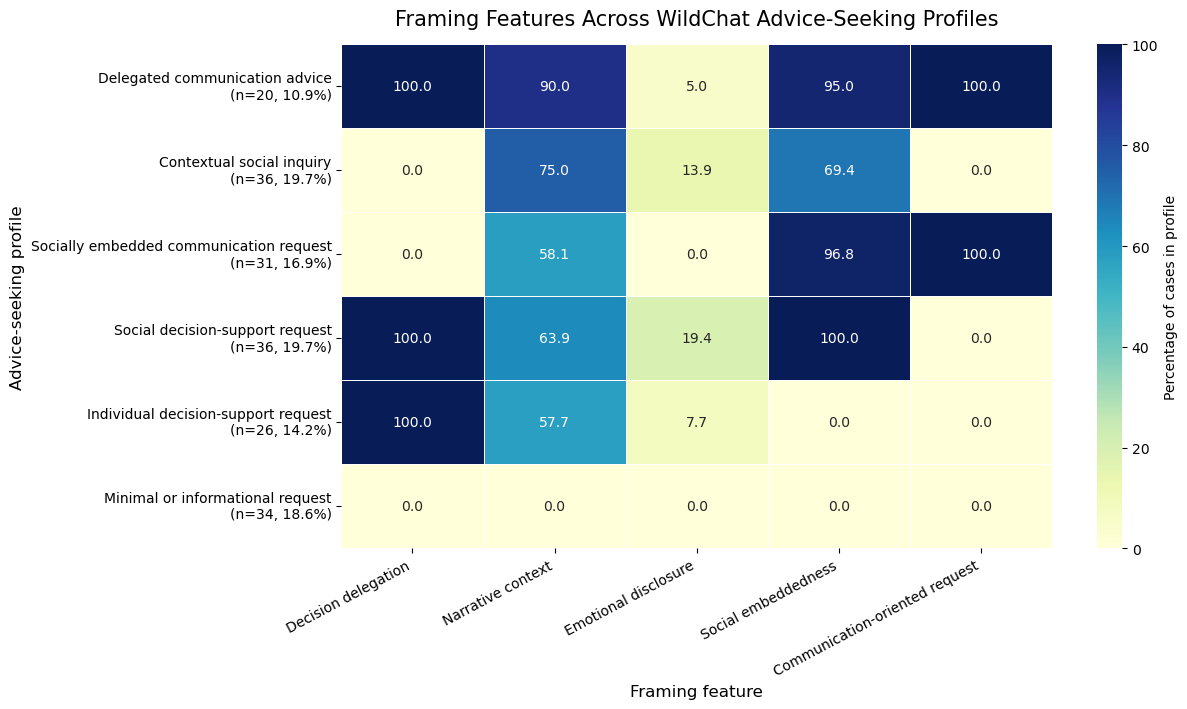

In [23]:
# Final Figure 1: k=6 cluster profile heatmap

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cluster_summary = pd.read_csv(
    OUTDIR / "wildchat_cluster_summary_6_profiles.csv"
)

feature_cols = [
    "Decision delegation",
    "Narrative context",
    "Emotional disclosure",
    "Social embeddedness",
    "Communication-oriented request",
]

cluster_summary["profile_label"] = cluster_summary.apply(
    lambda row: f'{row["suggested_interpretation"]}\n(n={int(row["n"])}, {row["percent"]:.1f}%)',
    axis=1
)

plot_df = cluster_summary.set_index("profile_label")[feature_cols]

plt.figure(figsize=(12.5, 7.2))

ax = sns.heatmap(
    plot_df,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Percentage of cases in profile"}
)

ax.set_title(
    "Framing Features Across WildChat Advice-Seeking Profiles",
    fontsize=15,
    pad=14
)
ax.set_xlabel("Framing feature", fontsize=12)
ax.set_ylabel("Advice-seeking profile", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=28, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig(
    OUTDIR / "figure_wildchat_profile_heatmap_6_profiles.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


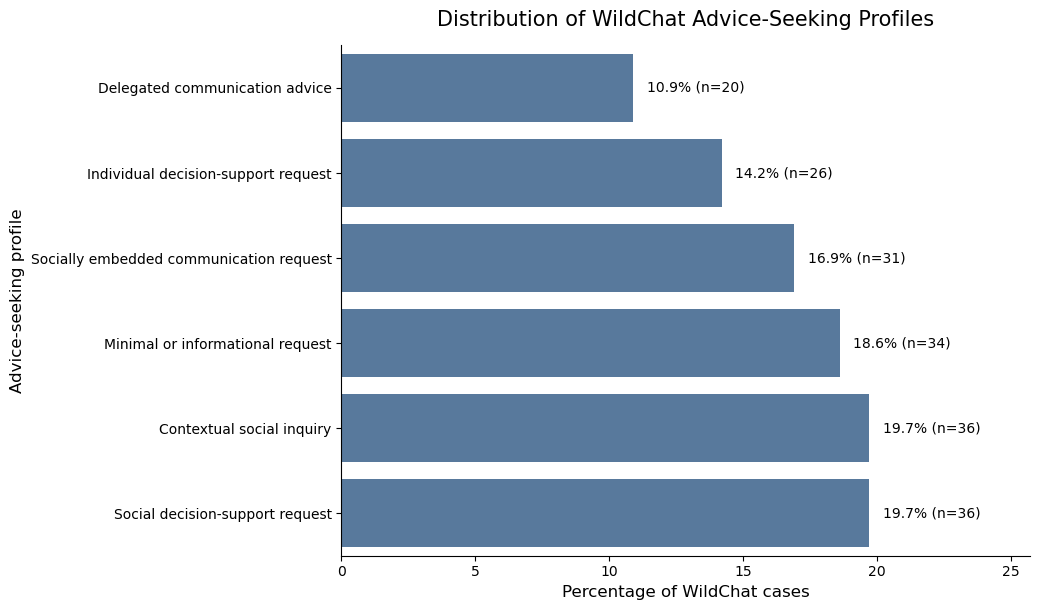

In [24]:
# Final Figure 2: k=6 profile distribution

cluster_summary = pd.read_csv(
    OUTDIR / "wildchat_cluster_summary_6_profiles.csv"
)

plot_df = cluster_summary.sort_values("percent", ascending=True).copy()

plt.figure(figsize=(10.5, 6.2))

ax = sns.barplot(
    data=plot_df,
    x="percent",
    y="suggested_interpretation",
    color="#4C78A8"
)

ax.set_title(
    "Distribution of WildChat Advice-Seeking Profiles",
    fontsize=15,
    pad=14
)
ax.set_xlabel("Percentage of WildChat cases", fontsize=12)
ax.set_ylabel("Advice-seeking profile", fontsize=12)

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["percent"] + 0.5,
        i,
        f'{row["percent"]:.1f}% (n={int(row["n"])})',
        va="center",
        fontsize=10
    )

ax.set_xlim(0, max(plot_df["percent"]) + 6)
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=10)

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.savefig(
    OUTDIR / "figure_wildchat_profile_distribution_6_profiles.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


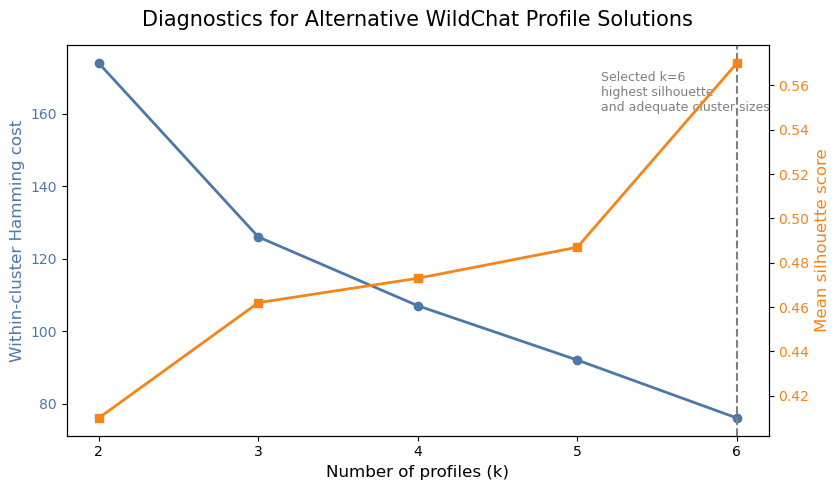

In [25]:
# Appendix Figure: k diagnostics with k=6 selected

k_diagnostics = pd.read_csv(
    OUTDIR / "wildchat_kmodes_k_diagnostics_5_features.csv"
)

chosen_k = 6

fig, ax1 = plt.subplots(figsize=(8.5, 5))

ax1.plot(
    k_diagnostics["k"],
    k_diagnostics["within_cluster_hamming_cost"],
    marker="o",
    linewidth=2,
    color="#4C78A8",
    label="Within-cluster Hamming cost"
)
ax1.set_xlabel("Number of profiles (k)", fontsize=12)
ax1.set_ylabel("Within-cluster Hamming cost", color="#4C78A8", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#4C78A8")
ax1.set_xticks(k_diagnostics["k"])

ax2 = ax1.twinx()
ax2.plot(
    k_diagnostics["k"],
    k_diagnostics["mean_silhouette_hamming"],
    marker="s",
    linewidth=2,
    color="#F58518",
    label="Mean silhouette score"
)
ax2.set_ylabel("Mean silhouette score", color="#F58518", fontsize=12)
ax2.tick_params(axis="y", labelcolor="#F58518")

ax1.axvline(chosen_k, color="gray", linestyle="--", linewidth=1.5)
ax1.text(
    chosen_k - 0.85,
    ax1.get_ylim()[1] * 0.96,
    "Selected k=6\nhighest silhouette\nand adequate cluster sizes",
    fontsize=9,
    color="gray",
    va="top"
)

plt.title(
    "Diagnostics for Alternative WildChat Profile Solutions",
    fontsize=15,
    pad=14
)
fig.tight_layout()
plt.savefig(
    OUTDIR / "appendix_wildchat_k_diagnostics_6_selected.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


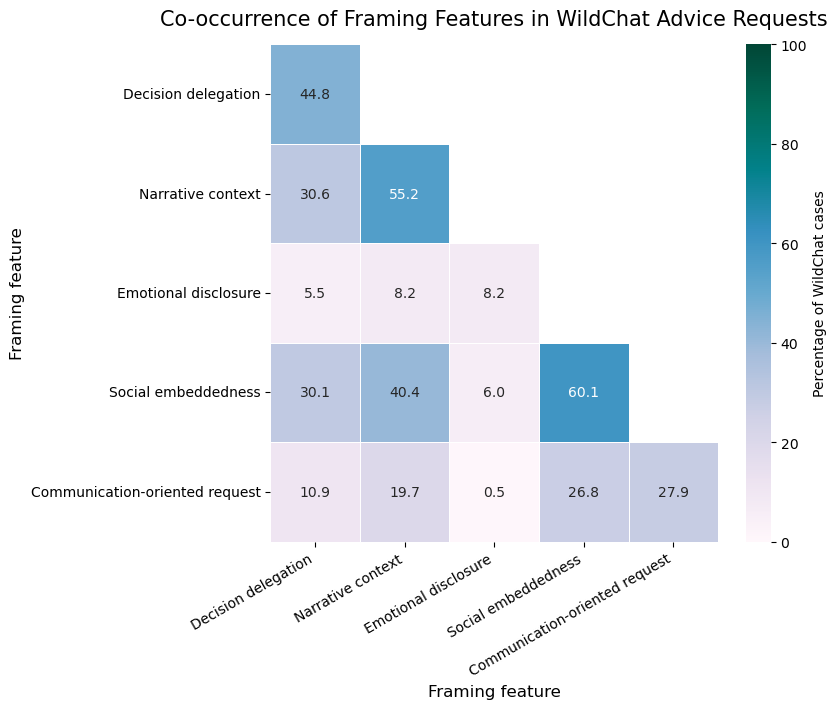

In [26]:
# Supporting Figure: lower-triangle co-occurrence heatmap

clustered_cases = pd.read_csv(
    OUTDIR / "wildchat_cases_with_clusters_6_profiles.csv"
)

feature_cols_raw = [
    "decision_delegation",
    "narrative_context",
    "emotional_disclosure",
    "social_embeddedness_llm",
    "communication_oriented_request",
]

feature_labels = {
    "decision_delegation": "Decision delegation",
    "narrative_context": "Narrative context",
    "emotional_disclosure": "Emotional disclosure",
    "social_embeddedness_llm": "Social embeddedness",
    "communication_oriented_request": "Communication-oriented request",
}

feature_data = clustered_cases[feature_cols_raw].astype(int)

cooccurrence = pd.DataFrame(
    index=[feature_labels[col] for col in feature_cols_raw],
    columns=[feature_labels[col] for col in feature_cols_raw],
    dtype=float
)

for col_i in feature_cols_raw:
    for col_j in feature_cols_raw:
        cooccurrence.loc[
            feature_labels[col_i],
            feature_labels[col_j]
        ] = ((feature_data[col_i] == 1) & (feature_data[col_j] == 1)).mean() * 100

mask = np.triu(np.ones_like(cooccurrence, dtype=bool), k=1)

plt.figure(figsize=(8.5, 7.2))

ax = sns.heatmap(
    cooccurrence,
    mask=mask,
    annot=True,
    fmt=".1f",
    cmap="PuBuGn",
    vmin=0,
    vmax=100,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Percentage of WildChat cases"}
)

ax.set_title(
    "Co-occurrence of Framing Features in WildChat Advice Requests",
    fontsize=15,
    pad=14
)
ax.set_xlabel("Framing feature", fontsize=12)
ax.set_ylabel("Framing feature", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig(
    OUTDIR / "figure_wildchat_feature_cooccurrence_lower_triangle.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [30]:
## siddhi

%pip install statsmodels openpyxl

Note: you may need to restart the kernel to use updated packages.


In [31]:
from pathlib import Path
import numpy as np
import pandas as pd

OUTDIR = Path("partner_regression_outputs")
OUTDIR.mkdir(exist_ok=True)

SHARED_PATH = Path("shared_framing_features_dataset.csv")
REDDIT_PATH = Path("/Users/harperli/Documents/Codex/2026-07-11/the-attached-notebook-already-contains-our/outputs/reddit_english_only_classified.csv")
WILDCHAT_PATH = Path("/Users/harperli/Documents/Codex/2026-07-11/the-attached-notebook-already-contains-our/outputs/wildchat_20k_radvice_classified.csv")

features = [
    "decision_delegation",
    "narrative_context",
    "emotional_disclosure",
    "social_embeddedness_llm",
    "communication_oriented_request",
]

feature_labels = {
    "decision_delegation": "Decision delegation",
    "narrative_context": "Narrative context",
    "emotional_disclosure": "Emotional disclosure",
    "social_embeddedness_llm": "Social embeddedness",
    "communication_oriented_request": "Communication-oriented request",
}

shared = pd.read_csv(SHARED_PATH)
reddit = pd.read_csv(REDDIT_PATH)
wildchat = pd.read_csv(WILDCHAT_PATH)

# Important: source_id is based on order after filtering, not original row ids.
reddit_cases = reddit[
    reddit["personal_practical_advice"].astype(str).str.strip().str.lower() == "yes"
].copy().reset_index(drop=True)

reddit_cases["source_id"] = [f"reddit_{i}" for i in range(len(reddit_cases))]

wildchat_cases = wildchat[
    wildchat["radvice_compatible"].astype(str).str.strip().str.lower().isin(["yes", "borderline"])
].copy().reset_index(drop=True)

wildchat_cases["source_id"] = [f"wildchat_{i}" for i in range(len(wildchat_cases))]

domain_lookup = pd.concat(
    [
        reddit_cases[["source_id", "domain"]],
        wildchat_cases[["source_id", "domain"]],
    ],
    ignore_index=True
)

df = shared.merge(domain_lookup, on="source_id", how="left")

if df["domain"].isna().any():
    missing = df[df["domain"].isna()][["source_id", "platform"]].head(10)
    raise ValueError(f"Some rows are missing domain labels:\n{missing}")

for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype(int)

df["word_count"] = pd.to_numeric(df["word_count"], errors="coerce")
df["log_word_count"] = np.log1p(df["word_count"])

# Follow the pre-specified six-domain grouping in the coding guide.
focal_domains = [
    "career_work",
    "relationship_social",
    "health_wellbeing",
    "finance_business",
    "education_application",
]

df["domain_group"] = np.where(
    df["domain"].isin(focal_domains),
    df["domain"],
    "other_domain"
)

df["platform"] = pd.Categorical(df["platform"], categories=["Reddit", "WildChat"])
df["domain_group"] = pd.Categorical(
    df["domain_group"],
    categories=focal_domains + ["other_domain"]
)

df.to_csv(OUTDIR / "merged_framing_coded.csv", index=False)

print(df.shape)
print(df["platform"].value_counts())
display(pd.crosstab(df["domain_group"], df["platform"]))

(1159, 30)
platform
Reddit      976
WildChat    183
Name: count, dtype: int64


platform,Reddit,WildChat
domain_group,,
career_work,110,54
relationship_social,331,21
health_wellbeing,126,21
finance_business,49,28
education_application,98,15
other_domain,262,44


In [32]:
prevalence_rows = []

for feature in features:
    row = {"feature": feature, "feature_label": feature_labels[feature]}
    for platform in ["Reddit", "WildChat"]:
        rate = df.loc[df["platform"] == platform, feature].mean()
        row[f"{platform}_percent"] = round(rate * 100, 1)
        row[f"{platform}_near_degenerate"] = (rate < 0.05) or (rate > 0.95)
    prevalence_rows.append(row)

prevalence_check = pd.DataFrame(prevalence_rows)
display(prevalence_check)

prevalence_check.to_csv(
    OUTDIR / "step0_feature_prevalence_check.csv",
    index=False
)

,feature,feature_label,Reddit_percent,Reddit_near_degenerate,WildChat_percent,WildChat_near_degenerate
0,decision_delegation,Decision delegation,89.4,False,44.8,False
1,narrative_context,Narrative context,99.7,True,55.2,False
2,emotional_disclosure,Emotional disclosure,74.1,False,8.2,False
3,social_embeddedness_llm,Social embeddedness,90.1,False,60.1,False
4,communication_oriented_request,Communication-oriented request,16.5,False,27.9,False


In [33]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

platform_term = 'C(platform, Treatment(reference="Reddit"))[T.WildChat]'

main_rows = []
main_models = {}

for feature in features:
    formula = (
        f"{feature} ~ "
        'C(platform, Treatment(reference="Reddit")) + '
        "C(domain_group) + "
        "log_word_count"
    )

    model = smf.ols(formula, data=df).fit(cov_type="HC3")
    main_models[feature] = model

    coef = model.params[platform_term]
    ci_low, ci_high = model.conf_int().loc[platform_term]
    p_value = model.pvalues[platform_term]

    main_rows.append({
        "feature": feature,
        "feature_label": feature_labels[feature],
        "platform_coef_wildchat_vs_reddit": coef,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "p_value": p_value,
        "r_squared": model.rsquared,
        "n": int(model.nobs),
    })

main_effects = pd.DataFrame(main_rows)

reject, p_adj, _, _ = multipletests(
    main_effects["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

main_effects["p_adj_bh_5_tests"] = p_adj
main_effects["significant_bh"] = reject

display(main_effects)

main_effects.to_csv(
    OUTDIR / "step2_main_platform_effects.csv",
    index=False
)

,feature,feature_label,platform_coef_wildchat_vs_reddit,ci_low,ci_high,p_value,r_squared,n,p_adj_bh_5_tests,significant_bh
0,decision_delegation,Decision delegation,-0.265227,-0.357710,-0.172744,1.899966e-08,0.240273,1159,2.374958e-08,True
1,narrative_context,Narrative context,-0.306591,-0.377192,-0.235990,1.720059e-17,0.454060,1159,8.600293e-17,True
2,emotional_disclosure,Emotional disclosure,-0.295136,-0.378507,-0.211764,3.968457e-12,0.379775,1159,9.921141e-12,True
3,social_embeddedness_llm,Social embeddedness,-0.044467,-0.124788,0.035854,2.778948e-01,0.250781,1159,2.778948e-01,False
4,communication_oriented_request,Communication-oriented request,0.241264,0.159432,0.323095,7.533939e-09,0.081731,1159,1.255656e-08,True


In [34]:
eligible_interaction_features = [
    "decision_delegation",
    "social_embeddedness_llm",
    "communication_oriented_request",
]

interaction_rows = []
interaction_models = {}

for feature in eligible_interaction_features:
    formula = (
        f"{feature} ~ "
        'C(platform, Treatment(reference="Reddit")) * C(domain_group) + '
        "log_word_count"
    )

    model = smf.ols(formula, data=df).fit(cov_type="HC3")
    interaction_models[feature] = model

    interaction_terms = [
        name for name in model.params.index
        if 'C(platform, Treatment(reference="Reddit"))[T.WildChat]:C(domain_group)' in name
    ]

    if len(interaction_terms) == 0:
        raise ValueError(f"No interaction terms found for {feature}")

    R = np.zeros((len(interaction_terms), len(model.params)))
    for i, term in enumerate(interaction_terms):
        R[i, list(model.params.index).index(term)] = 1

    wald = model.wald_test(R, use_f=False)

    interaction_rows.append({
        "feature": feature,
        "feature_label": feature_labels[feature],
        "wald_chi2": float(wald.statistic),
        "df": len(interaction_terms),
        "interaction_p_value": float(wald.pvalue),
        "n": int(model.nobs),
        "r_squared_interaction_model": model.rsquared,
    })

interaction_tests = pd.DataFrame(interaction_rows)

reject, p_adj, _, _ = multipletests(
    interaction_tests["interaction_p_value"],
    alpha=0.05,
    method="fdr_bh"
)

interaction_tests["interaction_p_adj_bh_3_tests"] = p_adj
interaction_tests["interaction_significant_bh"] = reject

display(interaction_tests)

interaction_tests.to_csv(
    OUTDIR / "step3_platform_by_domain_interactions.csv",
    index=False
)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/var/folders/s7/w8k6g_0d13q8wngyw_833mtc0000gn/T/ipykernel_71957/2480563568.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "wald_chi2": float(wald.statistic),
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warni

,feature,feature_label,wald_chi2,df,interaction_p_value,n,r_squared_interaction_model,interaction_p_adj_bh_3_tests,interaction_significant_bh
0,decision_delegation,Decision delegation,4.022517,5,5.461787e-01,1159,0.244935,0.546179,False
1,social_embeddedness_llm,Social embeddedness,38.247887,5,3.364389e-07,1159,0.280280,0.000001,True
2,communication_oriented_request,Communication-oriented request,16.775744,5,4.945339e-03,1159,0.094942,0.007418,True


In [35]:
simple_slope_rows = []

triggered_features = interaction_tests.loc[
    interaction_tests["interaction_significant_bh"],
    "feature"
].tolist()

if len(triggered_features) == 0:
    print("No Platform x Domain interactions survived BH correction. Step 4 follow-up skipped.")
else:
    for feature in triggered_features:
        for domain in df["domain_group"].cat.categories:
            sub = df[df["domain_group"] == domain].copy()

            if sub["platform"].nunique() < 2:
                continue

            if sub[feature].nunique() < 2:
                simple_slope_rows.append({
                    "feature": feature,
                    "feature_label": feature_labels[feature],
                    "domain_group": domain,
                    "note": "Skipped: no outcome variation within domain",
                })
                continue

            formula = (
                f"{feature} ~ "
                'C(platform, Treatment(reference="Reddit")) + '
                "log_word_count"
            )

            model = smf.ols(formula, data=sub).fit(cov_type="HC3")

            coef = model.params.get(platform_term, np.nan)

            if platform_term in model.params.index:
                ci_low, ci_high = model.conf_int().loc[platform_term]
                p_value = model.pvalues[platform_term]
            else:
                ci_low, ci_high, p_value = np.nan, np.nan, np.nan

            simple_slope_rows.append({
                "feature": feature,
                "feature_label": feature_labels[feature],
                "domain_group": domain,
                "platform_coef_wildchat_vs_reddit": coef,
                "ci_low": ci_low,
                "ci_high": ci_high,
                "p_value": p_value,
                "n": int(model.nobs),
                "r_squared": model.rsquared,
                "note": "",
            })

simple_slopes = pd.DataFrame(simple_slope_rows)

if len(simple_slopes):
    display(simple_slopes)

simple_slopes.to_csv(
    OUTDIR / "step4_conditional_domain_followups.csv",
    index=False
)

,feature,feature_label,domain_group,platform_coef_wildchat_vs_reddit,ci_low,ci_high,p_value,n,r_squared,note
0,social_embeddedness_llm,Social embeddedness,career_work,0.170031,0.009895,0.330166,0.037427,164,0.197259,
1,social_embeddedness_llm,Social embeddedness,relationship_social,-0.035890,-0.109238,0.037459,0.337548,352,0.051883,
2,social_embeddedness_llm,Social embeddedness,health_wellbeing,-0.209865,-0.463452,0.043723,0.104797,147,0.236468,
3,social_embeddedness_llm,Social embeddedness,finance_business,-0.032922,-0.283923,0.218079,0.797124,77,0.497302,
4,social_embeddedness_llm,Social embeddedness,education_application,-0.062488,-0.408780,0.283805,0.723586,113,0.157359,
5,social_embeddedness_llm,Social embeddedness,other_domain,0.029280,-0.125646,0.184207,0.711068,306,0.142008,
6,communication_oriented_request,Communication-oriented request,career_work,0.318862,0.127932,0.509792,0.001063,164,0.087018,
7,communication_oriented_request,Communication-oriented request,relationship_social,0.460531,0.230778,0.690285,0.000085,352,0.041267,
8,communication_oriented_request,Communication-oriented request,health_wellbeing,0.007921,-0.083123,0.098965,0.864598,147,0.000605,
9,communication_oriented_request,Communication-oriented request,finance_business,0.233363,-0.014825,0.481552,0.065345,77,0.134988,


In [36]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_design = pd.get_dummies(
    df[["platform", "domain_group"]],
    drop_first=True,
    dtype=float
)

vif_design = sm.add_constant(vif_design)

vif_rows = []

for i, column in enumerate(vif_design.columns):
    if column == "const":
        continue

    vif_rows.append({
        "variable": column,
        "vif": variance_inflation_factor(vif_design.values, i)
    })

vif_table = pd.DataFrame(vif_rows).sort_values("vif", ascending=False)
display(vif_table)

vif_table.to_csv(
    OUTDIR / "step5_vif_diagnostics.csv",
    index=False
)

print("Maximum VIF:", round(vif_table["vif"].max(), 3))

,variable,vif
1,domain_group_relationship_social,2.315817
5,domain_group_other_domain,2.163591
2,domain_group_health_wellbeing,1.687129
4,domain_group_education_application,1.551995
3,domain_group_finance_business,1.372479
0,platform_WildChat,1.081692


Maximum VIF: 2.316


In [37]:
final_table = main_effects.merge(
    interaction_tests[
        [
            "feature",
            "wald_chi2",
            "df",
            "interaction_p_value",
            "interaction_p_adj_bh_3_tests",
            "interaction_significant_bh",
        ]
    ],
    on="feature",
    how="left"
)

final_table["interaction_test_note"] = np.where(
    final_table["feature"].isin(eligible_interaction_features),
    "tested",
    "not tested: near-degenerate variation"
)

ordered_cols = [
    "feature",
    "feature_label",
    "platform_coef_wildchat_vs_reddit",
    "ci_low",
    "ci_high",
    "p_value",
    "p_adj_bh_5_tests",
    "significant_bh",
    "r_squared",
    "n",
    "wald_chi2",
    "df",
    "interaction_p_value",
    "interaction_p_adj_bh_3_tests",
    "interaction_significant_bh",
    "interaction_test_note",
]

final_table = final_table[ordered_cols]

display(final_table)

final_table.to_csv(
    OUTDIR / "final_adjusted_platform_effects_table.csv",
    index=False
)

with pd.ExcelWriter(OUTDIR / "partner_regression_results.xlsx") as writer:
    prevalence_check.to_excel(writer, sheet_name="Prevalence Check", index=False)
    main_effects.to_excel(writer, sheet_name="Main Effects", index=False)
    interaction_tests.to_excel(writer, sheet_name="Interactions", index=False)
    simple_slopes.to_excel(writer, sheet_name="Conditional Followups", index=False)
    vif_table.to_excel(writer, sheet_name="VIF", index=False)
    final_table.to_excel(writer, sheet_name="Final Table", index=False)

print("Saved outputs to:", OUTDIR.resolve())

,feature,feature_label,platform_coef_wildchat_vs_reddit,ci_low,ci_high,p_value,p_adj_bh_5_tests,significant_bh,r_squared,n,wald_chi2,df,interaction_p_value,interaction_p_adj_bh_3_tests,interaction_significant_bh,interaction_test_note
0,decision_delegation,Decision delegation,-0.265227,-0.357710,-0.172744,1.899966e-08,2.374958e-08,True,0.240273,1159,4.022517,5.0,5.461787e-01,0.546179,False,tested
1,narrative_context,Narrative context,-0.306591,-0.377192,-0.235990,1.720059e-17,8.600293e-17,True,0.454060,1159,NaN,NaN,NaN,NaN,NaN,not tested: near-degenerate variation
2,emotional_disclosure,Emotional disclosure,-0.295136,-0.378507,-0.211764,3.968457e-12,9.921141e-12,True,0.379775,1159,NaN,NaN,NaN,NaN,NaN,not tested: near-degenerate variation
3,social_embeddedness_llm,Social embeddedness,-0.044467,-0.124788,0.035854,2.778948e-01,2.778948e-01,False,0.250781,1159,38.247887,5.0,3.364389e-07,0.000001,True,tested
4,communication_oriented_request,Communication-oriented request,0.241264,0.159432,0.323095,7.533939e-09,1.255656e-08,True,0.081731,1159,16.775744,5.0,4.945339e-03,0.007418,True,tested


Saved outputs to: /Users/harperli/partner_regression_outputs


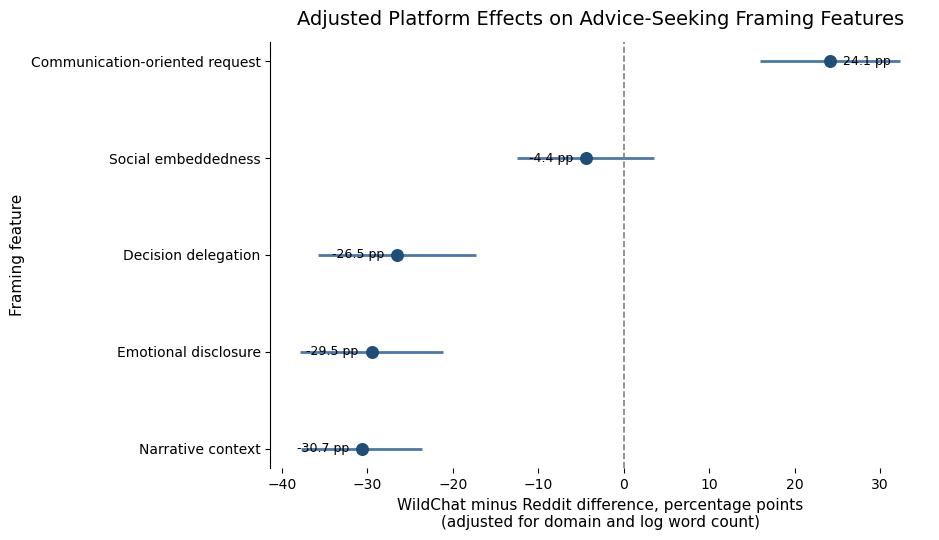

In [38]:
# Figure: Main platform effects coefficient plot

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

OUTDIR = Path("partner_regression_outputs")

main_effects = pd.read_csv(
    OUTDIR / "step2_main_platform_effects.csv"
)

plot_df = main_effects.copy()

plot_df["effect_pp"] = plot_df["platform_coef_wildchat_vs_reddit"] * 100
plot_df["ci_low_pp"] = plot_df["ci_low"] * 100
plot_df["ci_high_pp"] = plot_df["ci_high"] * 100

plot_df = plot_df.sort_values("effect_pp")

plt.figure(figsize=(9.5, 5.5))

ax = plt.gca()

# Confidence intervals
ax.hlines(
    y=plot_df["feature_label"],
    xmin=plot_df["ci_low_pp"],
    xmax=plot_df["ci_high_pp"],
    color="#4C78A8",
    linewidth=2
)

# Point estimates
ax.scatter(
    plot_df["effect_pp"],
    plot_df["feature_label"],
    color="#1F4E79",
    s=70,
    zorder=3
)

# Zero line
ax.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1.2
)

# Add labels
for _, row in plot_df.iterrows():
    label = f'{row["effect_pp"]:.1f} pp'
    ax.text(
        row["effect_pp"] + (1.5 if row["effect_pp"] >= 0 else -1.5),
        row["feature_label"],
        label,
        va="center",
        ha="left" if row["effect_pp"] >= 0 else "right",
        fontsize=9
    )

ax.set_title(
    "Adjusted Platform Effects on Advice-Seeking Framing Features",
    fontsize=14,
    pad=12
)

ax.set_xlabel(
    "WildChat minus Reddit difference, percentage points\n(adjusted for domain and log word count)",
    fontsize=11
)

ax.set_ylabel("Framing feature", fontsize=11)

sns.despine(left=False, bottom=True)
plt.tight_layout()

plt.savefig(
    OUTDIR / "figure_main_platform_effects_coefficient_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# Prepare domain-specific platform gaps for significant interactions

from pathlib import Path
import pandas as pd
import numpy as np

OUTDIR = Path("partner_regression_outputs")

merged = pd.read_csv(
    OUTDIR / "merged_framing_coded.csv"
)

significant_interaction_features = [
    "social_embeddedness_llm",
    "communication_oriented_request",
]

feature_labels = {
    "social_embeddedness_llm": "Social embeddedness",
    "communication_oriented_request": "Communication-oriented request",
}

domain_order = [
    "career_work",
    "relationship_social",
    "health_wellbeing",
    "finance_business",
    "education_application",
    "other_domain",
]

domain_labels = {
    "career_work": "Career/work",
    "relationship_social": "Relationship/social",
    "health_wellbeing": "Health/wellbeing",
    "finance_business": "Finance/business",
    "education_application": "Education/application",
    "other_domain": "Other domains",
}

gap_rows = []

for feature in significant_interaction_features:
    for domain in domain_order:
        sub = merged[merged["domain_group"] == domain]

        reddit = sub[sub["platform"] == "Reddit"]
        wildchat = sub[sub["platform"] == "WildChat"]

        if len(reddit) == 0 or len(wildchat) == 0:
            continue

        reddit_rate = reddit[feature].mean() * 100
        wildchat_rate = wildchat[feature].mean() * 100

        gap_rows.append({
            "feature": feature,
            "feature_label": feature_labels[feature],
            "domain_group": domain,
            "domain_label": domain_labels[domain],
            "reddit_n": len(reddit),
            "wildchat_n": len(wildchat),
            "reddit_percent": reddit_rate,
            "wildchat_percent": wildchat_rate,
            "wildchat_minus_reddit_pp": wildchat_rate - reddit_rate,
        })

domain_gaps = pd.DataFrame(gap_rows)

display(domain_gaps)

domain_gaps.to_csv(
    OUTDIR / "domain_specific_platform_gaps_for_interactions.csv",
    index=False
)

,feature,feature_label,domain_group,domain_label,reddit_n,wildchat_n,reddit_percent,wildchat_percent,wildchat_minus_reddit_pp
0,social_embeddedness_llm,Social embeddedness,career_work,Career/work,110,54,80.909091,66.666667,-14.242424
1,social_embeddedness_llm,Social embeddedness,relationship_social,Relationship/social,331,21,100.000000,95.238095,-4.761905
2,social_embeddedness_llm,Social embeddedness,health_wellbeing,Health/wellbeing,126,21,77.777778,33.333333,-44.444444
3,social_embeddedness_llm,Social embeddedness,finance_business,Finance/business,49,28,79.591837,28.571429,-51.020408
4,social_embeddedness_llm,Social embeddedness,education_application,Education/application,98,15,82.653061,46.666667,-35.986395
5,social_embeddedness_llm,Social embeddedness,other_domain,Other domains,262,44,91.984733,72.727273,-19.257460
6,communication_oriented_request,Communication-oriented request,career_work,Career/work,110,54,12.727273,35.185185,22.457912
7,communication_oriented_request,Communication-oriented request,relationship_social,Relationship/social,331,21,27.492447,61.904762,34.412315
8,communication_oriented_request,Communication-oriented request,health_wellbeing,Health/wellbeing,126,21,4.761905,4.761905,0.000000
9,communication_oriented_request,Communication-oriented request,finance_business,Finance/business,49,28,8.163265,10.714286,2.551020


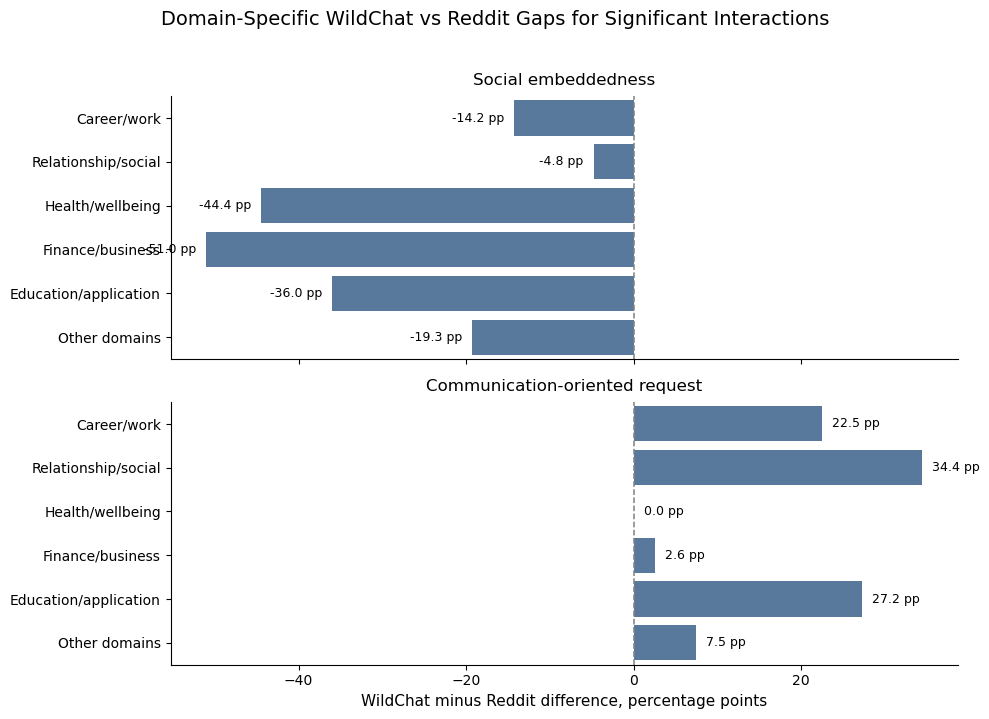

In [40]:
# Figure: Domain-specific platform gaps for significant interactions

import matplotlib.pyplot as plt
import seaborn as sns

plot_df = domain_gaps.copy()

plot_df["domain_label"] = pd.Categorical(
    plot_df["domain_label"],
    categories=[domain_labels[d] for d in domain_order],
    ordered=True
)

features_to_plot = plot_df["feature_label"].unique()

fig, axes = plt.subplots(
    nrows=len(features_to_plot),
    ncols=1,
    figsize=(10, 7),
    sharex=True
)

if len(features_to_plot) == 1:
    axes = [axes]

for ax, feature_label in zip(axes, features_to_plot):
    sub = plot_df[plot_df["feature_label"] == feature_label].sort_values("domain_label")

    sns.barplot(
        data=sub,
        x="wildchat_minus_reddit_pp",
        y="domain_label",
        ax=ax,
        color="#4C78A8"
    )

    ax.axvline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1.1
    )

    ax.set_title(
        feature_label,
        fontsize=12,
        pad=8
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

    for i, (_, row) in enumerate(sub.iterrows()):
        value = row["wildchat_minus_reddit_pp"]
        ax.text(
            value + (1.2 if value >= 0 else -1.2),
            i,
            f'{value:.1f} pp',
            va="center",
            ha="left" if value >= 0 else "right",
            fontsize=9
        )

fig.suptitle(
    "Domain-Specific WildChat vs Reddit Gaps for Significant Interactions",
    fontsize=14,
    y=1.02
)

axes[-1].set_xlabel(
    "WildChat minus Reddit difference, percentage points",
    fontsize=11
)

sns.despine(left=False, bottom=False)
plt.tight_layout()

plt.savefig(
    OUTDIR / "figure_domain_specific_platform_gaps_interactions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()